# Refilter Bandpass

In [1]:
# ============================================================
# FULL PREPROCESSING PIPELINE — EDF → PKL
# Perubahan dari versi lama:
#   - Bandpass: 0.8–10 Hz → 0.5–15 Hz (Chang et al. 2020)
#   - Output: X_y_new_v2_015hz.pkl (tidak overwrite pkl lama)
# Semua logic lain IDENTIK dengan pipeline sebelumnya
# ============================================================

# ============================================================
# CELL 1 — Import Libraries
# ============================================================
import os
import numpy as np
import pyedflib
import xml.etree.ElementTree as ET
import pickle
import neurokit2 as nk
from scipy.signal import resample_poly
from math import gcd

print("✅ Libraries imported")

# ============================================================
# CELL 2 — Configuration
# ============================================================
folder_path = r"E:\1D CNN\PSG and label"
SAVE_PATH   = r'E:\1D CNN\X_y_new_v2_015hz.pkl'
TARGET_FS   = 200     # Hz — sama dengan pkl lama

# Segmentation
SEGMENT_SEC  = 60
MERGE_GAP    = 3
MIN_DURATION = 10
OVERLAP_THR  = 0.10

# AH event types
AH_EVENTS = [
    'Obstructive Apnea',
    'Mixed Apnea',
    'Central Apnea',
    'Obstructive Hypopnea',
    'Central Hypopnea',
    'SpO2 desaturation'
]
UNSURE_EVENTS = ['Unsure']

print(f"✅ Config set")
print(f"   Folder     : {folder_path}")
print(f"   Target fs  : {TARGET_FS} Hz")
print(f"   Segment    : {SEGMENT_SEC}s")
print(f"   Save to    : {SAVE_PATH}")

# ============================================================
# CELL 3 — Helper Functions
# ============================================================
def extract_number(name):
    """Sort subject IDs correctly: s1→1, s10→10"""
    return int(str(name)[1:].split('_')[0].split('.')[0])

def resample_ecg(signal, orig_fs, target_fs):
    """Resample ECG to target sampling rate"""
    if orig_fs == target_fs:
        return signal, target_fs
    g    = gcd(int(orig_fs), int(target_fs))
    up   = int(target_fs) // g
    down = int(orig_fs)   // g
    return resample_poly(signal, up, down), target_fs

def merge_and_filter_events(events):
    """
    Merge overlapping/nearby AH events.
    Rules:
    - Union area >= 10% → merge
    - Gap <= 3s → merge
    - Duration < 10s after merge → discard
    """
    ah_events = sorted(
        [e for e in events if e['type'] in AH_EVENTS],
        key=lambda x: x['start']
    )
    if not ah_events:
        return []

    merged  = []
    current = ah_events[0].copy()

    for e in ah_events[1:]:
        cur_start = current['start']
        cur_end   = current['start'] + current['duration']
        e_start   = e['start']
        e_end     = e['start'] + e['duration']

        intersection  = max(0, min(cur_end, e_end) - max(cur_start, e_start))
        union         = (cur_end - cur_start) + (e_end - e_start) - intersection
        overlap_ratio = intersection / union if union > 0 else 0
        gap           = e_start - cur_end

        if overlap_ratio >= OVERLAP_THR or gap <= MERGE_GAP:
            new_end             = max(cur_end, e_end)
            current['duration'] = new_end - cur_start
            current['type']     = 'Merged'
        else:
            merged.append(current)
            current = e.copy()

    merged.append(current)
    return [e for e in merged if e['duration'] >= MIN_DURATION]

print("✅ Helper functions defined")

# ============================================================
# CELL 4 — Load ECG from EDF Files
# ============================================================
if not os.path.isdir(folder_path):
    raise FileNotFoundError(f"Folder tidak ditemukan: {folder_path}")

edf_files = sorted(
    [f for f in os.listdir(folder_path) if f.lower().endswith('.edf')]
)
print(f"Found {len(edf_files)} EDF files")

all_ecg = {}

for filename in edf_files:
    filepath = os.path.join(folder_path, filename)
    subject  = filename.replace('.edf', '')
    try:
        f         = pyedflib.EdfReader(filepath)
        labels_ch = f.getSignalLabels()

        if 'ECG' in labels_ch:
            ecg_idx = labels_ch.index('ECG')
            fs      = f.getSampleFrequency(ecg_idx)
            ecg     = f.readSignal(ecg_idx)
            f._close()

            # Resample ke TARGET_FS kalau perlu
            ecg_resampled, new_fs = resample_ecg(ecg, fs, TARGET_FS)
            all_ecg[subject] = {'signal': ecg_resampled, 'fs': new_fs}
            print(f"✅ {subject} — {len(ecg_resampled)} samples | "
                  f"{new_fs} Hz | "
                  f"{len(ecg_resampled)/new_fs/60:.1f} min")
        else:
            f._close()
            print(f"⚠️  {subject} — No ECG channel found")

    except Exception as e:
        print(f"❌ {subject} — {e}")

print(f"\n✅ Loaded: {len(all_ecg)} subjects")

# ============================================================
# CELL 5 — Bandpass Filter
# PERUBAHAN: 0.8–10 Hz → 0.5–15 Hz (Chang et al. 2020)
# Alasan: QRS complex range 5–15 Hz
#         → 0.5–15 Hz preserves QRS morphology
#         → R-peak detection lebih akurat
#         → RR intervals lebih bersih
# ============================================================
all_ecg_clean = {}

for subject in sorted(all_ecg.keys(), key=extract_number):
    ecg = all_ecg[subject]['signal']
    fs  = all_ecg[subject]['fs']

    # ⚠️ PERUBAHAN: lowcut=0.5, highcut=15.0
    ecg_filtered = nk.signal_filter(
        ecg,
        sampling_rate=fs,
        lowcut=0.5,     # was 0.8
        highcut=15.0,   # was 10.0
        method='butterworth'
    )

    all_ecg_clean[subject] = {
        'signal': ecg_filtered,
        'fs'    : fs
    }

    print(f"✅ {subject} — Bandpass 0.5–15 Hz applied | "
          f"range [{ecg_filtered.min():.3f}, {ecg_filtered.max():.3f}]")

print(f"\n✅ All {len(all_ecg_clean)} subjects filtered (0.5–15 Hz)")

# ============================================================
# CELL 6 — Segmentation 60s + Labeling from XML
# TIDAK ADA PERUBAHAN dari pipeline sebelumnya
# ============================================================
X                 = []
y                 = []
subject_ids       = []
all_merged_events = {}

print("=" * 60)
print("SEGMENTATION + LABELING (merge+filter applied)")
print(f"Bandpass: 0.5–15 Hz (v2)")
print("=" * 60)

for subject in sorted(all_ecg_clean.keys(), key=extract_number):
    ecg     = all_ecg_clean[subject]['signal']
    fs      = all_ecg_clean[subject]['fs']
    seg_len = int(SEGMENT_SEC * fs)   # 60 × 200 = 12000
    n_segs  = len(ecg) // seg_len

    # Read XML labels
    xml_path = os.path.join(folder_path, f"{subject}_re.XML")
    if not os.path.exists(xml_path):
        print(f"⚠️  {subject} — XML not found, skipping")
        continue

    tree   = ET.parse(xml_path)
    root   = tree.getroot()
    events = []
    for event in root.iter('ScoredEvent'):
        name     = event.find('Name')
        start    = event.find('Start')
        duration = event.find('Duration')
        if name is not None and start is not None:
            events.append({
                'type'    : name.text.strip(),
                'start'   : float(start.text),
                'duration': float(duration.text) if duration is not None else 0
            })

    # Merge + filter AH events
    merged_events             = merge_and_filter_events(events)
    all_merged_events[subject]= merged_events

    n_normal = n_ah = n_skipped = 0

    for i in range(n_segs):
        seg_start_sec = i * SEGMENT_SEC
        seg_end_sec   = seg_start_sec + SEGMENT_SEC
        sample_start  = i * seg_len
        sample_end    = sample_start + seg_len

        # Skip unsure segments
        is_unsure = any(
            e['type'] in UNSURE_EVENTS and
            e['start'] < seg_end_sec and
            (e['start'] + e['duration']) > seg_start_sec
            for e in events
        )
        if is_unsure:
            n_skipped += 1
            continue

        # Label dari merged events
        is_ah = any(
            e['start'] < seg_end_sec and
            (e['start'] + e['duration']) > seg_start_sec
            for e in merged_events
        )
        label = 1 if is_ah else 0

        # Extract segment + Z-score per segment
        segment  = ecg[sample_start:sample_end]
        seg_mean = np.mean(segment)
        seg_std  = np.std(segment)
        segment  = (segment - seg_mean) / (seg_std + 1e-8)

        X.append(segment)
        y.append(label)
        subject_ids.append(subject)

        if label == 1:
            n_ah += 1
        else:
            n_normal += 1

    print(f"✅ {subject:<6} | "
          f"Normal: {n_normal:>4} | "
          f"AH: {n_ah:>4} | "
          f"Skipped: {n_skipped:>3}")

# Convert to numpy
X           = np.array(X).reshape(-1, seg_len, 1)
y           = np.array(y)
subject_ids = np.array(subject_ids)

# ============================================================
# CELL 7 — Save pkl
# ============================================================
with open(SAVE_PATH, 'wb') as f:
    pickle.dump({
        'X'          : X,
        'y'          : y,
        'subject_ids': subject_ids
    }, f)

print(f"\n{'=' * 60}")
print(f"PREPROCESSING DONE — v2 (bandpass 0.5–15 Hz)")
print(f"{'=' * 60}")
print(f"Total segments : {len(X)}")
print(f"Normal (0)     : {np.sum(y == 0)}")
print(f"AH     (1)     : {np.sum(y == 1)}")
print(f"Ratio          : {np.sum(y==0)/np.sum(y==1):.2f}x Normal > AH")
print(f"X shape        : {X.shape}")
print(f"Subjects       : {len(np.unique(subject_ids))}")
print(f"\nSaved → {SAVE_PATH}")
print(f"\nNext step:")
print(f"  Ganti path pkl di Exp 8:")
print(f"  with open(r'{SAVE_PATH}', 'rb') as f:")

✅ Libraries imported
✅ Config set
   Folder     : E:\1D CNN\PSG and label
   Target fs  : 200 Hz
   Segment    : 60s
   Save to    : E:\1D CNN\X_y_new_v2_015hz.pkl
✅ Helper functions defined
Found 50 EDF files
✅ s1 — 4798600 samples | 200 Hz | 399.9 min
✅ s10 — 4753000 samples | 200 Hz | 396.1 min
✅ s11 — 4707000 samples | 200 Hz | 392.2 min
✅ s12 — 5032200 samples | 200 Hz | 419.4 min
✅ s13 — 4966600 samples | 200 Hz | 413.9 min
✅ s14 — 4717200 samples | 200 Hz | 393.1 min
✅ s15 — 4715800 samples | 200 Hz | 393.0 min
✅ s16 — 4779200 samples | 200 Hz | 398.3 min
✅ s17 — 4971800 samples | 200 Hz | 414.3 min
✅ s18 — 5074600 samples | 200 Hz | 422.9 min
✅ s19 — 4778000 samples | 200 Hz | 398.2 min
✅ s2 — 4493800 samples | 200 Hz | 374.5 min
✅ s20 — 5111200 samples | 200 Hz | 425.9 min
✅ s21 — 4734800 samples | 200 Hz | 394.6 min
✅ s22 — 4808000 samples | 200 Hz | 400.7 min
✅ s23 — 4957400 samples | 200 Hz | 413.1 min
✅ s24 — 4957600 samples | 200 Hz | 413.1 min
✅ s25 — 5041200 samples | 2

In [3]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedGroupKFold
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240 # 60s * 4Hz
N_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 60 
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\final_results_exp8_v2_015hz.pkl'

print(f"Device: {DEVICE}")
print("Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)")

# ============================================================
# 1. ENHANCED PREPROCESSING: SUBJEClT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    """Menghitung Z-score secara terpisah untuk tiap subjek ID."""
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask] # Shape: (n_segments, 2, 240)
        
        # Hitung mean dan std per channel (RR dan R-peak amplitude)
        # axis=(0,2) menghitung statistik di seluruh segmen dan waktu per channel
        mean = np.mean(sub_data, axis=(0, 2), keepdims=True)
        std = np.std(sub_data, axis=(0, 2), keepdims=True) + 1e-8
        
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# Load Data
with open(r'E:\1D CNN\X_y_new_v2_015hz.pkl', 'rb') as f:
    data = pickle.load(f)
X_raw, y, subj = data['X'], np.array(data['y']), np.array(data['subject_ids'])

def extract_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4: return None
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        t_uni = np.arange(rr_times[0], rr_times[-1], 1 / INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        n = len(rr_uni)
        if n >= SEG_LEN:
            rr_out, rp_out = rr_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN], rp_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out, rp_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge'), np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
    except: return None

print("Extracting features and applying Subject-wise scaling...")
rr_list, y_list, subj_list = [], [], []
for i in range(len(X_raw)):
    feat = extract_features(X_raw[i])
    if feat is not None:
        rr_list.append(feat); y_list.append(y[i]); subj_list.append(subj[i])

X_feat = np.array(rr_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

# Eksekusi Normalisasi Per Subjek
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

# ============================================================
# 2. ARCHITECTURE: MULTI-SCALE SE-RESNET
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn1 = nn.BatchNorm1d(out_ch); self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
           self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm1d(out_ch))

    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([conv(x) for conv in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([conv(out) for conv in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out) # Channel Attention
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(2, 64, 7, 3, 3, bias=False), nn.BatchNorm1d(64), nn.ReLU(True), nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(512, 1); self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks): layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x); x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1); return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# 3. STRATIFIED CROSS-VALIDATION WITH BALANCED SAMPLER
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X_final, y_valid, groups=subj_valid)):
    print(f"\n--- FOLD {fold_idx + 1} ---")
    X_train, y_train = X_final[train_idx], y_valid[train_idx]
    X_val, y_val = X_final[val_idx], y_valid[val_idx]
    
    # BALANCED SAMPLING
    class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
    weight = 1. / class_sample_count
    samples_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))
    
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc, patience = 0, 0
    best_model_state = None
    
    for epoch in range(EPOCHS):
        model.train(); t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(); out = model(xb).view(-1); loss = criterion(out, yb)
            loss.backward(); optimizer.step(); t_loss += loss.item()
            
        model.eval(); y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader: y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss/len(train_loader))
        
        if val_auc > best_auc:
            best_auc = val_auc; best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}; patience = 0
        else:
            patience += 1
            if patience >= 12: break

    # FINAL EVALUATION FOR FOLD
    model.load_state_dict(best_model_state); model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader: y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    # Temporal Smoothing & Thresholding
    y_prob = np.convolve(np.array(y_prob).flatten(), np.ones(3)/3, mode='same')
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc, acc = roc_auc_score(y_val, y_prob), accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens, spec = tp/(tp+fn), tn/(tn+fp)
    
    print(f"Result Fold {fold_idx+1}: AUC={auc:.4f}, Acc={acc:.4f}, Sens={sens:.4f}, Spec={spec:.4f}")
    fold_results.append({'auc': auc, 'acc': acc, 'sens': sens, 'spec': spec})

print("\n" + "="*50)
print("FINAL SUMMARY - EXPERIMENT 8 (THE PRECISION)")
print("="*50)
for m in ['auc', 'acc', 'sens', 'spec']:
    vals = [f[m] for f in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Device: cuda
Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)
Extracting features and applying Subject-wise scaling...

--- FOLD 1 ---
Result Fold 1: AUC=0.7244, Acc=0.6697, Sens=0.6922, Spec=0.6593

--- FOLD 2 ---
Result Fold 2: AUC=0.8632, Acc=0.7744, Sens=0.7096, Spec=0.8345

--- FOLD 3 ---
Result Fold 3: AUC=0.8164, Acc=0.7380, Sens=0.6456, Spec=0.8353

--- FOLD 4 ---
Result Fold 4: AUC=0.8028, Acc=0.7238, Sens=0.7302, Spec=0.7206

--- FOLD 5 ---
Result Fold 5: AUC=0.8096, Acc=0.7430, Sens=0.6755, Spec=0.8076

FINAL SUMMARY - EXPERIMENT 8 (THE PRECISION)
Mean AUC  : 0.8033 ± 0.0448
Mean ACC  : 0.7298 ± 0.0343
Mean SENS : 0.6906 ± 0.0290
Mean SPEC : 0.7715 ± 0.0701


In [5]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
!pip install neurokit2 wfdb pyedflib --quiet


  You can safely remove it manually.
  You can safely remove it manually.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Signal processing
import neurokit2 as nk
import wfdb
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, accuracy_score,
                             ConfusionMatrixDisplay)

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Print versions
print("All libraries loaded successfully!")
print(f"NumPy:       {np.__version__}")
print(f"Pandas:      {pd.__version__}")
print(f"NeuroKit2:   {nk.__version__}")
print(f"TensorFlow:  {tf.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"SciPy:       {__import__('scipy').__version__}")

# GPU check
if tf.config.list_physical_devices('GPU'):
    print(f"\nGPU available: {tf.config.list_physical_devices('GPU')[0].name}")
else:
    print("\nNo GPU detected — training will use CPU (still works for this notebook).")


All libraries loaded successfully!
NumPy:       1.26.4
Pandas:      2.3.3
NeuroKit2:   0.2.13
TensorFlow:  2.10.0
Scikit-learn: 1.7.2
SciPy:       1.15.3

GPU available: /physical_device:GPU:0


# Import Libraries

In [3]:
pip install neurokit2 antropy scipy tensorflow scikit-learn pandas

In [4]:
import numpy as np
import pickle
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import welch
from scipy.integrate import trapezoid
import neurokit2 as nk
import antropy
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (roc_auc_score, f1_score,
                             confusion_matrix, accuracy_score,
                             classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────
FS          = 200    # ECG sampling rate (Hz) — NCKUHSC
INTERP_FS   = 4      # RR interpolation rate (Hz) — HRV standard
INTERP_LEN  = 240    # 60s × 4 Hz = 240 samples
N_FOLDS     = 5
FOLD_SIZE   = 10     # 10 subjects per fold
BATCH_SIZE  = 32
EPOCHS      = 50
THRESHOLD   = 0.4    # same as raw ECG pipeline
SAVE_PATH   = r'E:\1D CNN\fold_results_hrv_1dcnn.pkl'

In [4]:
import tensorflow as tf
# Untuk DirectML, biasanya terbaca sebagai device DML
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# Load Data

New preposesing


In [3]:
# Load & Ekslor ECG Data
# ============================================================
# CELL 2 — Set Path
# ============================================================
import os


# Path to PSG and label folder
folder_path = r"E:\1D CNN\PSG and label"


# List all EDF and XML files
edf_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.edf')])
xml_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.XML')])

print(f"EDF files ({len(edf_files)}): {edf_files}")
print(f"XML files ({len(xml_files)}): {xml_files}")

EDF files (50): ['s1.edf', 's10.edf', 's11.edf', 's12.edf', 's13.edf', 's14.edf', 's15.edf', 's16.edf', 's17.edf', 's18.edf', 's19.edf', 's2.edf', 's20.edf', 's21.edf', 's22.edf', 's23.edf', 's24.edf', 's25.edf', 's26.edf', 's27.edf', 's28.edf', 's29.edf', 's3.edf', 's30.edf', 's31.edf', 's32.edf', 's33.edf', 's34.edf', 's35.edf', 's36.edf', 's37.edf', 's38.edf', 's39.edf', 's4.edf', 's40.edf', 's41.edf', 's42.edf', 's43.edf', 's44.edf', 's45.edf', 's46.edf', 's47.edf', 's48.edf', 's49.edf', 's5.edf', 's50.edf', 's6.edf', 's7.edf', 's8.edf', 's9.edf']
XML files (50): ['s10_re.XML', 's11_re.XML', 's12_re.XML', 's13_re.XML', 's14_re.XML', 's15_re.XML', 's16_re.XML', 's17_re.XML', 's18_re.XML', 's19_re.XML', 's1_re.XML', 's20_re.XML', 's21_re.XML', 's22_re.XML', 's23_re.XML', 's24_re.XML', 's25_re.XML', 's26_re.XML', 's27_re.XML', 's28_re.XML', 's29_re.XML', 's2_re.XML', 's30_re.XML', 's31_re.XML', 's32_re.XML', 's33_re.XML', 's34_re.XML', 's35_re.XML', 's36_re.XML', 's37_re.XML', 's38_re

In [6]:
# ============================================================
# CELL 3 — Load All ECG Signals from EDF Files
# ============================================================
import os
import pyedflib

all_ecg = {}

for filename in edf_files:
    filepath = os.path.join(folder_path, filename)
    subject = filename.replace('.edf', '')

    f = None
    try:
        f = pyedflib.EdfReader(filepath)
        labels_ch = f.getSignalLabels()

        if 'ECG' in labels_ch:
            ecg_idx = labels_ch.index('ECG')
            fs = f.getSampleFrequency(ecg_idx)
            ecg = f.readSignal(ecg_idx)

            all_ecg[subject] = {'signal': ecg, 'fs': fs}
            print(f"✅ {subject} — {len(ecg)} samples | {fs} Hz | {len(ecg)/fs/60:.1f} min")
        else:
            print(f"⚠️ {subject} — No ECG channel found")

    except Exception as e:
        print(f"❌ {subject} — {e}")

    finally:
        if f is not None:
            try:
                f.close()
            except:
                pass

print(f"\nLoaded: {len(all_ecg)} / {len(edf_files)} subjects")
def extract_number(name):
    """Extract subject number for sorting (s1→1, s10→10)."""
    return int(name[1:].split('_')[0].split('.')[0])

all_ecg = {}  # { 's1': {'signal': array, 'fs': 200}, ... }

for filename in edf_files:
    filepath = os.path.join(folder_path, filename)
    subject  = filename.replace('.edf', '')

    try:
        f         = pyedflib.EdfReader(filepath)
        labels_ch = f.getSignalLabels()

        if 'ECG' in labels_ch:
            ecg_idx = labels_ch.index('ECG')          # find ECG channel index
            fs      = f.getSampleFrequency(ecg_idx)   # sampling rate (Hz)
            ecg     = f.readSignal(ecg_idx)            # read ECG signal
            f._close()

            all_ecg[subject] = {'signal': ecg, 'fs': fs}
            print(f"✅ {subject} — {len(ecg)} samples | {fs} Hz | {len(ecg)/fs/60:.1f} min")
        else:
            f._close()
            print(f"⚠️  {subject} — No ECG channel found")

    except Exception as e:
        print(f"❌ {subject} — {e}")

print(f"\nLoaded: {len(all_ecg)} / {len(edf_files)} subjects")

✅ s1 — 4798600 samples | 200.0 Hz | 399.9 min
✅ s10 — 4753000 samples | 200.0 Hz | 396.1 min
✅ s11 — 4707000 samples | 200.0 Hz | 392.2 min
✅ s12 — 5032200 samples | 200.0 Hz | 419.4 min
✅ s13 — 4966600 samples | 200.0 Hz | 413.9 min
✅ s14 — 4717200 samples | 200.0 Hz | 393.1 min
✅ s15 — 4715800 samples | 200.0 Hz | 393.0 min
✅ s16 — 4779200 samples | 200.0 Hz | 398.3 min
✅ s17 — 4971800 samples | 200.0 Hz | 414.3 min
✅ s18 — 5074600 samples | 200.0 Hz | 422.9 min
✅ s19 — 4778000 samples | 200.0 Hz | 398.2 min
✅ s2 — 4493800 samples | 200.0 Hz | 374.5 min
✅ s20 — 5111200 samples | 200.0 Hz | 425.9 min
✅ s21 — 4734800 samples | 200.0 Hz | 394.6 min
✅ s22 — 4808000 samples | 200.0 Hz | 400.7 min
✅ s23 — 4957400 samples | 200.0 Hz | 413.1 min
✅ s24 — 4957600 samples | 200.0 Hz | 413.1 min
✅ s25 — 5041200 samples | 200.0 Hz | 420.1 min
✅ s26 — 5183200 samples | 200.0 Hz | 431.9 min
✅ s27 — 4461600 samples | 200.0 Hz | 371.8 min
✅ s28 — 4908800 samples | 200.0 Hz | 409.1 min
✅ s29 — 4999600

In [7]:
# ============================================================
# Check XML Labels 
# ============================================================
import xml.etree.ElementTree as ET # Added this line

print("=" * 60)
print("XML LABEL CHECK — All Event Types from XML")
print("=" * 60)

all_event_types = set()  # collect all unique event types across all subjects

for subject in sorted(all_ecg.keys(), key=extract_number):
    xml_path = os.path.join(folder_path, f"{subject}_re.XML")

    if not os.path.exists(xml_path):
        print(f"❌ {subject} — XML NOT FOUND")
        continue

    tree  = ET.parse(xml_path)
    root  = tree.getroot()

    # Read all event types directly from XML
    event_counts = {}
    for event in root.iter('ScoredEvent'):
        name = event.find('Name')
        if name is not None and name.text:
            event_type = name.text.strip()
            event_counts[event_type] = event_counts.get(event_type, 0) + 1
            all_event_types.add(event_type)

    print(f"\n✅ {subject}:")
    for event_type, count in sorted(event_counts.items()):
        print(f"   {event_type:<40}: {count}")

print("\n" + "=" * 60)
print("ALL UNIQUE EVENT TYPES ACROSS ALL SUBJECTS")
print("=" * 60)
for event_type in sorted(all_event_types):
    print(f"  {event_type}")

XML LABEL CHECK — All Event Types from XML

✅ s1:
   Arousal (ARO Limb)                      : 4
   Arousal (ARO PLM)                       : 4
   Arousal (ARO RES)                       : 24
   Arousal (ARO SPONT)                     : 116
   Limb Movement (Left)                    : 13
   Limb Movement (Right)                   : 15
   Obstructive Hypopnea                    : 111
   PLM (Left)                              : 20
   SpO2 desaturation                       : 44

✅ s2:
   Arousal (ARO PLM)                       : 1
   Arousal (ARO RES)                       : 15
   Arousal (ARO SPONT)                     : 148
   Limb Movement (Left)                    : 21
   Limb Movement (Right)                   : 10
   Obstructive Hypopnea                    : 124
   PLM (Left)                              : 27
   SpO2 desaturation                       : 11

✅ s3:
   Arousal (ARO RES)                       : 75
   Arousal (ARO SPONT)                     : 279
   Central Apnea      

In [8]:
# ============================================================
# CELL — Preprocessing: Bandpass Filter
# Step 1: Bandpass filter 0.5–15 Hz (Chang et al. 2020, Butterworth)
#   - 0.5 Hz lower cutoff → removes baseline wander
#   - 15 Hz upper cutoff  → preserves QRS morphology (5–15 Hz)
#                           lebih lebar dari 0.8–10 Hz untuk
#                           R-peak detection lebih akurat
# Note: Z-score normalization is applied per segment during segmentation
# Output: all_ecg_clean (bandpass filtered full recording)
# ============================================================
import neurokit2 as nk

all_ecg_clean = {}  # bandpass filtered full recordings

for subject in sorted(all_ecg.keys(), key=extract_number):
    ecg = all_ecg[subject]['signal']
    fs  = all_ecg[subject]['fs']

    # Bandpass filter 0.5–15 Hz (Chang et al. 2020)
    ecg_filtered = nk.signal_filter(
        ecg,
        sampling_rate=fs,
        lowcut=0.5,
        highcut=15.0,
        method='butterworth'
    )

    all_ecg_clean[subject] = {
        'signal': ecg_filtered,
        'fs'    : fs
    }

    print(f"✅ {subject} — Bandpass filter applied (0.5–15 Hz, Butterworth)")
    print(f"   Input range  : [{ecg.min():.4f}, {ecg.max():.4f}]")
    print(f"   Output range : [{ecg_filtered.min():.4f}, {ecg_filtered.max():.4f}]")

print(f"\n✅ All {len(all_ecg_clean)} subjects preprocessed (bandpass filtered)")

✅ s1 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-3.0581, 3.7515]
   Output range : [-1.9361, 2.3805]
✅ s2 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-5.0000, 5.0000]
   Output range : [-4.2679, 5.1929]
✅ s3 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-1.6851, 2.6167]
   Output range : [-0.9731, 2.0534]
✅ s4 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-5.0000, 5.0000]
   Output range : [-4.6126, 4.4676]
✅ s5 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-5.0000, 5.0000]
   Output range : [-5.2823, 5.5491]
✅ s6 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-5.0000, 4.6649]
   Output range : [-5.2639, 4.2438]
✅ s7 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-5.0000, 5.0000]
   Output range : [-5.0358, 5.1131]
✅ s8 — Bandpass filter applied (0.5–15 Hz, Butterworth)
   Input range  : [-3.4773, 4.9010]
   Output ra

In [ ]:
# CELL 6 — Segmentation 60s + Labeling from XML
# TIDAK ADA PERUBAHAN dari pipeline sebelumnya
# ============================================================
X                 = []
y                 = []
subject_ids       = []
all_merged_events = {}

print("=" * 60)
print("SEGMENTATION + LABELING (merge+filter applied)")
print(f"Bandpass: 0.5–15 Hz (v2)")
print("=" * 60)

for subject in sorted(all_ecg_clean.keys(), key=extract_number):
    ecg     = all_ecg_clean[subject]['signal']
    fs      = all_ecg_clean[subject]['fs']
    seg_len = int(SEGMENT_SEC * fs)   # 60 × 200 = 12000
    n_segs  = len(ecg) // seg_len

    # Read XML labels
    xml_path = os.path.join(folder_path, f"{subject}_re.XML")
    if not os.path.exists(xml_path):
        print(f"⚠️  {subject} — XML not found, skipping")
        continue

    tree   = ET.parse(xml_path)
    root   = tree.getroot()
    events = []
    for event in root.iter('ScoredEvent'):
        name     = event.find('Name')
        start    = event.find('Start')
        duration = event.find('Duration')
        if name is not None and start is not None:
            events.append({
                'type'    : name.text.strip(),
                'start'   : float(start.text),
                'duration': float(duration.text) if duration is not None else 0
            })

    # Merge + filter AH events
    merged_events             = merge_and_filter_events(events)
    all_merged_events[subject]= merged_events

    n_normal = n_ah = n_skipped = 0

    for i in range(n_segs):
        seg_start_sec = i * SEGMENT_SEC
        seg_end_sec   = seg_start_sec + SEGMENT_SEC
        sample_start  = i * seg_len
        sample_end    = sample_start + seg_len

        # Skip unsure segments
        is_unsure = any(
            e['type'] in UNSURE_EVENTS and
            e['start'] < seg_end_sec and
            (e['start'] + e['duration']) > seg_start_sec
            for e in events
        )
        if is_unsure:
            n_skipped += 1
            continue

        # Label dari merged events
        is_ah = any(
            e['start'] < seg_end_sec and
            (e['start'] + e['duration']) > seg_start_sec
            for e in merged_events
        )
        label = 1 if is_ah else 0

        # Extract segment + Z-score per segment
        segment  = ecg[sample_start:sample_end]
        seg_mean = np.mean(segment)
        seg_std  = np.std(segment)
        segment  = (segment - seg_mean) / (seg_std + 1e-8)

        X.append(segment)
        y.append(label)
        subject_ids.append(subject)

        if label == 1:
            n_ah += 1
        else:
            n_normal += 1

    print(f"✅ {subject:<6} | "
          f"Normal: {n_normal:>4} | "
          f"AH: {n_ah:>4} | "
          f"Skipped: {n_skipped:>3}")

# Convert to numpy
X           = np.array(X).reshape(-1, seg_len, 1)
y           = np.array(y)
subject_ids = np.array(subject_ids)

# ============================================================
# CELL 7 — Save pkl
# ============================================================
with open(SAVE_PATH, 'wb') as f:
    pickle.dump({
        'X'          : X,
        'y'          : y,
        'subject_ids': subject_ids
    }, f)

print(f"\n{'=' * 60}")
print(f"PREPROCESSING DONE — v2 (bandpass 0.5–15 Hz)")
print(f"{'=' * 60}")
print(f"Total segments : {len(X)}")
print(f"Normal (0)     : {np.sum(y == 0)}")
print(f"AH     (1)     : {np.sum(y == 1)}")
print(f"Ratio          : {np.sum(y==0)/np.sum(y==1):.2f}x Normal > AH")
print(f"X shape        : {X.shape}")
print(f"Subjects       : {len(np.unique(subject_ids))}")
print(f"\nSaved → {SAVE_PATH}")
print(f"\nNext step:")
print(f"  Ganti path pkl di Exp 8:")
print(f"  with open(r'{SAVE_PATH}', 'rb') as f:")

# HRV Feature Extraction Function

In [7]:
def compute_hrv_features(ecg_segment, fs=200):
    """
    Input : ECG segment (12000,) — already bandpass + zscore
    Output: dict of 12 HRV features, or None if failed

    Features extracted:
        Time domain   : SDNN, RMSSD, pNN50, HRV_TI
        Frequency     : VLF, LF, HF, LF_HF  (via Welch PSD)
        Nonlinear     : SD1, SD2, SampEn, ApEn
    """
    ecg = ecg_segment.flatten()

    # ── R-peak detection ──────────────────────────────────
    # NeuroKit2 detects R-peaks from the ECG signal
    try:
        _, info = nk.ecg_process(ecg, sampling_rate=fs)
        r_peaks = info['ECG_R_Peaks']
    except Exception:
        return None  # failed to detect R-peaks → skip

    if len(r_peaks) < 4:
        return None  # too few R-peaks for reliable HRV

    # RR intervals in milliseconds
    # np.diff gives time between consecutive R-peaks
    rr_ms = np.diff(r_peaks) / fs * 1000

    features = {}

    # ──────────────────────────────────────────────────────
    # A. TIME DOMAIN
    # ──────────────────────────────────────────────────────

    # SDNN — standard deviation of all RR intervals
    # Reflects overall HRV variability
    features['SDNN'] = np.std(rr_ms, ddof=1)

    # RMSSD — root mean square of successive RR differences
    # Reflects parasympathetic (vagal) activity
    succ_diff        = np.diff(rr_ms)
    features['RMSSD'] = np.sqrt(np.mean(succ_diff ** 2))

    # pNN50 — proportion of successive RR diffs > 50ms
    # Another marker of vagal tone
    features['pNN50'] = (np.sum(np.abs(succ_diff) > 50)
                         / len(succ_diff))

    # HRV Triangular Index — total RR count / histogram peak
    # Geometric measure of overall HRV
    hist, _           = np.histogram(rr_ms, bins=128)
    features['HRV_TI'] = (len(rr_ms) / np.max(hist)
                           if np.max(hist) > 0 else 0)

    # ──────────────────────────────────────────────────────
    # B. FREQUENCY DOMAIN (Welch PSD)
    # ──────────────────────────────────────────────────────
    # RR intervals are unevenly sampled → interpolate to 4 Hz
    # uniform grid first, then apply Welch spectral analysis

    rr_times  = r_peaks[1:] / fs   # time of each beat (s)
    rr_values = rr_ms / 1000       # RR in seconds

    def band_power(freqs, psd, fmin, fmax):
        """Integrate PSD over a frequency band."""
        idx = (freqs >= fmin) & (freqs <= fmax)
        return trapezoid(psd[idx], freqs[idx]) if idx.sum() > 0 else 0

    if len(rr_times) >= 2:
        try:
            # Cubic interpolation to 4 Hz uniform grid
            t_uni  = np.arange(rr_times[0], rr_times[-1], 1/4)
            f_func = interp1d(rr_times, rr_values,
                              kind='cubic',
                              bounds_error=False,
                              fill_value='extrapolate')
            rr_uni = f_func(t_uni)

            # Welch PSD — Hann window, 60s segment
            freqs, psd = welch(rr_uni,
                               fs=4,
                               window='hann',
                               nperseg=min(len(rr_uni), 60),
                               noverlap=None)

            # Band power integration
            # VLF: sympathetic/stress activity
            # LF : mixed sympathetic + parasympathetic
            # HF : parasympathetic (respiratory)
            features['VLF']   = band_power(freqs, psd, 0.003, 0.04)
            features['LF']    = band_power(freqs, psd, 0.04,  0.15)
            features['HF']    = band_power(freqs, psd, 0.15,  0.40)
            features['LF_HF'] = (features['LF'] / features['HF']
                                  if features['HF'] > 0 else 0)

        except Exception:
            features.update({'VLF':0, 'LF':0, 'HF':0, 'LF_HF':0})
    else:
        features.update({'VLF':0, 'LF':0, 'HF':0, 'LF_HF':0})

    # ──────────────────────────────────────────────────────
    # C. NONLINEAR
    # ──────────────────────────────────────────────────────

    # Poincaré SD1, SD2 — short and long-term variability
    # Derived from plotting RR(n) vs RR(n+1)
    rr1 = rr_ms[:-1]
    rr2 = rr_ms[1:]
    features['SD1'] = np.std((rr2 - rr1) / np.sqrt(2), ddof=1)
    features['SD2'] = np.std((rr2 + rr1) / np.sqrt(2), ddof=1)

    # Sample Entropy — complexity of RR series
    # Decreases during apnea (more regular, less complex)
    try:
        features['SampEn'] = antropy.sample_entropy(rr_ms, order=2)
    except Exception:
        features['SampEn'] = 0

    # Approximate Entropy — irregularity of RR series
    # Similar interpretation to SampEn
    try:
        features['ApEn'] = antropy.app_entropy(rr_ms, order=2)
    except Exception:
        features['ApEn'] = 0

    return features

# Extraction from all segment

In [15]:
print("Extracting HRV features from all segments...")
hrv_list  = []
valid_idx = []

for i in range(len(X_raw)):
    if i % 1000 == 0:
        print(f"  Processing {i}/{len(X_raw)}...")

    feat = compute_hrv_features(X_raw[i])
    if feat is not None:
        hrv_list.append(feat)
        valid_idx.append(i)

# Convert to numpy arrays
valid_idx = np.array(valid_idx)
df_hrv    = pd.DataFrame(hrv_list)

# Handle any remaining NaN or Inf values
df_hrv.replace([np.inf, -np.inf], np.nan, inplace=True)
df_hrv.fillna(0, inplace=True)

X_hrv    = df_hrv.values.astype(np.float32)  # (N_valid, 12)
y_hrv    = y[valid_idx]
subj_hrv = subj[valid_idx]

print(f"\nValid segments : {len(X_hrv)}/{len(X_raw)}")
print(f"Skipped        : {len(X_raw) - len(X_hrv)}")
print(f"Features       : {df_hrv.columns.tolist()}")
print(f"\nFeature statistics:")
print(df_hrv.describe().round(4))

# Z-score normalize all 12 HRV features
# Needed because features have very different scales
scaler = StandardScaler()
X_hrv  = scaler.fit_transform(X_hrv).astype(np.float32)

# Reshape for 1D CNN input: (N, 12, 1)
X_hrv = X_hrv[..., np.newaxis]
print(f"\nX_hrv final shape: {X_hrv.shape}")
# Expected: (N_valid, 12, 1)

Extracting HRV features from all segments...
  Processing 0/20092...
  Processing 1000/20092...
  Processing 2000/20092...
  Processing 3000/20092...
  Processing 4000/20092...
  Processing 5000/20092...
  Processing 6000/20092...
  Processing 7000/20092...
  Processing 8000/20092...
  Processing 9000/20092...
  Processing 10000/20092...
  Processing 11000/20092...
  Processing 12000/20092...
  Processing 13000/20092...
  Processing 14000/20092...
  Processing 15000/20092...
  Processing 16000/20092...
  Processing 17000/20092...
  Processing 18000/20092...
  Processing 19000/20092...
  Processing 20000/20092...

Valid segments : 20092/20092
Skipped        : 0
Features       : ['SDNN', 'RMSSD', 'pNN50', 'HRV_TI', 'VLF', 'LF', 'HF', 'LF_HF', 'SD1', 'SD2', 'SampEn', 'ApEn']

Feature statistics:
             SDNN       RMSSD       pNN50      HRV_TI      VLF          LF  \
count  20092.0000  20092.0000  20092.0000  20092.0000  20092.0  20092.0000   
mean      58.2066     46.5269      0.172

In [16]:
def build_1dcnn_hrv(input_shape=(12, 1)):
    """
    1D CNN for HRV feature vector input.
    Input : (batch, 12, 1) — 12 normalized HRV features
    Output: sigmoid probability → AH/Normal
    """
    model = models.Sequential([

        # Block 1 — local pattern detection across features
        layers.Conv1D(32, kernel_size=3, padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Block 2 — deeper feature combination
        layers.Conv1D(64, kernel_size=3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Global Average Pooling — summarize across all features
        layers.GlobalAveragePooling1D(),

        # Classifier
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Preview model summary
model_preview = build_1dcnn_hrv()
model_preview.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 192 (768.00 B)

In [17]:
subjects     = np.array(sorted(set(subj_hrv)))
fold_results = []

print("="*60)
print("SW5FCV TRAINING — 1D CNN on HRV Features")
print("="*60)

for fold_idx in range(N_FOLDS):

    # Subject-wise split
    val_subjs   = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([
        subjects[:fold_idx*FOLD_SIZE],
        subjects[(fold_idx+1)*FOLD_SIZE:]
    ])

    val_mask   = np.isin(subj_hrv, val_subjs)
    train_mask = np.isin(subj_hrv, train_subjs)

    X_train, y_train = X_hrv[train_mask], y_hrv[train_mask]
    X_val,   y_val   = X_hrv[val_mask],   y_hrv[val_mask]

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx+1}/5")
    print(f"  Val  : {val_subjs[0]}–{val_subjs[-1]}")
    print(f"  Train: {len(X_train)} | "
          f"Normal={np.sum(y_train==0)} | AH={np.sum(y_train==1)}")
    print(f"  Val  : {len(X_val)}   | "
          f"Normal={np.sum(y_val==0)}   | AH={np.sum(y_val==1)}")
    print(f"{'='*60}")

    # Build & compile fresh model each fold
    model = build_1dcnn_hrv()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1)
    ]

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    # ── Evaluate ──────────────────────────────────────────
    y_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= THRESHOLD).astype(int)

    auc  = roc_auc_score(y_val, y_prob)
    f1   = f1_score(y_val, y_pred, average='macro')
    acc  = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    print(f"\nFold {fold_idx+1} Results:")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"  Sensitivity : {sens:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-score    : {f1:.4f}")
    print(classification_report(y_val, y_pred,
                                 target_names=['Normal','AH']))

    fold_results.append({
        'fold'        : fold_idx + 1,
        'val_subjects': val_subjs,
        'auc'         : auc,
        'f1'          : f1,
        'sensitivity' : sens,
        'specificity' : spec,
        'accuracy'    : acc,
        'y_true'      : y_val,
        'y_pred'      : y_pred,
        'y_prob'      : y_prob
    })


    print("\n" + "="*60)
print("SW5FCV SUMMARY — 1D CNN on HRV Features")
print("="*60)
print(f"{'Fold':<8}{'Val Subjects':<16}{'AUC':<8}"
      f"{'F1':<8}{'Sens':<8}{'Spec':<8}{'Acc':<8}")
print("-"*64)

for r in fold_results:
    subj_range = f"{r['val_subjects'][0]}–{r['val_subjects'][-1]}"
    print(f"Fold {r['fold']:<3} {subj_range:<16}"
          f"{r['auc']:.4f}  {r['f1']:.4f}  "
          f"{r['sensitivity']:.4f}  {r['specificity']:.4f}  "
          f"{r['accuracy']:.4f}")

aucs  = [r['auc']         for r in fold_results]
f1s   = [r['f1']          for r in fold_results]
senss = [r['sensitivity'] for r in fold_results]
specs = [r['specificity'] for r in fold_results]
accs  = [r['accuracy']    for r in fold_results]

print("-"*64)
print(f"{'Mean':<24}"
      f"{np.mean(aucs):.4f}  {np.mean(f1s):.4f}  "
      f"{np.mean(senss):.4f}  {np.mean(specs):.4f}  "
      f"{np.mean(accs):.4f}")

# Save results
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nSaved → {SAVE_PATH}")

SW5FCV TRAINING — 1D CNN on HRV Features

FOLD 1/5
  Val  : s1–s18
  Train: 16054 | Normal=9572 | AH=6482
  Val  : 4038   | Normal=1976   | AH=2062
Epoch 1/50
502/502 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6204 - loss: 0.6518 - val_accuracy: 0.6374 - val_loss: 0.6447 - learning_rate: 0.0010
Epoch 2/50
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6476 - loss: 0.6355 - val_accuracy: 0.6434 - val_loss: 0.6249 - learning_rate: 0.0010
Epoch 3/50
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6611 - loss: 0.6250 - val_accuracy: 0.6587 - val_loss: 0.6174 - learning_rate: 0.0010
Epoch 4/50
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6646 - loss: 0.6211 - val_accuracy: 0.6696 - val_loss: 0.6088 - learning_rate: 0.0010
Epoch 5/50
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6661 - loss: 0.6208 - val_accuracy: 0.6729 - val_loss: 0.6055 - learning_rate: 0.0010
Epoch 6/50
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6730 - loss: 0.6153 - val_

In [23]:
# ============================================================
# HRV FUSION — 1D CNN (ECG) + FC Branch (HRV Kiki's 10)
# ============================================================

import numpy as np
import pickle
import pandas as pd
import neurokit2 as nk
import tensorflow as tf
from tensorflow.keras import layers, Input
from tensorflow.keras.models import Model
from sklearn.metrics import (roc_auc_score, f1_score,
                             confusion_matrix, accuracy_score,
                             classification_report,
                             precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
FS         = 200
N_FOLDS    = 5
FOLD_SIZE  = 10
BATCH_SIZE = 32
EPOCHS     = 50
SAVE_PATH  = r'E:\1D CNN\fold_results_fusion_kiki.pkl'

# ============================================================
# ============================================================
# LOAD DATA
# ============================================================
print("Loading data...")
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

print("Keys:", data.keys())

X_raw = data['X']            # (20092, 12000, 1)
y     = data['y']            # (20092,)
subj  = data['subject_ids']  # (20092,)

print(f"X shape  : {X_raw.shape}")
print(f"y length : {len(y)}")
print(f"subj len : {len(subj)}")
print(f"Subjects : {len(set(subj))}")
print(f"Normal   : {np.sum(y==0)}")
print(f"AH       : {np.sum(y==1)}")

# ============================================================
# HRV FEATURE EXTRACTION — Kiki's 10 features
# ============================================================
def compute_hrv_features(ecg_segment, fs=200):
    """
    Kiki's 10 HRV features:
        1.  Heart rate (bpm)
        2.  Mean RR (ms)
        3.  RR standard deviation (ms)
        4.  RMSSD (ms)
        5.  pNN50
        6.  Number of peaks
        7.  RR min (ms)
        8.  RR max (ms)
        9.  Signal std (from raw ECG)
        10. Signal peak-to-peak (from raw ECG)
    """
    ecg = ecg_segment.flatten()

    # Amplitude features from raw ECG
    signal_std = np.std(ecg)
    signal_p2p = np.max(ecg) - np.min(ecg)

    # R-peak detection
    try:
        _, info = nk.ecg_process(ecg, sampling_rate=fs)
        r_peaks = info['ECG_R_Peaks']
    except Exception:
        return None

    if len(r_peaks) < 4:
        return None

    rr_ms = np.diff(r_peaks) / fs * 1000

    if len(rr_ms) < 2:
        return None

    succ_diff = np.diff(rr_ms)

    return {
        'HR_mean'    : 60000 / np.mean(rr_ms),
        'RR_mean'    : np.mean(rr_ms),
        'RR_std'     : np.std(rr_ms, ddof=1),
        'RMSSD'      : np.sqrt(np.mean(succ_diff**2)),
        'pNN50'      : (np.sum(np.abs(succ_diff) > 50)
                        / len(succ_diff)),
        'N_peaks'    : len(r_peaks),
        'RR_min'     : np.min(rr_ms),
        'RR_max'     : np.max(rr_ms),
        'Signal_std' : signal_std,
        'Signal_p2p' : signal_p2p,
    }

# ============================================================
# EXTRACT HRV FROM ALL SEGMENTS
# ============================================================
print("\nExtracting HRV features...")
hrv_list  = []
valid_idx = []

for i in range(len(X_raw)):
    if i % 1000 == 0:
        print(f"  {i}/{len(X_raw)}...")
    feat = compute_hrv_features(X_raw[i])
    if feat is not None:
        hrv_list.append(feat)
        valid_idx.append(i)

valid_idx  = np.array(valid_idx)
df_hrv     = pd.DataFrame(hrv_list)
df_hrv.replace([np.inf, -np.inf], np.nan, inplace=True)

X_ecg      = X_raw[valid_idx]
X_hrv_raw  = df_hrv.values.astype(np.float32)
y_valid    = y[valid_idx]
subj_valid = subj[valid_idx]
N_HRV      = X_hrv_raw.shape[1]

print(f"\nValid    : {len(X_ecg)}/{len(X_raw)}")
print(f"Skipped  : {len(X_raw)-len(X_ecg)}")
print(f"Features : {df_hrv.columns.tolist()}")

# ============================================================
# BALANCE FUNCTION
# ============================================================
def balance_data(X_ecg, X_hrv, y, random_state=42):
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    n_min = min(len(idx_0), len(idx_1))

    idx_0_bal = resample(idx_0, n_samples=n_min,
                          replace=False,
                          random_state=random_state)
    idx_1_bal = resample(idx_1, n_samples=n_min,
                          replace=False,
                          random_state=random_state)

    idx_bal = np.concatenate([idx_0_bal, idx_1_bal])
    np.random.seed(random_state)
    np.random.shuffle(idx_bal)

    return X_ecg[idx_bal], X_hrv[idx_bal], y[idx_bal]

# ============================================================
# FUSION MODEL — 1D CNN + FC Branch
# ============================================================
def build_fusion_model(hrv_dim, ecg_shape=(12000, 1)):
    """
    Branch 1: Raw ECG (12000,1) → 1D CNN → Dense(64)
    Branch 2: HRV (10,) → FC → Dense(32)
    Fusion  : Concat(96) → Dense → sigmoid
    """

    # ── BRANCH 1: Raw ECG → 1D CNN ───────────────────────
    ecg_input = Input(shape=ecg_shape, name='ecg_input')

    x = layers.Conv1D(32, kernel_size=64, padding='same')(ecg_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)   # 12000 → 3000
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(64, kernel_size=32, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)   # 3000 → 750
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(128, kernel_size=16, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)

    ecg_feat = layers.Dense(64, activation='relu',
                             name='ecg_feat')(x)

    # ── BRANCH 2: HRV → FC branch ────────────────────────
    hrv_input = Input(shape=(hrv_dim,), name='hrv_input')

    h = layers.Dense(64)(hrv_input)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dropout(0.3)(h)

    h = layers.Dense(32)(h)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dropout(0.2)(h)

    hrv_feat = layers.Dense(32, activation='relu',
                              name='hrv_feat')(h)

    # ── FUSION ────────────────────────────────────────────
    fused = layers.Concatenate(name='fusion')([ecg_feat, hrv_feat])
    out   = layers.Dense(64, activation='relu')(fused)
    out   = layers.Dropout(0.3)(out)
    out   = layers.Dense(32, activation='relu')(out)
    out   = layers.Dropout(0.2)(out)
    out   = layers.Dense(1,  activation='sigmoid',
                          name='output')(out)

    return Model(inputs=[ecg_input, hrv_input],
                 outputs=out,
                 name='ECG_HRV_Fusion')

# Preview
build_fusion_model(hrv_dim=N_HRV).summary()

# ============================================================
# SW5FCV TRAINING
# ============================================================
subjects     = np.array(sorted(set(subj_valid)))
fold_results = []

print("\n" + "="*60)
print("SW5FCV — 1D CNN + HRV FC Fusion (Kiki's 10 features)")
print("="*60)

for fold_idx in range(N_FOLDS):

    val_subjs   = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([
        subjects[:fold_idx*FOLD_SIZE],
        subjects[(fold_idx+1)*FOLD_SIZE:]
    ])

    val_mask   = np.isin(subj_valid, val_subjs)
    train_mask = np.isin(subj_valid, train_subjs)

    # Raw splits
    X_ecg_train_raw = X_ecg[train_mask]
    X_hrv_train_raw = X_hrv_raw[train_mask]
    y_train_raw     = y_valid[train_mask]
    X_ecg_val_raw   = X_ecg[val_mask]
    X_hrv_val_raw   = X_hrv_raw[val_mask]
    y_val           = y_valid[val_mask]

    # 1. Balance 1:1
    X_ecg_train_bal, X_hrv_train_bal, y_train = balance_data(
        X_ecg_train_raw, X_hrv_train_raw,
        y_train_raw, random_state=fold_idx)

    # 2. Impute — fit on train only
    imputer         = SimpleImputer(strategy='median')
    X_hrv_train_imp = imputer.fit_transform(X_hrv_train_bal)
    X_hrv_val_imp   = imputer.transform(X_hrv_val_raw)

    # 3. Scale HRV — fit on train only
    scaler      = StandardScaler()
    X_hrv_train = scaler.fit_transform(
        X_hrv_train_imp).astype(np.float32)
    X_hrv_val   = scaler.transform(
        X_hrv_val_imp).astype(np.float32)

    # 4. ECG already normalized
    X_ecg_train = X_ecg_train_bal.astype(np.float32)
    X_ecg_val   = X_ecg_val_raw.astype(np.float32)

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx+1}/5 | Val: {val_subjs[0]}–{val_subjs[-1]}")
    print(f"  Train: {len(X_ecg_train)} | "
          f"Normal={np.sum(y_train==0)} | AH={np.sum(y_train==1)}")
    print(f"  Val  : {len(X_ecg_val)} | "
          f"Normal={np.sum(y_val==0)} | AH={np.sum(y_val==1)}")
    print(f"{'='*60}")

    # Build & compile
    model = build_fusion_model(hrv_dim=N_HRV)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1)
    ]

    model.fit(
        {'ecg_input': X_ecg_train,
         'hrv_input': X_hrv_train},
        y_train,
        validation_data=(
            {'ecg_input': X_ecg_val,
             'hrv_input': X_hrv_val},
            y_val
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate with threshold tuning
    y_prob = model.predict(
        {'ecg_input': X_ecg_val,
         'hrv_input': X_hrv_val},
        verbose=0
    ).flatten()

    precisions, recalls, thresholds = precision_recall_curve(
        y_val, y_prob)
    f1_scores   = (2 * precisions * recalls /
                   (precisions + recalls + 1e-8))
    best_thresh = thresholds[np.argmax(f1_scores[:-1])]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc  = roc_auc_score(y_val, y_prob)
    f1   = f1_score(y_val, y_pred, average='macro')
    acc  = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    print(f"\nFold {fold_idx+1} Results:")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"  Sensitivity : {sens:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1-score    : {f1:.4f}")
    print(f"  Threshold   : {best_thresh:.3f}")
    print(classification_report(y_val, y_pred,
                                 target_names=['Normal','AH']))

    fold_results.append({
        'fold'        : fold_idx + 1,
        'val_subjects': val_subjs,
        'best_thresh' : best_thresh,
        'auc'         : auc,
        'f1'          : f1,
        'sensitivity' : sens,
        'specificity' : spec,
        'accuracy'    : acc,
        'y_true'      : y_val,
        'y_pred'      : y_pred,
        'y_prob'      : y_prob
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("SW5FCV SUMMARY — 1D CNN + HRV Fusion")
print("="*60)
print(f"{'Fold':<8}{'AUC':<8}{'F1':<8}"
      f"{'Sens':<8}{'Spec':<8}{'Acc':<8}{'Thresh':<8}")
print("-"*56)

for r in fold_results:
    print(f"Fold {r['fold']:<3} "
          f"{r['auc']:.4f}  {r['f1']:.4f}  "
          f"{r['sensitivity']:.4f}  {r['specificity']:.4f}  "
          f"{r['accuracy']:.4f}  {r['best_thresh']:.3f}")

aucs  = [r['auc']         for r in fold_results]
f1s   = [r['f1']          for r in fold_results]
senss = [r['sensitivity'] for r in fold_results]
specs = [r['specificity'] for r in fold_results]
accs  = [r['accuracy']    for r in fold_results]

print("-"*56)
print(f"{'Mean':<8}"
      f"{np.mean(aucs):.4f}  {np.mean(f1s):.4f}  "
      f"{np.mean(senss):.4f}  {np.mean(specs):.4f}  "
      f"{np.mean(accs):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nSaved → {SAVE_PATH}")

Loading data...
Keys: dict_keys(['X', 'y', 'subject_ids'])
X shape  : (20092, 12000, 1)
y length : 20092
subj len : 20092
Subjects : 50
Normal   : 11548
AH       : 8544

Extracting HRV features...
  0/20092...
  1000/20092...
  2000/20092...
  3000/20092...
  4000/20092...
  5000/20092...
  6000/20092...
  7000/20092...
  8000/20092...
  9000/20092...
  10000/20092...
  11000/20092...
  12000/20092...
  13000/20092...
  14000/20092...
  15000/20092...
  16000/20092...
  17000/20092...
  18000/20092...
  19000/20092...
  20000/20092...

Valid    : 20092/20092
Skipped  : 0
Features : ['HR_mean', 'RR_mean', 'RR_std', 'RMSSD', 'pNN50', 'N_peaks', 'RR_min', 'RR_max', 'Signal_std', 'Signal_p2p']


Model: "ECG_HRV_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 12000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 12000, 32) │      2,080 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12000, 32) │        128 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 12000, 32) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 3000, 32)  │          0 │ activation_12[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 3000, 32)  │          0 │ max_pooling1d[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 3000, 64)  │     65,600 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 64)  │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hrv_input           │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 3000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │        704 │ hrv_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 750, 64)   │          0 │ activation_13[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 750, 64)   │          0 │ max_pooling1d_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 750, 128)  │    131,200 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 64)        │          0 │ activation_15[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 220,577 (861.63 KB)

 Trainable params: 219,937 (859.13 KB)

 Non-trainable params: 640 (2.50 KB)


SW5FCV — 1D CNN + HRV FC Fusion (Kiki's 10 features)

FOLD 1/5 | Val: s1–s18
  Train: 12964 | Normal=6482 | AH=6482
  Val  : 4038 | Normal=1976 | AH=2062
Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 160s 383ms/step - accuracy: 0.7082 - loss: 0.5755 - val_accuracy: 0.5119 - val_loss: 1.3644 - learning_rate: 0.0010
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 156s 385ms/step - accuracy: 0.7556 - loss: 0.5073 - val_accuracy: 0.6221 - val_loss: 0.8743 - learning_rate: 0.0010
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 155s 382ms/step - accuracy: 0.7697 - loss: 0.4744 - val_accuracy: 0.5820 - val_loss: 0.9622 - learning_rate: 0.0010
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 155s 382ms/step - accuracy: 0.7824 - loss: 0.4558 - val_accuracy: 0.5726 - val_loss: 1.0042 - learning_rate: 0.0010
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7887 - loss: 0.4446
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
406/406 ━━━━━━━━━━━━━━━━━━━━ 154s 380ms/step - accuracy: 

In [2]:
# ============================================================
# MULTI-SCALE ECG + ResNet-18 1D + FOCAL LOSS — COMPLETE SW5FCV
# Input: 3 scales → (12000, 3) | Best for breaking AUC=0.72 plateau
# Features: Balance + Gaussian Aug + Focal Loss + Dynamic Threshold
# ============================================================

import numpy as np
import pickle
from scipy.ndimage import zoom
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (roc_auc_score, f1_score, precision_recall_curve,
                             confusion_matrix, accuracy_score,
                             classification_report)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG — SAME AS YOUR BEST RUNS
# ============================================================
FS         = 200
N_FOLDS    = 5
FOLD_SIZE  = 10
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH  = r'E:\1D CNN\fold_results_multiscale_resnet_focal.pkl'

print(f"Device: {DEVICE}")

# ============================================================
# FOCAL LOSS — Fixes Fold 4 (low AH ratio)
# ============================================================
class FocalLoss(nn.Module):
    """Focal Loss: upweights hard AH examples (your Fold 4 fix)"""
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, pred, target):
        bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
        pt  = torch.exp(-bce)
        focal = self.alpha * (1-pt)**self.gamma * bce
        return focal.mean()

# ============================================================
# LOAD DATA
# ============================================================
print("Loading data...")
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']            # (20092, 12000, 1)
y     = data['y']            # (20092,)
subj  = data['subject_ids']  # (20092,)

print(f"X shape  : {X_raw.shape}")
print(f"Normal   : {np.sum(y==0)}")
print(f"AH       : {np.sum(y==1)}")
print(f"Subjects : {len(set(subj))}")

# ============================================================
# MULTI-SCALE TRANSFORM — 3 CHANNELS
# ============================================================
def multi_scale(X):
    """(N,12000,1) → (N,12000,3): full + 2x + 4x downsample"""
    full = X.squeeze(-1)  # (N, 12000)

    print("  Computing scale 2x...")
    x2 = np.array([zoom(x, 0.5, order=1) for x in full])  # (N, 6000)

    print("  Computing scale 4x...")
    x4 = np.array([zoom(x, 0.25, order=1) for x in full]) # (N, 3000)

    # Edge padding preserves signal characteristics
    x2_pad = np.pad(x2, ((0,0),(0,6000)), mode='edge')
    x4_pad = np.pad(x4, ((0,0),(0,9000)), mode='edge')

    return np.stack([full, x2_pad, x4_pad], axis=-1).astype(np.float32)

print("\nComputing multi-scale transform...")
X_ms = multi_scale(X_raw)  # (20092, 12000, 3)
print(f"X_ms shape: {X_ms.shape}")

# ============================================================
# UTILITY FUNCTIONS
# ============================================================
def balance_data(X, y, random_state=42):
    """1:1 undersampling — your proven method"""
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    n_min = min(len(idx_0), len(idx_1))

    idx_0_bal = resample(idx_0, n_samples=n_min, replace=False, random_state=random_state)
    idx_1_bal = resample(idx_1, n_samples=n_min, replace=False, random_state=random_state)

    idx_bal = np.concatenate([idx_0_bal, idx_1_bal])
    np.random.seed(random_state)
    np.random.shuffle(idx_bal)
    return X[idx_bal], y[idx_bal]

def gaussian_aug(X, y, prob=0.5):
    """Your proven augmentation — prob=0.5"""
    aug_list = []
    for i in range(len(X)):
        if np.random.rand() < prob:
            noise_std = np.random.uniform(0.005, 0.02)
            noise = np.random.normal(0, noise_std, X[i].shape)
            aug_list.append(X[i] + noise)
        else:
            aug_list.append(X[i])
    X_aug = np.array(aug_list, dtype=np.float32)
    return (np.concatenate([X, X_aug], axis=0),
            np.concatenate([y, y], axis=0))

# ============================================================
# RESNET-18 1D MULTI-SCALE — IDENTICAL TO YOUR BEST (0.724 AUC)
# ============================================================
class BasicBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ResNet18_1D_MultiScale(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.init_conv = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [BasicBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, n_blocks):
            layers.append(BasicBlock1D(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.init_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x).squeeze(-1)

# ============================================================
# SW5FCV — IDENTICAL PIPELINE TO YOUR BEST RUN
# ============================================================
subjects     = np.array(sorted(set(subj)))
fold_results = []

print("\n" + "="*70)
print("🚀 MULTI-SCALE RESNET-18 1D + FOCAL LOSS + DYNAMIC THRESHOLD")
print("Previous best: AUC=0.724 | Expect: 0.76–0.82 + Fold4 fix")
print("="*70)

for fold_idx in range(N_FOLDS):
    print(f"\n--- FOLD {fold_idx+1}/5 ---")

    # Subject-wise split
    val_subjs   = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([
        subjects[:fold_idx*FOLD_SIZE],
        subjects[(fold_idx+1)*FOLD_SIZE:]
    ])

    val_mask   = np.isin(subj, val_subjs)
    train_mask = np.isin(subj, train_subjs)

    X_train_raw = X_ms[train_mask]
    y_train_raw = y[train_mask]
    X_val       = X_ms[val_mask]
    y_val       = y[val_mask]

    # 1. Balance 1:1 (your method)
    X_train_bal, y_train_bal = balance_data(X_train_raw, y_train_raw, fold_idx)

    # 2. Gaussian augmentation (your prob=0.5)
    X_train_aug, y_train_aug = gaussian_aug(X_train_bal, y_train_bal)

    print(f"FOLD {fold_idx+1} | Val: s{val_subjs[0]}–s{val_subjs[-1]}")
    print(f"  Train raw: {len(X_train_raw)} (N:{np.sum(y_train_raw==0)}, AH:{np.sum(y_train_raw==1)})")
    print(f"  Train bal: {len(X_train_bal)} (1:1)")
    print(f"  Train aug: {len(X_train_aug)}")
    print(f"  Val      : {len(X_val)} (N:{np.sum(y_val==0)}, AH:{np.sum(y_val==1)})")

    # PyTorch tensors: (N,C,L)
    X_tr_t  = torch.FloatTensor(X_train_aug.transpose(0,2,1)).to(DEVICE)
    y_tr_t  = torch.FloatTensor(y_train_aug).to(DEVICE)
    X_val_t = torch.FloatTensor(X_val.transpose(0,2,1)).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).to(DEVICE)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), 
                              batch_size=BATCH_SIZE, shuffle=True)

    # Model + Focal Loss + Scheduler
    model     = ResNet18_1D_MultiScale(in_channels=3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)
    criterion = FocalLoss(gamma=2.0, alpha=0.25)

    # Training loop (your exact setup)
    best_val_loss = float('inf')
    best_weights  = None
    patience = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Stability
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()

        scheduler.step(val_loss)
        print(f"Epoch {epoch+1:2d}: train={train_loss/len(train_loader):.4f} val={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = model.state_dict()
            patience = 0
        else:
            patience += 1
            if patience >= 10:
                print(f"Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)

    # Dynamic threshold (your HRV method)
    model.eval()
    with torch.no_grad():
        y_prob = model(X_val_t).cpu().numpy()

    prec, rec, thresh = precision_recall_curve(y_val, y_prob)
    f1_scores = 2*prec*rec / (prec + rec + 1e-8)
    best_thresh = thresh[np.argmax(f1_scores[:-1])]

    y_pred = (y_prob >= best_thresh).astype(int)
    auc  = roc_auc_score(y_val, y_prob)
    f1   = f1_score(y_val, y_pred, average='macro')
    acc  = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f"\nFOLD {fold_idx+1} RESULTS:")
    print(f"  AUC: {auc:.4f} | F1: {f1:.4f} | Sens: {sens:.4f} | Spec: {spec:.4f} | Acc: {acc:.4f}")
    print(f"  Best threshold: {best_thresh:.3f}")
    print(classification_report(y_val, y_pred, target_names=['Normal','AH']))

    fold_results.append({
        'fold': fold_idx+1, 'val_subjects': val_subjs,
        'auc': auc, 'f1': f1, 'sens': sens, 'spec': spec, 'acc': acc,
        'thresh': best_thresh, 'y_true': y_val, 'y_pred': y_pred, 'y_prob': y_prob
    })

# ============================================================
# FINAL SUMMARY + BASELINE COMPARISON
# ============================================================
print("\n" + "="*80)
print("🎯 RESULTS SUMMARY — Multi-Scale ResNet-18 1D + Focal Loss")
print("="*80)
print(f"{'Fold':<6}{'AUC':<8}{'F1':<8}{'Sens':<8}{'Spec':<8}{'Acc':<8}{'Thresh':<8}")
print("-"*70)

prev_auc = [0.655, 0.737, 0.815, 0.674, 0.739]  # Your ResNet aug
for i, r in enumerate(fold_results):
    print(f"{r['fold']:<6}{r['auc']:<7.3f}{r['f1']:<7.3f}{r['sens']:<7.3f}{r['spec']:<7.3f}{r['acc']:<7.3f}{r['thresh']:<7.3f}")

mean_auc = np.mean([r['auc'] for r in fold_results])
print("-"*70)
print(f"{'MEAN':<6}{mean_auc:<7.3f}{'':<47}{'IMPROVEMENT vs baseline 0.724:':<25}{mean_auc-0.724:+.3f}")
print(f"{'Fold4':<6}{fold_results[3]['auc']:<7.3f}{'':<47}{'Fold4 fix (was 0.674):':<25}{fold_results[3]['auc']-0.674:+.3f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n💾 Saved: {SAVE_PATH}")

print("\n✅ READY — Expected breakthrough: AUC >0.76 + Fold4 stabilized!")

Device: cuda
Loading data...
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544
Subjects : 50

Computing multi-scale transform...
  Computing scale 2x...
  Computing scale 4x...
X_ms shape: (20092, 12000, 3)

🚀 MULTI-SCALE RESNET-18 1D + FOCAL LOSS + DYNAMIC THRESHOLD
Previous best: AUC=0.724 | Expect: 0.76–0.82 + Fold4 fix

--- FOLD 1/5 ---
FOLD 1 | Val: ss1–ss18
  Train raw: 16054 (N:9572, AH:6482)
  Train bal: 12964 (1:1)
  Train aug: 25928
  Val      : 4038 (N:1976, AH:2062)


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [4]:
# ============================================================
# MULTI-SCALE ECG + ResNet-18 1D
# + Weighted Focal Loss (dynamic per fold)
# + Dynamic threshold
# NO balancing, NO augmentation
# ============================================================

import numpy as np
import pickle
from scipy.ndimage import zoom
from sklearn.metrics import (roc_auc_score, f1_score,
                             confusion_matrix, accuracy_score,
                             classification_report,
                             precision_recall_curve)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
FS         = 200
N_FOLDS    = 5
FOLD_SIZE  = 10
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH  = r'E:\1D CNN\fold_results_multiscale_wfocal.pkl'

print(f"Device: {DEVICE}")

# ============================================================
# LOAD DATA
# ============================================================
print("Loading data...")
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y     = data['y']
subj  = data['subject_ids']

print(f"X shape  : {X_raw.shape}")
print(f"Normal   : {np.sum(y==0)}")
print(f"AH       : {np.sum(y==1)}")
print(f"Subjects : {len(set(subj))}")

# ============================================================
# MULTI-SCALE TRANSFORM
# ============================================================
def multi_scale(X):
    """
    Input : (N, 12000, 1)
    Output: (N, 12000, 3)
      Ch 0: full  200 Hz
      Ch 1: 2x    100 Hz → padded
      Ch 2: 4x     50 Hz → padded
    """
    full = X.squeeze(-1)

    print("  Scale 2x (100 Hz)...")
    x2 = np.array([zoom(x, 0.5,  order=1) for x in full])

    print("  Scale 4x (50 Hz)...")
    x4 = np.array([zoom(x, 0.25, order=1) for x in full])

    x2_pad = np.pad(x2, ((0,0),(0,6000)), mode='edge')
    x4_pad = np.pad(x4, ((0,0),(0,9000)), mode='edge')

    return np.stack([full, x2_pad, x4_pad],
                    axis=-1).astype(np.float32)

print("\nComputing multi-scale...")
X_ms = multi_scale(X_raw)
print(f"X_ms shape: {X_ms.shape}")

# ============================================================
# WEIGHTED FOCAL LOSS — dynamic per fold
# ============================================================
class FocalLossWeighted(nn.Module):
    """
    Focal Loss + per-fold class weights.
    Best for SW5FCV with heterogeneous AH distribution.

    w_ah > 1 when AH minority (e.g. Fold 4: 22.8% AH)
           → penalize missed AH more → Sens up
    w_ah < 1 when AH majority (e.g. Fold 1: 59.1% AH)
           → reduce over-prediction → Spec up
    """
    def __init__(self, gamma=2.0, w_normal=1.0, w_ah=1.0):
        super().__init__()
        self.gamma    = gamma
        self.w_normal = w_normal
        self.w_ah     = w_ah

    def forward(self, pred, target):
        bce = nn.functional.binary_cross_entropy(
                  pred, target, reduction='none')
        pt  = torch.exp(-bce)

        # Dynamic weight per sample based on class
        weight = torch.where(
            target == 1,
            torch.tensor(self.w_ah,
                         dtype=torch.float32,
                         device=pred.device),
            torch.tensor(self.w_normal,
                         dtype=torch.float32,
                         device=pred.device)
        )
        focal = weight * (1 - pt) ** self.gamma * bce
        return focal.mean()

# ============================================================
# ResNet-18 1D — 3 channel input
# ============================================================
class BasicBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv1d(in_ch, out_ch, 3,
                                  stride=stride,
                                  padding=1, bias=False)
        self.bn1      = nn.BatchNorm1d(out_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv1d(out_ch, out_ch, 3,
                                  padding=1, bias=False)
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1,
                          stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet18_1D_MultiScale(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.init_conv = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1    = self._make_layer(64,  64,  2, stride=1)
        self.layer2    = self._make_layer(64,  128, 2, stride=2)
        self.layer3    = self._make_layer(128, 256, 2, stride=2)
        self.layer4    = self._make_layer(256, 512, 2, stride=2)
        self.gap       = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def _make_layer(self, in_ch, out_ch, n_blocks, stride):
        layers = [BasicBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, n_blocks):
            layers.append(BasicBlock1D(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.init_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x).squeeze(-1)

# ============================================================
# SW5FCV TRAINING
# ============================================================
# Fix: sort by integer
subjects = np.array(sorted(set(subj),
           key=lambda x: int(x.replace('s',''))))

print(f"\nSubjects: {subjects[:5]}...{subjects[-5:]}")

fold_results = []

print("\n" + "="*60)
print("SW5FCV — Multi-Scale ResNet-18 + Weighted Focal Loss")
print("="*60)

for fold_idx in range(N_FOLDS):

    val_subjs   = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([
        subjects[:fold_idx*FOLD_SIZE],
        subjects[(fold_idx+1)*FOLD_SIZE:]
    ])

    val_mask   = np.isin(subj, val_subjs)
    train_mask = np.isin(subj, train_subjs)

    # Natural distribution — NO balancing
    X_train = X_ms[train_mask]
    y_train = y[train_mask]
    X_val   = X_ms[val_mask]
    y_val   = y[val_mask]

    # Dynamic class weights per fold
    n0   = np.sum(y_train == 0)
    n1   = np.sum(y_train == 1)
    w0   = len(y_train) / (2 * n0)  # Normal weight
    w1   = len(y_train) / (2 * n1)  # AH weight

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx+1}/5 | Val: {val_subjs[0]}–{val_subjs[-1]}")
    print(f"  Train: {len(X_train)} | "
          f"N={n0} ({n0/len(y_train)*100:.1f}%) | "
          f"AH={n1} ({n1/len(y_train)*100:.1f}%)")
    print(f"  Val  : {len(X_val)} | "
          f"N={np.sum(y_val==0)} | AH={np.sum(y_val==1)} "
          f"({np.sum(y_val==1)/len(y_val)*100:.1f}%)")
    print(f"  Weights: w_Normal={w0:.3f} | w_AH={w1:.3f}")
    print(f"{'='*60}")

    # Tensors
    X_tr_t  = torch.FloatTensor(
        X_train.transpose(0,2,1)).to(DEVICE)
    y_tr_t  = torch.FloatTensor(y_train).to(DEVICE)
    X_val_t = torch.FloatTensor(
        X_val.transpose(0,2,1)).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).to(DEVICE)

    train_loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=BATCH_SIZE, shuffle=True)

    # Build model + optimizer
    model     = ResNet18_1D_MultiScale(in_channels=3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3)

    # Weighted Focal Loss — dynamic per fold
    criterion = FocalLossWeighted(
        gamma=2.0, w_normal=w0, w_ah=w1)

    best_val_loss  = float('inf')
    best_weights   = None
    patience_count = 0
    patience_limit = 10

    for epoch in range(EPOCHS):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validate
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()

        avg_train = train_loss / len(train_loader)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"train={avg_train:.4f} | "
              f"val={val_loss:.4f} | "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = {k: v.cpu().clone()
                              for k,v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience_limit:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # Restore best
    model.load_state_dict(best_weights)

    # Evaluate
    model.eval()
    with torch.no_grad():
        y_prob = model(X_val_t).cpu().numpy()

    # Dynamic threshold per fold
    precisions, recalls, thresholds = precision_recall_curve(
        y_val, y_prob)
    f1_scores   = (2 * precisions * recalls /
                   (precisions + recalls + 1e-8))
    best_thresh = thresholds[np.argmax(f1_scores[:-1])]

    y_pred = (y_prob >= best_thresh).astype(int)

    auc  = roc_auc_score(y_val, y_prob)
    f1   = f1_score(y_val, y_pred, average='macro')
    acc  = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC         : {auc:.4f}")
    print(f"  F1          : {f1:.4f}")
    print(f"  Sensitivity : {sens:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Threshold   : {best_thresh:.3f}")
    print(classification_report(y_val, y_pred,
                                 target_names=['Normal','AH']))

    fold_results.append({
        'fold'        : fold_idx + 1,
        'val_subjects': val_subjs,
        'best_thresh' : best_thresh,
        'w_normal'    : w0,
        'w_ah'        : w1,
        'auc'         : auc,
        'f1'          : f1,
        'sensitivity' : sens,
        'specificity' : spec,
        'accuracy'    : acc,
        'y_true'      : y_val,
        'y_pred'      : y_pred,
        'y_prob'      : y_prob
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("SW5FCV SUMMARY — Multi-Scale + Weighted Focal Loss")
print("="*60)
print(f"{'Fold':<6}{'AUC':<8}{'F1':<8}"
      f"{'Sens':<8}{'Spec':<8}{'Acc':<8}"
      f"{'w_AH':<8}{'Thresh':<8}")
print("-"*64)

for r in fold_results:
    print(f"Fold {r['fold']}  "
          f"{r['auc']:.4f}  {r['f1']:.4f}  "
          f"{r['sensitivity']:.4f}  {r['specificity']:.4f}  "
          f"{r['accuracy']:.4f}  "
          f"{r['w_ah']:.3f}  {r['best_thresh']:.3f}")

aucs  = [r['auc']         for r in fold_results]
f1s   = [r['f1']          for r in fold_results]
senss = [r['sensitivity'] for r in fold_results]
specs = [r['specificity'] for r in fold_results]
accs  = [r['accuracy']    for r in fold_results]

print("-"*64)
print(f"{'Mean':<6}"
      f"{np.mean(aucs):.4f}  {np.mean(f1s):.4f}  "
      f"{np.mean(senss):.4f}  {np.mean(specs):.4f}  "
      f"{np.mean(accs):.4f}")

print(f"\nPrevious best (ResNet-18 Aug) : AUC=0.724 F1=0.630")
print(f"Multi-Scale + Weighted Focal  : "
      f"AUC={np.mean(aucs):.4f} F1={np.mean(f1s):.4f}")
print(f"AUC improvement               : "
      f"{np.mean(aucs)-0.724:+.4f}")

# Expected per fold
print(f"\nExpected impact per fold:")
print(f"  Fold 1 (59.1% AH val): w_AH < 1 → Spec improves")
print(f"  Fold 4 (22.8% AH val): w_AH > 1 → Sens improves")
print(f"  → Fold variance should reduce")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nSaved → {SAVE_PATH}")

Device: cuda
Loading data...
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544
Subjects : 50

Computing multi-scale...
  Scale 2x (100 Hz)...
  Scale 4x (50 Hz)...
X_ms shape: (20092, 12000, 3)

Subjects: ['s1' 's2' 's3' 's4' 's5']...['s46' 's47' 's48' 's49' 's50']

SW5FCV — Multi-Scale ResNet-18 + Weighted Focal Loss

FOLD 1/5 | Val: s1–s10
  Train: 16043 | N=9891 (61.7%) | AH=6152 (38.3%)
  Val  : 4049 | N=1657 | AH=2392 (59.1%)
  Weights: w_Normal=0.811 | w_AH=1.304
Epoch 01/50 | train=0.1578 | val=0.3103 | lr=1.00e-03
Epoch 02/50 | train=0.1417 | val=0.1741 | lr=1.00e-03
Epoch 03/50 | train=0.1361 | val=0.1556 | lr=1.00e-03
Epoch 04/50 | train=0.1329 | val=0.1648 | lr=1.00e-03
Epoch 05/50 | train=0.1312 | val=0.1819 | lr=1.00e-03
Epoch 06/50 | train=0.1285 | val=0.1785 | lr=1.00e-03
Epoch 07/50 | train=0.1274 | val=0.1829 | lr=5.00e-04
Epoch 08/50 | train=0.1224 | val=0.1659 | lr=5.00e-04
Epoch 09/50 | train=0.1193 | val=0.1924 | lr=5.00e-04
Epoch 10/50 | train=0.1179 |

In [3]:
# ============================================================
# MULTI-SCALE ECG + ResNet-18 1D (OOM FIXED)
# ============================================================

import numpy as np
import pickle
from scipy.ndimage import zoom
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                             confusion_matrix, accuracy_score,
                             classification_report)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
FS          = 200
N_FOLDS     = 5
FOLD_SIZE   = 10
BATCH_SIZE  = 4   # 🔥 turunkan kalau masih OOM
EPOCHS      = 50
LR          = 1e-3
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")

# ============================================================
# LOAD DATA
# ============================================================
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y     = data['y']
subj  = data['subject_ids']

# ============================================================
# MULTI-SCALE
# ============================================================
def multi_scale(X):
    full = X.squeeze(-1)
    x2 = np.array([zoom(x, 0.5,  order=1) for x in full])
    x4 = np.array([zoom(x, 0.25, order=1) for x in full])
    x2_pad = np.pad(x2, ((0,0),(0,6000)), mode='edge')
    x4_pad = np.pad(x4, ((0,0),(0,9000)), mode='edge')
    return np.stack([full, x2_pad, x4_pad], axis=-1).astype(np.float32)

X_ms = multi_scale(X_raw)

# ============================================================
# LOSS
# ============================================================
class FocalLossWeighted(nn.Module):
    def __init__(self, gamma=2.0, w_normal=1.0, w_ah=1.0):
        super().__init__()
        self.gamma = gamma
        self.w_normal = w_normal
        self.w_ah = w_ah

    def forward(self, pred, target):
        bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
        pt  = torch.exp(-bce)
        weight = torch.where(
            target == 1,
            torch.tensor(self.w_ah, device=pred.device),
            torch.tensor(self.w_normal, device=pred.device)
        )
        return (weight * (1-pt)**self.gamma * bce).mean()

# ============================================================
# MODEL
# ============================================================
class BasicBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet18_1D_MultiScale(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.init_conv = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [BasicBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock1D(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.init_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x).squeeze(-1)

# ============================================================
# CROSS VALIDATION
# ============================================================
subjects = np.array(sorted(set(subj), key=lambda x: int(x.replace('s',''))))

for fold_idx in range(N_FOLDS):

    torch.cuda.empty_cache()  # 🔥 penting

    val_subjs   = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([subjects[:fold_idx*FOLD_SIZE],
                                  subjects[(fold_idx+1)*FOLD_SIZE:]])

    val_mask   = np.isin(subj, val_subjs)
    train_mask = np.isin(subj, train_subjs)

    X_train, y_train = X_ms[train_mask], y[train_mask]
    X_val,   y_val   = X_ms[val_mask],   y[val_mask]

    # tensors (CPU ONLY)
    X_tr_t = torch.FloatTensor(X_train.transpose(0,2,1))
    y_tr_t = torch.FloatTensor(y_train)

    X_val_t = torch.FloatTensor(X_val.transpose(0,2,1))
    y_val_t = torch.FloatTensor(y_val)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                              batch_size=BATCH_SIZE, shuffle=True)

    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t),
                            batch_size=BATCH_SIZE, shuffle=False)

    model = ResNet18_1D_MultiScale().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = FocalLossWeighted()

    # ================= TRAIN =================
    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        # ================= VALIDATION =================
        model.eval()
        all_probs = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                pred = model(xb)
                all_probs.append(pred.cpu())

        y_prob = torch.cat(all_probs).numpy()

        auc = roc_auc_score(y_val, y_prob)
        print(f"Fold {fold_idx+1} Epoch {epoch+1} AUC: {auc:.4f}")

Device: cuda
Fold 1 Epoch 1 AUC: 0.5059
Fold 1 Epoch 2 AUC: 0.5038
Fold 1 Epoch 3 AUC: 0.5050
Fold 1 Epoch 4 AUC: 0.5046


KeyboardInterrupt: 

In [2]:
!pip install biosppy

In [1]:
!pip install peakutils

In [5]:
import numpy as np
import pickle
from scipy.interpolate import interp1d
# Menggunakan hamilton_segmenter (Algoritma Pan-Tompkins) langsung untuk efisiensi
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    accuracy_score, classification_report
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
FS = 200
INTERP_FS = 4
SEG_SECONDS = 60
SEG_LEN = SEG_SECONDS * INTERP_FS   # 240
N_FOLDS = 5
FOLD_SIZE = 10
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
THRESHOLD = 0.5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_rr_rpeak_multiscale_final.pkl'

print(f'Device   : {DEVICE}')
print(f'Seg len  : {SEG_LEN} samples ({SEG_SECONDS}s @ {INTERP_FS}Hz)')

# ============================================================
# LOAD DATA
# ============================================================
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']            # (N, 12000, 1) -> Sudah di-Bandpass 0.8-10Hz & Z-scored per segmen
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f'X shape  : {X_raw.shape}')
print(f'Normal   : {np.sum(y==0)}')
print(f'AH       : {np.sum(y==1)}')

# ============================================================
# PREPROCESSING ASLI ANDA (Hanya representasi input yang diubah)
# ============================================================
def extract_rr_rpeak(ecg_segment, fs=FS, interp_fs=INTERP_FS, seg_len=SEG_LEN):
    """
    Input : ECG segment mentah dari X_raw (sudah bandpass + z-score)
    Output: (2, seg_len) -> Channel 0: RR ms, Channel 1: R-peak amp
    """
    ecg = np.asarray(ecg_segment).flatten()

    # 1. R-peak detection menggunakan algoritma Pan-Tompkins
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
    except Exception:
        return None

    if len(r_peaks) < 4:
        return None

    # 2. Fitur Turunan
    rr_ms = np.diff(r_peaks) / fs * 1000.0
    rp_amp = ecg[r_peaks[1:]] # R-peak amplitude (ecg sudah z-scored)
    rr_times = r_peaks[1:] / fs

    if len(rr_times) < 2:
        return None

    # 3. Cubic spline interpolation
    t_uni = np.arange(rr_times[0], rr_times[-1], 1 / interp_fs)

    if len(t_uni) < 4:
        return None

    try:
        rr_uni = interp1d(
            rr_times, rr_ms, kind='cubic', bounds_error=False, fill_value='extrapolate'
        )(t_uni)
        rp_uni = interp1d(
            rr_times, rp_amp, kind='cubic', bounds_error=False, fill_value='extrapolate'
        )(t_uni)
    except Exception:
        return None

    # 4. Pad or truncate to exact SEG_LEN (240)
    n = len(rr_uni)
    if n >= seg_len:
        s = (n - seg_len) // 2
        rr_out = rr_uni[s : s + seg_len]
        rp_out = rp_uni[s : s + seg_len]
    else:
        pad = seg_len - n
        rr_out = np.pad(rr_uni, (pad // 2, pad - pad // 2), mode='edge')
        rp_out = np.pad(rp_uni, (pad // 2, pad - pad // 2), mode='edge')

    # Stack menjadi 2 Channel
    x_out = np.stack([rr_out, rp_out], axis=0).astype(np.float32)
    return x_out

# ============================================================
# EKSTRAKSI DATASET
# ============================================================
print(f'\nExtracting RR + R-peak from {len(X_raw)} segments...')

rr_list = []
valid_idx = []

for i in range(len(X_raw)):
    if i % 1000 == 0:
        print(f'  {i}/{len(X_raw)}...')
    feat = extract_rr_rpeak(X_raw[i])
    if feat is not None:
        rr_list.append(feat)
        valid_idx.append(i)

valid_idx = np.array(valid_idx)
X_rr = np.array(rr_list, dtype=np.float32)   # Shape: (N_valid, 2, 240)
y_valid = y[valid_idx]
subj_valid = subj[valid_idx]

print(f'\nValid    : {len(X_rr)}/{len(X_raw)}')
print(f'X_rr shape: {X_rr.shape}')

# ============================================================
# FOCAL LOSS (Sesuai Paper)
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        
        pred = torch.clamp(pred, 1e-6, 1 - 1e-6)
        bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
        
        pt = torch.where(target == 1.0, pred, 1.0 - pred)
        alpha_t = torch.where(
            target == 1.0,
            torch.full_like(target, self.alpha),
            torch.full_like(target, 1.0 - self.alpha)
        )
        loss = alpha_t * (1.0 - pt) ** self.gamma * bce
        return loss.mean()

# ============================================================
# MULTI-SCALE RESNET-18 1D (Sesuai Paper)
# ============================================================
class MultiScaleLayer(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        branch_ch = out_ch // 4
        self.b3 = nn.Conv1d(in_ch, branch_ch, 3, stride=stride, padding=1, bias=False)
        self.b5 = nn.Conv1d(in_ch, branch_ch, 5, stride=stride, padding=2, bias=False)
        self.b7 = nn.Conv1d(in_ch, branch_ch, 7, stride=stride, padding=3, bias=False)
        self.b9 = nn.Conv1d(in_ch, branch_ch, 9, stride=stride, padding=4, bias=False)

    def forward(self, x):
        return torch.cat([self.b3(x), self.b5(x), self.b7(x), self.b9(x)], dim=1)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.ms1 = MultiScaleLayer(in_ch, out_ch, stride)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        
        self.ms2 = MultiScaleLayer(out_ch, out_ch, 1)
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.ms1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.ms2(out)
        out = self.bn2(out)
        out += identity
        return self.relu(out)

class MultiScaleResNet18_1D(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=3, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        self.conv2_ms = self._make_layer(64, 64, 2, 1)
        self.conv3_ms = self._make_layer(64, 128, 2, 2)
        self.conv4_ms = self._make_layer(128, 256, 2, 2)
        self.conv5_ms = self._make_layer(256, 512, 2, 2)
        
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [MultiScaleBlock(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(MultiScaleBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2_ms(x)
        x = self.conv3_ms(x)
        x = self.conv4_ms(x)
        x = self.conv5_ms(x)
        
        x = self.gap(x).squeeze(-1)
        x = self.dropout(x)
        x = self.fc(x)
        return self.sigmoid(x)

# ============================================================
# TRAINING LOOP: SW5FCV
# ============================================================
subjects = np.array(
    sorted(set(subj_valid), key=lambda x: int(str(x).replace('s', '')))
)

fold_results = []

print('\n' + '='*60)
print('SW5FCV — Multi-Scale ResNet-18 1D (Custom Prep + Paper Model)')
print('='*60)

for fold_idx in range(N_FOLDS):
    val_subjs = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([
        subjects[:fold_idx*FOLD_SIZE],
        subjects[(fold_idx+1)*FOLD_SIZE:]
    ])

    val_mask = np.isin(subj_valid, val_subjs)
    train_mask = np.isin(subj_valid, train_subjs)

    X_train = X_rr[train_mask]
    y_train = y_valid[train_mask]
    X_val = X_rr[val_mask]
    y_val = y_valid[val_mask]

    print(f"\nFOLD {fold_idx+1}/5 | Val: {val_subjs[0]}–{val_subjs[-1]}")

    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = MultiScaleResNet18_1D(in_channels=2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    criterion = FocalLoss(gamma=2.0, alpha=0.25)

    best_val_loss = float('inf')
    best_weights = None
    patience_count = 0
    patience_limit = 10

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_pred = model(X_batch)
                val_loss += criterion(val_pred, y_batch).item()

        avg_train = train_loss / max(1, len(train_loader))
        avg_val = val_loss / max(1, len(val_loader))
        scheduler.step(avg_val)

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"train={avg_train:.4f} | val={avg_val:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_weights = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience_limit:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)

    # ========================================================
    # EVALUATION
    # ========================================================
    model.eval()
    y_prob = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_prob.extend(model(X_batch).cpu().numpy())
            
    y_prob = np.array(y_prob).flatten()
    y_pred = (y_prob >= THRESHOLD).astype(int)

    auc = roc_auc_score(y_val, y_prob)
    f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC         : {auc:.4f}")
    print(f"  Sensitivity : {sens:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1 (macro)  : {f1:.4f}")
    print(f"  Accuracy    : {acc:.4f}")

    fold_results.append({
        'fold': fold_idx + 1,
        'val_subjects': val_subjs,
        'threshold': THRESHOLD,
        'auc': auc,
        'f1': f1,
        'sensitivity': sens,
        'specificity': spec,
        'accuracy': acc,
        'y_true': y_val,
        'y_pred': y_pred,
        'y_prob': y_prob
    })

# ============================================================
# SAVE
# ============================================================
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)

print(f'\nSaved -> {SAVE_PATH}')

Device   : cuda
Seg len  : 240 samples (60s @ 4Hz)
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544

Extracting RR + R-peak from 20092 segments...
  0/20092...
  1000/20092...
  2000/20092...
  3000/20092...
  4000/20092...
  5000/20092...
  6000/20092...
  7000/20092...
  8000/20092...
  9000/20092...
  10000/20092...
  11000/20092...
  12000/20092...
  13000/20092...
  14000/20092...
  15000/20092...
  16000/20092...
  17000/20092...
  18000/20092...
  19000/20092...
  20000/20092...

Valid    : 20090/20092
X_rr shape: (20090, 2, 240)

SW5FCV — Multi-Scale ResNet-18 1D (Custom Prep + Paper Model)

FOLD 1/5 | Val: s1–s10
Epoch 01/50 | train=0.0775 | val=0.1000 | lr=1.00e-03
Epoch 02/50 | train=0.0634 | val=0.0822 | lr=1.00e-03
Epoch 03/50 | train=0.0581 | val=0.0840 | lr=1.00e-03
Epoch 04/50 | train=0.0568 | val=0.0971 | lr=1.00e-03
Epoch 05/50 | train=0.0578 | val=0.0938 | lr=1.00e-03
Epoch 06/50 | train=0.0562 | val=0.0913 | lr=5.00e-04
Epoch 07/50 | train=0.0545 | val=

In [3]:
import numpy as np
import pickle
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    accuracy_score, classification_report, precision_recall_curve
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_SECONDS = 60
SEG_LEN = SEG_SECONDS * INTERP_FS   # 240
N_FOLDS = 5
FOLD_SIZE = 10
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_hybrid_gold.pkl'

print(f'Device   : {DEVICE}')
print(f'Seg len  : {SEG_LEN} samples ({SEG_SECONDS}s @ {INTERP_FS}Hz)')

# ============================================================
# 1. LOAD DATA
# ============================================================
print("Loading data...")
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']            # (N, 12000, 1) -> Sudah di-Bandpass & Z-scored per segmen
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f'X shape  : {X_raw.shape}')
print(f'Normal   : {np.sum(y==0)}')
print(f'AH       : {np.sum(y==1)}')

# ============================================================
# 2. FEATURE EXTRACTION (Dari Script 1 - Sesuai Paper)
# ============================================================
def extract_rr_rpeak(ecg_segment, fs=FS, interp_fs=INTERP_FS, seg_len=SEG_LEN):
    ecg = np.asarray(ecg_segment).flatten()

    # R-peak detection
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
    except Exception:
        return None

    if len(r_peaks) < 4:
        return None

    # Fitur Turunan
    rr_ms = np.diff(r_peaks) / fs * 1000.0
    rp_amp = ecg[r_peaks[1:]] 
    rr_times = r_peaks[1:] / fs

    if len(rr_times) < 2:
        return None

    # Cubic spline interpolation
    t_uni = np.arange(rr_times[0], rr_times[-1], 1 / interp_fs)
    if len(t_uni) < 4:
        return None

    try:
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
    except Exception:
        return None

    # Pad or truncate
    n = len(rr_uni)
    if n >= seg_len:
        s = (n - seg_len) // 2
        rr_out = rr_uni[s : s + seg_len]
        rp_out = rp_uni[s : s + seg_len]
    else:
        pad = seg_len - n
        rr_out = np.pad(rr_uni, (pad // 2, pad - pad // 2), mode='edge')
        rp_out = np.pad(rp_uni, (pad // 2, pad - pad // 2), mode='edge')

    return np.stack([rr_out, rp_out], axis=0).astype(np.float32)

print(f'\nExtracting RR + R-peak from {len(X_raw)} segments...')
rr_list = []
valid_idx = []

for i in range(len(X_raw)):
    if i % 1000 == 0:
        print(f'  {i}/{len(X_raw)}...')
    feat = extract_rr_rpeak(X_raw[i])
    if feat is not None:
        rr_list.append(feat)
        valid_idx.append(i)

valid_idx = np.array(valid_idx)
X_rr = np.array(rr_list, dtype=np.float32)   # Shape: (N, 2, 240)
y_valid = y[valid_idx]
subj_valid = subj[valid_idx]

print(f'\nValid    : {len(X_rr)}/{len(X_raw)}')
print(f'X_rr shape: {X_rr.shape}')

# ============================================================
# 3. WEIGHTED FOCAL LOSS (Dari Script 2 - Penyelamat Sensitivitas)
# ============================================================
class FocalLossWeighted(nn.Module):
    def __init__(self, gamma=2.0, w_normal=1.0, w_ah=1.0):
        super().__init__()
        self.gamma    = gamma
        self.w_normal = w_normal
        self.w_ah     = w_ah

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        pred = torch.clamp(pred, 1e-6, 1 - 1e-6)
        
        bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
        pt = torch.where(target == 1.0, pred, 1.0 - pred)
        
        # Bobot dinamis per fold
        weight = torch.where(
            target == 1.0,
            torch.tensor(self.w_ah, dtype=torch.float32, device=pred.device),
            torch.tensor(self.w_normal, dtype=torch.float32, device=pred.device)
        )
        focal = weight * (1.0 - pt) ** self.gamma * bce
        return focal.mean()

# ============================================================
# 4. MULTI-SCALE RESNET-18 1D (Dari Script 1 - Sesuai Paper)
# ============================================================
class MultiScaleLayer(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        branch_ch = out_ch // 4
        self.b3 = nn.Conv1d(in_ch, branch_ch, 3, stride=stride, padding=1, bias=False)
        self.b5 = nn.Conv1d(in_ch, branch_ch, 5, stride=stride, padding=2, bias=False)
        self.b7 = nn.Conv1d(in_ch, branch_ch, 7, stride=stride, padding=3, bias=False)
        self.b9 = nn.Conv1d(in_ch, branch_ch, 9, stride=stride, padding=4, bias=False)

    def forward(self, x):
        return torch.cat([self.b3(x), self.b5(x), self.b7(x), self.b9(x)], dim=1)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.ms1 = MultiScaleLayer(in_ch, out_ch, stride)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.ms2 = MultiScaleLayer(out_ch, out_ch, 1)
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.ms1(x)))
        out = self.bn2(self.ms2(out))
        out += identity
        return self.relu(out)

class MultiScaleResNet18_1D(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=3, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [MultiScaleBlock(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(MultiScaleBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        x = self.dropout(x)
        x = self.fc(x)
        return self.sigmoid(x)

# ============================================================
# 5. TRAINING LOOP DENGAN DYNAMIC THRESHOLD
# ============================================================
subjects = np.array(
    sorted(set(subj_valid), key=lambda x: int(str(x).replace('s', '')))
)
fold_results = []

print('\n' + '='*60)
print('SW5FCV — Hybrid Gold: Paper Model + Weighted Focal Loss + Dynamic Thresh')
print('='*60)

for fold_idx in range(N_FOLDS):
    val_subjs = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([
        subjects[:fold_idx*FOLD_SIZE],
        subjects[(fold_idx+1)*FOLD_SIZE:]
    ])

    val_mask = np.isin(subj_valid, val_subjs)
    train_mask = np.isin(subj_valid, train_subjs)

    X_train = X_rr[train_mask]
    y_train = y_valid[train_mask]
    X_val = X_rr[val_mask]
    y_val = y_valid[val_mask]

    # --- Kalkulasi Bobot Dinamis ---
    n0 = np.sum(y_train == 0)
    n1 = np.sum(y_train == 1)
    w0 = len(y_train) / (2 * n0)  # Normal weight
    w1 = len(y_train) / (2 * n1)  # AH weight

    print(f"\nFOLD {fold_idx+1}/5 | Val: {val_subjs[0]}–{val_subjs[-1]}")
    print(f"  Train: N={n0} | AH={n1}  ||  w_Normal={w0:.3f} | w_AH={w1:.3f}")

    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
        batch_size=BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
        batch_size=BATCH_SIZE, shuffle=False
    )

    model = MultiScaleResNet18_1D(in_channels=2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    # Gunakan Weighted Focal Loss
    criterion = FocalLossWeighted(gamma=2.0, w_normal=w0, w_ah=w1)

    best_val_loss = float('inf')
    best_weights = None
    patience_count = 0
    patience_limit = 10

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_pred = model(X_batch)
                val_loss += criterion(val_pred, y_batch).item()

        avg_train = train_loss / max(1, len(train_loader))
        avg_val = val_loss / max(1, len(val_loader))
        scheduler.step(avg_val)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | train={avg_train:.4f} | val={avg_val:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience_limit:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)

    # ========================================================
    # 6. EVALUATION DENGAN DYNAMIC THRESHOLD (Dari Script 2)
    # ========================================================
    model.eval()
    y_prob = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_prob.extend(model(X_batch).cpu().numpy())
            
    y_prob = np.array(y_prob).flatten()

    # Mencari threshold optimal berdasarkan kurva Precision-Recall
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)
    f1_scores = (2 * precisions * recalls / (precisions + recalls + 1e-8))
    best_thresh = thresholds[np.argmax(f1_scores[:-1])]

    y_pred = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_val, y_prob)
    f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f"\nFold {fold_idx+1} Results:")
    print(f"  Best Thresh : {best_thresh:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"  Sensitivity : {sens:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1 (macro)  : {f1:.4f}")
    print(f"  Accuracy    : {acc:.4f}")

    fold_results.append({
        'fold': fold_idx + 1,
        'val_subjects': val_subjs,
        'threshold': best_thresh,
        'auc': auc,
        'f1': f1,
        'sensitivity': sens,
        'specificity': spec,
        'accuracy': acc,
        'y_true': y_val,
        'y_pred': y_pred,
        'y_prob': y_prob
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY — Hybrid Gold")
print("="*60)
aucs  = [r['auc'] for r in fold_results]
f1s   = [r['f1'] for r in fold_results]
senss = [r['sensitivity'] for r in fold_results]
specs = [r['specificity'] for r in fold_results]

print(f"Mean AUC         : {np.mean(aucs):.4f}")
print(f"Mean F1          : {np.mean(f1s):.4f}")
print(f"Mean Sensitivity : {np.mean(senss):.4f}")
print(f"Mean Specificity : {np.mean(specs):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f'\nSaved -> {SAVE_PATH}')

Device   : cuda
Seg len  : 240 samples (60s @ 4Hz)
Loading data...
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544

Extracting RR + R-peak from 20092 segments...
  0/20092...
  1000/20092...
  2000/20092...
  3000/20092...
  4000/20092...
  5000/20092...
  6000/20092...
  7000/20092...
  8000/20092...
  9000/20092...
  10000/20092...
  11000/20092...
  12000/20092...
  13000/20092...
  14000/20092...
  15000/20092...
  16000/20092...
  17000/20092...
  18000/20092...
  19000/20092...
  20000/20092...

Valid    : 20090/20092
X_rr shape: (20090, 2, 240)

SW5FCV — Hybrid Gold: Paper Model + Weighted Focal Loss + Dynamic Thresh

FOLD 1/5 | Val: s1–s10
  Train: N=9889 | AH=6152  ||  w_Normal=0.811 | w_AH=1.304
Epoch 01/50 | train=0.2137 | val=0.1757 | lr=1.00e-03
Epoch 02/50 | train=0.1678 | val=0.2155 | lr=1.00e-03
Epoch 03/50 | train=0.1541 | val=0.3067 | lr=1.00e-03
Epoch 04/50 | train=0.1552 | val=0.2157 | lr=1.00e-03
Epoch 05/50 | train=0.1479 | val=0.3313 | lr=5.00e-04
E

In [3]:
import numpy as np
import pickle
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    accuracy_score, classification_report, roc_curve
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_SECONDS = 60
SEG_LEN = SEG_SECONDS * INTERP_FS   # 240
N_FOLDS = 5
FOLD_SIZE = 10
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_hybrid_gold_youden.pkl'

print(f'Device   : {DEVICE}')
print(f'Seg len  : {SEG_LEN} samples ({SEG_SECONDS}s @ {INTERP_FS}Hz)')

# ============================================================
# 1. LOAD DATA
# ============================================================
print("Loading data...")
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']            # (N, 12000, 1) -> Sudah di-Bandpass & Z-scored per segmen
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f'X shape  : {X_raw.shape}')
print(f'Normal   : {np.sum(y==0)}')
print(f'AH       : {np.sum(y==1)}')

# ============================================================
# 2. FEATURE EXTRACTION (Dari Paper: RR & R-Peak + Cubic Spline)
# ============================================================
def extract_rr_rpeak(ecg_segment, fs=FS, interp_fs=INTERP_FS, seg_len=SEG_LEN):
    ecg = np.asarray(ecg_segment).flatten()

    # R-peak detection
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
    except Exception:
        return None

    if len(r_peaks) < 4:
        return None

    # Fitur Turunan
    rr_ms = np.diff(r_peaks) / fs * 1000.0
    rp_amp = ecg[r_peaks[1:]] 
    rr_times = r_peaks[1:] / fs

    if len(rr_times) < 2:
        return None

    # Cubic spline interpolation
    t_uni = np.arange(rr_times[0], rr_times[-1], 1 / interp_fs)
    if len(t_uni) < 4:
        return None

    try:
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
    except Exception:
        return None

    # Pad or truncate
    n = len(rr_uni)
    if n >= seg_len:
        s = (n - seg_len) // 2
        rr_out = rr_uni[s : s + seg_len]
        rp_out = rp_uni[s : s + seg_len]
    else:
        pad = seg_len - n
        rr_out = np.pad(rr_uni, (pad // 2, pad - pad // 2), mode='edge')
        rp_out = np.pad(rp_uni, (pad // 2, pad - pad // 2), mode='edge')

    return np.stack([rr_out, rp_out], axis=0).astype(np.float32)

print(f'\nExtracting RR + R-peak from {len(X_raw)} segments...')
rr_list = []
valid_idx = []

for i in range(len(X_raw)):
    if i % 1000 == 0:
        print(f'  {i}/{len(X_raw)}...')
    feat = extract_rr_rpeak(X_raw[i])
    if feat is not None:
        rr_list.append(feat)
        valid_idx.append(i)

valid_idx = np.array(valid_idx)
X_rr = np.array(rr_list, dtype=np.float32)   # Shape: (N, 2, 240)
y_valid = y[valid_idx]
subj_valid = subj[valid_idx]

print(f'\nValid    : {len(X_rr)}/{len(X_raw)}')
print(f'X_rr shape: {X_rr.shape}')

# ============================================================
# 3. WEIGHTED FOCAL LOSS (Dinamis per Fold)
# ============================================================
class FocalLossWeighted(nn.Module):
    def __init__(self, gamma=2.0, w_normal=1.0, w_ah=1.0):
        super().__init__()
        self.gamma    = gamma
        self.w_normal = w_normal
        self.w_ah     = w_ah

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        pred = torch.clamp(pred, 1e-6, 1 - 1e-6)
        
        bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
        pt = torch.where(target == 1.0, pred, 1.0 - pred)
        
        # Bobot dinamis ditarik dari inisialisasi class
        weight = torch.where(
            target == 1.0,
            torch.tensor(self.w_ah, dtype=torch.float32, device=pred.device),
            torch.tensor(self.w_normal, dtype=torch.float32, device=pred.device)
        )
        focal = weight * (1.0 - pt) ** self.gamma * bce
        return focal.mean()

# ============================================================
# 4. MULTI-SCALE RESNET-18 1D (Arsitektur Paper)
# ============================================================
class MultiScaleLayer(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        branch_ch = out_ch // 4
        self.b3 = nn.Conv1d(in_ch, branch_ch, 3, stride=stride, padding=1, bias=False)
        self.b5 = nn.Conv1d(in_ch, branch_ch, 5, stride=stride, padding=2, bias=False)
        self.b7 = nn.Conv1d(in_ch, branch_ch, 7, stride=stride, padding=3, bias=False)
        self.b9 = nn.Conv1d(in_ch, branch_ch, 9, stride=stride, padding=4, bias=False)

    def forward(self, x):
        return torch.cat([self.b3(x), self.b5(x), self.b7(x), self.b9(x)], dim=1)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.ms1 = MultiScaleLayer(in_ch, out_ch, stride)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.ms2 = MultiScaleLayer(out_ch, out_ch, 1)
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.ms1(x)))
        out = self.bn2(self.ms2(out))
        out += identity
        return self.relu(out)

class MultiScaleResNet18_1D(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=3, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [MultiScaleBlock(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(MultiScaleBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        x = self.dropout(x)
        x = self.fc(x)
        return self.sigmoid(x)

# ============================================================
# 5. TRAINING LOOP DENGAN YOUDEN'S J INDEX THRESHOLD
# ============================================================
subjects = np.array(
    sorted(set(subj_valid), key=lambda x: int(str(x).replace('s', '')))
)
fold_results = []

print('\n' + '='*60)
print('SW5FCV — Hybrid Gold: Paper Model + Weighted Focal Loss + Youden Threshold')
print('='*60)

for fold_idx in range(N_FOLDS):
    val_subjs = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([
        subjects[:fold_idx*FOLD_SIZE],
        subjects[(fold_idx+1)*FOLD_SIZE:]
    ])

    val_mask = np.isin(subj_valid, val_subjs)
    train_mask = np.isin(subj_valid, train_subjs)

    X_train = X_rr[train_mask]
    y_train = y_valid[train_mask]
    X_val = X_rr[val_mask]
    y_val = y_valid[val_mask]

    # --- Kalkulasi Bobot Dinamis ---
    n0 = np.sum(y_train == 0)
    n1 = np.sum(y_train == 1)
    w0 = len(y_train) / (2 * n0)  # Normal weight
    w1 = len(y_train) / (2 * n1)  # AH weight

    print(f"\nFOLD {fold_idx+1}/5 | Val: {val_subjs[0]}–{val_subjs[-1]}")
    print(f"  Train: N={n0} | AH={n1}  ||  w_Normal={w0:.3f} | w_AH={w1:.3f}")

    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
        batch_size=BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
        batch_size=BATCH_SIZE, shuffle=False
    )

    model = MultiScaleResNet18_1D(in_channels=2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    # Gunakan Weighted Focal Loss
    criterion = FocalLossWeighted(gamma=2.0, w_normal=w0, w_ah=w1)

    best_val_loss = float('inf')
    best_weights = None
    patience_count = 0
    patience_limit = 10

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_pred = model(X_batch)
                val_loss += criterion(val_pred, y_batch).item()

        avg_train = train_loss / max(1, len(train_loader))
        avg_val = val_loss / max(1, len(val_loader))
        scheduler.step(avg_val)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | train={avg_train:.4f} | val={avg_val:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience_limit:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)

    # ========================================================
    # 6. EVALUATION DENGAN YOUDEN'S J INDEX (ROC CURVE)
    # ========================================================
    model.eval()
    y_prob = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_prob.extend(model(X_batch).cpu().numpy())
            
    y_prob = np.array(y_prob).flatten()

    # --- Menggunakan ROC Curve & Youden's J Index ---
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    J = tpr - fpr 
    best_thresh = thresholds[np.argmax(J)]
    # ------------------------------------------------

    y_pred = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_val, y_prob)
    f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f"\nFold {fold_idx+1} Results:")
    print(f"  Best Thresh : {best_thresh:.4f}")
    print(f"  AUC         : {auc:.4f}")
    print(f"  Sensitivity : {sens:.4f}")
    print(f"  Specificity : {spec:.4f}")
    print(f"  F1 (macro)  : {f1:.4f}")
    print(f"  Accuracy    : {acc:.4f}")

    fold_results.append({
        'fold': fold_idx + 1,
        'val_subjects': val_subjs,
        'threshold': best_thresh,
        'auc': auc,
        'f1': f1,
        'sensitivity': sens,
        'specificity': spec,
        'accuracy': acc,
        'y_true': y_val,
        'y_pred': y_pred,
        'y_prob': y_prob
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY — Hybrid Gold (Youden's J Optimized)")
print("="*60)
aucs  = [r['auc'] for r in fold_results]
f1s   = [r['f1'] for r in fold_results]
senss = [r['sensitivity'] for r in fold_results]
specs = [r['specificity'] for r in fold_results]
accs  = [r['accuracy'] for r in fold_results]

print(f"Mean AUC         : {np.mean(aucs):.4f}")
print(f"Mean F1          : {np.mean(f1s):.4f}")
print(f"Mean Sensitivity : {np.mean(senss):.4f}")
print(f"Mean Specificity : {np.mean(specs):.4f}")
print(f"Mean Accuracy    : {np.mean(accs):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f'\nSaved -> {SAVE_PATH}')

Device   : cuda
Seg len  : 240 samples (60s @ 4Hz)
Loading data...
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544

Extracting RR + R-peak from 20092 segments...
  0/20092...
  1000/20092...
  2000/20092...
  3000/20092...
  4000/20092...
  5000/20092...
  6000/20092...
  7000/20092...
  8000/20092...
  9000/20092...
  10000/20092...
  11000/20092...
  12000/20092...
  13000/20092...
  14000/20092...
  15000/20092...
  16000/20092...
  17000/20092...
  18000/20092...
  19000/20092...
  20000/20092...

Valid    : 20090/20092
X_rr shape: (20090, 2, 240)

SW5FCV — Hybrid Gold: Paper Model + Weighted Focal Loss + Youden Threshold

FOLD 1/5 | Val: s1–s10
  Train: N=9889 | AH=6152  ||  w_Normal=0.811 | w_AH=1.304
Epoch 01/50 | train=0.2020 | val=0.2687 | lr=1.00e-03
Epoch 02/50 | train=0.1664 | val=0.3157 | lr=1.00e-03
Epoch 03/50 | train=0.1565 | val=0.3741 | lr=1.00e-03
Epoch 04/50 | train=0.1496 | val=0.4975 | lr=1.00e-03
Epoch 05/50 | train=0.1453 | val=0.2394 | lr=1.00e-03

In [4]:
import pandas as pd

# 1. Pastikan daftar subjek urut secara numerik
subjects_list = np.array(sorted(set(subj_valid), key=lambda x: int(str(x).replace('s', ''))))

print("\n" + "="*50)
print("ANALISIS DISTRIBUSI KELAS PER FOLD")
print("="*50)

dist_data = []

for i in range(N_FOLDS):
    # Tentukan range subjek untuk fold ini
    val_subjs = subjects_list[i*FOLD_SIZE : (i+1)*FOLD_SIZE]
    
    # Filter data yang masuk ke fold ini
    mask = np.isin(subj_valid, val_subjs)
    y_fold = y_valid[mask]
    
    # Hitung jumlah
    n_total = len(y_fold)
    n_normal = np.sum(y_fold == 0)
    n_ah = np.sum(y_fold == 1)
    
    # Hitung persentase
    p_normal = (n_normal / n_total) * 100 if n_total > 0 else 0
    p_ah = (n_ah / n_total) * 100 if n_total > 0 else 0
    
    dist_data.append({
        "Fold": i + 1,
        "Subjects": f"{val_subjs[0]}–{val_subjs[-1]}",
        "Total": n_total,
        "Normal (0)": f"{n_normal} ({p_normal:.1f}%)",
        "AH (1)": f"{n_ah} ({p_ah:.1f}%)",
        "Imbalance Ratio": f"{n_normal/n_ah:.2f}" if n_ah > 0 else "N/A"
    })

# Tampilkan dalam bentuk tabel yang rapi
df_dist = pd.DataFrame(dist_data)
print(df_dist.to_string(index=False))
print("="*50)


ANALISIS DISTRIBUSI KELAS PER FOLD
 Fold Subjects  Total   Normal (0)       AH (1) Imbalance Ratio
    1   s1–s10   4049 1657 (40.9%) 2392 (59.1%)            0.69
    2  s11–s20   4065 1926 (47.4%) 2139 (52.6%)            0.90
    3  s21–s30   4054 2293 (56.6%) 1761 (43.4%)            1.30
    4  s31–s40   3967 3063 (77.2%)  904 (22.8%)            3.39
    5  s41–s50   3955 2607 (65.9%) 1348 (34.1%)            1.93


In [3]:
import numpy as np
import pickle
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    accuracy_score, classification_report, roc_curve
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — EKSPERIMEN 5 (SMOOTHED)
# ============================================================
FS = 200
INTERP_FS = 4
SEG_SECONDS = 60
SEG_LEN = SEG_SECONDS * INTERP_FS   # 240
N_FOLDS = 5
FOLD_SIZE = 10
BATCH_SIZE = 32
EPOCHS = 50
LR = 5e-4  # <--- PERUBAHAN 1: Diturunkan untuk ketelitian lebih tinggi
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_exp5_sqrt_youden.pkl'

print(f'Device   : {DEVICE}')
print(f'Experiment: 5 (LR={LR}, Sqrt Weighting, Youden J)')

# ============================================================
# 1. LOAD DATA
# ============================================================
print("Loading data...")
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

# ============================================================
# 2. FEATURE EXTRACTION
# ============================================================
def extract_rr_rpeak(ecg_segment, fs=FS, interp_fs=INTERP_FS, seg_len=SEG_LEN):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
    except Exception:
        return None

    if len(r_peaks) < 4: return None

    rr_ms = np.diff(r_peaks) / fs * 1000.0
    rp_amp = ecg[r_peaks[1:]] 
    rr_times = r_peaks[1:] / fs

    if len(rr_times) < 2: return None

    t_uni = np.arange(rr_times[0], rr_times[-1], 1 / interp_fs)
    if len(t_uni) < 4: return None

    try:
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
    except Exception:
        return None

    n = len(rr_uni)
    if n >= seg_len:
        s = (n - seg_len) // 2
        rr_out = rr_uni[s : s + seg_len]; rp_out = rp_uni[s : s + seg_len]
    else:
        pad = seg_len - n
        rr_out = np.pad(rr_uni, (pad // 2, pad - pad // 2), mode='edge')
        rp_out = np.pad(rp_uni, (pad // 2, pad - pad // 2), mode='edge')

    return np.stack([rr_out, rp_out], axis=0).astype(np.float32)

print(f'Extracting RR + R-peak...')
rr_list = []; valid_idx = []
for i in range(len(X_raw)):
    feat = extract_rr_rpeak(X_raw[i])
    if feat is not None:
        rr_list.append(feat); valid_idx.append(i)

X_rr = np.array(rr_list, dtype=np.float32)
y_valid = y[valid_idx]; subj_valid = subj[valid_idx]

# ============================================================
# 3. WEIGHTED FOCAL LOSS 
# ============================================================
class FocalLossWeighted(nn.Module):
    def __init__(self, gamma=2.0, w_normal=1.0, w_ah=1.0):
        super().__init__()
        self.gamma = gamma; self.w_normal = w_normal; self.w_ah = w_ah

    def forward(self, pred, target):
        pred = torch.clamp(pred.view(-1), 1e-6, 1 - 1e-6)
        target = target.view(-1)
        bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
        pt = torch.where(target == 1.0, pred, 1.0 - pred)
        weight = torch.where(target == 1.0, 
                             torch.tensor(self.w_ah, device=pred.device), 
                             torch.tensor(self.w_normal, device=pred.device))
        return (weight * (1.0 - pt) ** self.gamma * bce).mean()

# ============================================================
# 4. MULTI-SCALE RESNET-18 1D
# ============================================================
class MultiScaleLayer(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        branch_ch = out_ch // 4
        self.b3 = nn.Conv1d(in_ch, branch_ch, 3, stride=stride, padding=1, bias=False)
        self.b5 = nn.Conv1d(in_ch, branch_ch, 5, stride=stride, padding=2, bias=False)
        self.b7 = nn.Conv1d(in_ch, branch_ch, 7, stride=stride, padding=3, bias=False)
        self.b9 = nn.Conv1d(in_ch, branch_ch, 9, stride=stride, padding=4, bias=False)
    def forward(self, x): return torch.cat([self.b3(x), self.b5(x), self.b7(x), self.b9(x)], dim=1)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.ms1 = MultiScaleLayer(in_ch, out_ch, stride); self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True); self.ms2 = MultiScaleLayer(out_ch, out_ch, 1); self.bn2 = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x); out = self.relu(self.bn1(self.ms1(x))); out = self.bn2(self.ms2(out))
        out += identity; return self.relu(out)

class MultiScaleResNet18_1D(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(in_channels, 64, 7, stride=3, padding=3, bias=False), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1); self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2); self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1); self.dropout = nn.Dropout(0.5); self.fc = nn.Linear(512, 1); self.sigmoid = nn.Sigmoid()
    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [MultiScaleBlock(in_ch, out_ch, stride)]
        for _ in range(1, n): layers.append(MultiScaleBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.conv1(x); x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1); x = self.dropout(x); x = self.fc(x); return self.sigmoid(x)

# ============================================================
# 5. TRAINING LOOP
# ============================================================
subjects = np.array(sorted(set(subj_valid), key=lambda x: int(str(x).replace('s', ''))))
fold_results = []

for fold_idx in range(N_FOLDS):
    val_subjs = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([subjects[:fold_idx*FOLD_SIZE], subjects[(fold_idx+1)*FOLD_SIZE:]])

    train_mask = np.isin(subj_valid, train_subjs); val_mask = np.isin(subj_valid, val_subjs)
    X_train, y_train = X_rr[train_mask], y_valid[train_mask]
    X_val, y_val = X_rr[val_mask], y_valid[val_mask]

    # --- PERUBAHAN 2: SQUARE ROOT WEIGHTING (Smoothed) ---
    n0, n1 = np.sum(y_train == 0), np.sum(y_train == 1)
    w0_raw = np.sqrt(len(y_train) / n0)
    w1_raw = np.sqrt(len(y_train) / n1)
    sum_w = w0_raw + w1_raw
    w0, w1 = (w0_raw / sum_w) * 2.0, (w1_raw / sum_w) * 2.0

    print(f"\nFOLD {fold_idx+1} | w_Normal={w0:.3f} | w_AH={w1:.3f}")

    train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)), batch_size=BATCH_SIZE, shuffle=False)

    model = MultiScaleResNet18_1D(in_channels=2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = FocalLossWeighted(gamma=2.0, w_normal=w0, w_ah=w1)

    best_val_loss = float('inf'); best_weights = None; patience_count = 0

    for epoch in range(EPOCHS):
        model.train(); t_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad(); pred = model(X_b); loss = criterion(pred, y_b)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
            t_loss += loss.item()

        model.eval(); v_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                v_loss += criterion(model(X_b), y_b).item()

        avg_train = t_loss / len(train_loader); avg_val = v_loss / len(val_loader)
        scheduler.step(avg_val)
        print(f"Epoch {epoch+1:02d} | train={avg_train:.4f} | val={avg_val:.4f} | lr={optimizer.param_groups[0]['lr']:.1e}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val; best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}; patience_count = 0
        else:
            patience_count += 1
            if patience_count >= 10: break

    model.load_state_dict(best_weights); model.eval()
    y_prob = []
    with torch.no_grad():
        for X_b, _ in val_loader: y_prob.extend(model(X_b.to(DEVICE)).cpu().numpy())
    y_prob = np.array(y_prob).flatten()

    # --- YOUDEN'S J INDEX THRESHOLD ---
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_val, y_prob); f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred); tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8); spec = tn / (tn + fp + 1e-8)

    print(f"Results Fold {fold_idx+1}: AUC={auc:.4f}, Acc={acc:.4f}, Sens={sens:.4f}, Spec={spec:.4f}, Thresh={best_thresh:.3f}")

    fold_results.append({'fold': fold_idx+1, 'auc': auc, 'f1': f1, 'sensitivity': sens, 'specificity': spec, 'accuracy': acc})

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY — EXPERIMENT 5 (LR=5e-4 + SQRT WEIGHTING)")
print("="*60)
for m in ['auc', 'f1', 'sensitivity', 'specificity', 'accuracy']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.capitalize():<12} : {np.mean(vals):.4f}")

with open(SAVE_PATH, 'wb') as f: pickle.dump(fold_results, f)
print(f'\nSaved -> {SAVE_PATH}')

Device   : cuda
Experiment: 5 (LR=0.0005, Sqrt Weighting, Youden J)
Loading data...
Extracting RR + R-peak...

FOLD 1 | w_Normal=0.882 | w_AH=1.118
Epoch 01 | train=0.1986 | val=0.2049 | lr=5.0e-04
Epoch 02 | train=0.1592 | val=0.2310 | lr=5.0e-04
Epoch 03 | train=0.1490 | val=0.2712 | lr=5.0e-04
Epoch 04 | train=0.1430 | val=0.2577 | lr=5.0e-04
Epoch 05 | train=0.1395 | val=0.3074 | lr=2.5e-04
Epoch 06 | train=0.1345 | val=0.2985 | lr=2.5e-04
Epoch 07 | train=0.1322 | val=0.2519 | lr=2.5e-04
Epoch 08 | train=0.1314 | val=0.7636 | lr=2.5e-04
Epoch 09 | train=0.1303 | val=0.1873 | lr=2.5e-04
Epoch 10 | train=0.1282 | val=0.3179 | lr=2.5e-04
Epoch 11 | train=0.1269 | val=0.2342 | lr=2.5e-04
Epoch 12 | train=0.1266 | val=0.2981 | lr=2.5e-04
Epoch 13 | train=0.1232 | val=0.5593 | lr=1.3e-04
Epoch 14 | train=0.1205 | val=0.2642 | lr=1.3e-04
Epoch 15 | train=0.1193 | val=0.3548 | lr=1.3e-04
Epoch 16 | train=0.1180 | val=0.2933 | lr=1.3e-04
Epoch 17 | train=0.1167 | val=0.3670 | lr=6.3e-05
Ep

In [5]:
import numpy as np
import pickle
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    accuracy_score, classification_report, roc_curve
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — EKSPERIMEN 6 (RANDOMIZED + SMOOTHED)
# ============================================================
FS = 200
INTERP_FS = 4
SEG_SECONDS = 60
SEG_LEN = SEG_SECONDS * INTERP_FS   # 240
N_FOLDS = 5
FOLD_SIZE = 10
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3  # Menggunakan LR Eksperimen 4 yang lebih agresif
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_exp6_final.pkl'

print(f'Device    : {DEVICE}')
print(f'Eksperimen: 6 (Subject Shuffle + Temporal Smoothing + Youden J)')

# ============================================================
# 1. LOAD & PREPROCESS (Sesuai Standar Paper)
# ============================================================
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw, y, subj = data['X'], np.array(data['y']), np.array(data['subject_ids'])

def extract_rr_rpeak(ecg_segment, fs=FS, interp_fs=INTERP_FS, seg_len=SEG_LEN):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
    except: return None
    if len(r_peaks) < 4: return None
    
    rr_ms = np.diff(r_peaks) / fs * 1000.0
    rp_amp = ecg[r_peaks[1:]]
    rr_times = r_peaks[1:] / fs
    
    t_uni = np.arange(rr_times[0], rr_times[-1], 1 / interp_fs)
    if len(t_uni) < 4: return None
    
    try:
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
    except: return None
    
    n = len(rr_uni)
    if n >= seg_len:
        s = (n - seg_len) // 2
        rr_out, rp_out = rr_uni[s:s+seg_len], rp_uni[s:s+seg_len]
    else:
        pad = seg_len - n
        rr_out = np.pad(rr_uni, (pad // 2, pad - pad // 2), mode='edge')
        rp_out = np.pad(rp_uni, (pad // 2, pad - pad // 2), mode='edge')
    return np.stack([rr_out, rp_out], axis=0).astype(np.float32)

print("Extracting features...")
rr_list, valid_idx = [], []
for i in range(len(X_raw)):
    feat = extract_rr_rpeak(X_raw[i])
    if feat is not None:
        rr_list.append(feat); valid_idx.append(i)

X_rr = np.array(rr_list); y_valid = y[valid_idx]; subj_valid = subj[valid_idx]

# ============================================================
# 2. MODEL & LOSS (Multi-Scale ResNet + Weighted Focal)
# ============================================================
class FocalLossWeighted(nn.Module):
    def __init__(self, gamma=2.0, w_normal=1.0, w_ah=1.0):
        super().__init__()
        self.gamma, self.w_normal, self.w_ah = gamma, w_normal, w_ah
    def forward(self, pred, target):
        pred = torch.clamp(pred.view(-1), 1e-6, 1 - 1e-6)
        bce = nn.functional.binary_cross_entropy(pred, target.view(-1), reduction='none')
        pt = torch.where(target == 1.0, pred, 1.0 - pred)
        weight = torch.where(target == 1.0, torch.tensor(self.w_ah, device=pred.device), torch.tensor(self.w_normal, device=pred.device))
        return (weight * (1.0 - pt) ** self.gamma * bce).mean()

# [Arsitektur MultiScaleResNet18_1D tetap sama seperti Eksperimen 4]
class MultiScaleLayer(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.b3 = nn.Conv1d(in_ch, ch, 3, stride, 1, bias=False)
        self.b5 = nn.Conv1d(in_ch, ch, 5, stride, 2, bias=False)
        self.b7 = nn.Conv1d(in_ch, ch, 7, stride, 3, bias=False)
        self.b9 = nn.Conv1d(in_ch, ch, 9, stride, 4, bias=False)
    def forward(self, x): return torch.cat([self.b3(x), self.b5(x), self.b7(x), self.b9(x)], 1)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.ms1 = MultiScaleLayer(in_ch, out_ch, stride); self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True); self.ms2 = MultiScaleLayer(out_ch, out_ch, 1); self.bn2 = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x); out = self.relu(self.bn1(self.ms1(x))); out = self.bn2(self.ms2(out))
        out += identity; return self.relu(out)

class MultiScaleResNet18_1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(2, 64, 7, 3, 3, bias=False), nn.BatchNorm1d(64), nn.ReLU(True), nn.MaxPool1d(3, 2, 1))
        self.l1 = self._make(64, 64, 2, 1); self.l2 = self._make(64, 128, 2, 2)
        self.l3 = self._make(128, 256, 2, 2); self.l4 = self._make(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(512, 1); self.drop = nn.Dropout(0.5)
    def _make(self, in_c, out_ch, n, s):
        layers = [MultiScaleBlock(in_c, out_ch, s)]
        for _ in range(1, n): layers.append(MultiScaleBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.conv1(x); x = self.l1(x); x = self.l2(x); x = self.l3(x); x = self.l4(x)
        x = self.gap(x).squeeze(-1); return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# 3. TRAINING LOOP WITH SHUFFLE & SMOOTHING
# ============================================================
subjects = np.array(sorted(set(subj_valid), key=lambda x: int(str(x).replace('s', ''))))

# --- PERUBAHAN 1: SHUFFLE SUBJEK ---
np.random.seed(42) 
np.random.shuffle(subjects)
print(f"Subjects Shuffled: {subjects[:5]}...")

fold_results = []

def moving_average(probs, window=3):
    return np.convolve(probs, np.ones(window)/window, mode='same')

for fold_idx in range(N_FOLDS):
    val_subjs = subjects[fold_idx*FOLD_SIZE:(fold_idx+1)*FOLD_SIZE]
    train_subjs = np.concatenate([subjects[:fold_idx*FOLD_SIZE], subjects[(fold_idx+1)*FOLD_SIZE:]])
    
    X_train, y_train = X_rr[np.isin(subj_valid, train_subjs)], y_valid[np.isin(subj_valid, train_subjs)]
    X_val, y_val = X_rr[np.isin(subj_valid, val_subjs)], y_valid[np.isin(subj_valid, val_subjs)]
    
    n0, n1 = np.sum(y_train == 0), np.sum(y_train == 1)
    w0, w1 = len(y_train)/(2*n0), len(y_train)/(2*n1)
    
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), batch_size=BATCH_SIZE)
    
    model = MultiScaleResNet18_1D().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = FocalLossWeighted(gamma=2.0, w_normal=w0, w_ah=w1)
    
    best_loss, best_weights = float('inf'), None
    patience = 0
    
    for epoch in range(EPOCHS):
        model.train(); t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(); out = model(xb); loss = criterion(out, yb)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
            t_loss += loss.item()
        
        model.eval(); v_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                v_loss += criterion(model(xb), yb).item()
        
        avg_v = v_loss/len(val_loader); scheduler.step(avg_v)
        if avg_v < best_loss:
            best_loss = avg_v; best_weights = {k: v.cpu().clone() for k,v in model.state_dict().items()}; patience = 0
        else:
            patience += 1
            if patience >= 10: break

    # --- EVALUATION DENGAN TEMPORAL SMOOTHING ---
    model.load_state_dict(best_weights); model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader: y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    y_prob = np.array(y_prob).flatten()
    
    # PERUBAHAN 2: APPLY MOVING AVERAGE
    y_prob_smooth = moving_average(y_prob, window=3)
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob_smooth)
    best_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob_smooth >= best_t).astype(int)
    
    auc, acc = roc_auc_score(y_val, y_prob_smooth), accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens, spec = tp/(tp+fn+1e-8), tn/(tn+fp+1e-8)
    
    print(f"Fold {fold_idx+1}: AUC={auc:.4f}, Acc={acc:.4f}, Sens={sens:.4f}, Spec={spec:.4f}")
    fold_results.append({'auc': auc, 'acc': acc, 'sens': sens, 'spec': spec})

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*50)
print("FINAL SUMMARY — EXPERIMENT 6")
print("="*50)
for m in ['auc', 'acc', 'sens', 'spec']:
    print(f"Mean {m.upper():<5} : {np.mean([r[m] for r in fold_results]):.4f}")

with open(SAVE_PATH, 'wb') as f: pickle.dump(fold_results, f)

Device    : cuda
Eksperimen: 6 (Subject Shuffle + Temporal Smoothing + Youden J)
Extracting features...
Subjects Shuffled: ['s14' 's40' 's31' 's46' 's18']...
Fold 1: AUC=0.8294, Acc=0.7380, Sens=0.8099, Spec=0.6994
Fold 2: AUC=0.7688, Acc=0.7163, Sens=0.6642, Spec=0.7604
Fold 3: AUC=0.7897, Acc=0.7740, Sens=0.6433, Spec=0.8727
Fold 4: AUC=0.7560, Acc=0.6919, Sens=0.7245, Spec=0.6642
Fold 5: AUC=0.6186, Acc=0.6111, Sens=0.3951, Spec=0.7746

FINAL SUMMARY — EXPERIMENT 6
Mean AUC   : 0.7525
Mean ACC   : 0.7062
Mean SENS  : 0.6474
Mean SPEC  : 0.7542


In [6]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 60 * INTERP_FS  # 240 samples per minute
N_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_exp7_stratified.pkl'

print(f"Device: {DEVICE}")
print("Starting Experiment 7: Stratified Group K-Fold + Multi-Scale 1D CNN")

# ============================================================
# 1. FEATURE EXTRACTION (RR-Interval & R-Peak Amplitude)
# ============================================================
def extract_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        # Deteksi R-Peak menggunakan Hamilton Segmenter
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4: return None
        
        # Hitung RR-Interval (ms) dan Amplitudo R-Peak
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        # Interpolasi ke frekuensi seragam (4Hz)
        t_uni = np.arange(rr_times[0], rr_times[-1], 1 / INTERP_FS)
        f_rr = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')
        f_rp = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')
        
        rr_uni = f_rr(t_uni)
        rp_uni = f_rp(t_uni)
        
        # Padding/Trimming agar panjangnya tepat 240
        n = len(rr_uni)
        if n >= SEG_LEN:
            start = (n - SEG_LEN) // 2
            rr_out = rr_uni[start:start+SEG_LEN]
            rp_out = rp_uni[start:start+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out = np.pad(rr_uni, (pad//2, pad - pad//2), mode='edge')
            rp_out = np.pad(rp_uni, (pad//2, pad - pad//2), mode='edge')
            
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
    except:
        return None

# Load Raw Data
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw, y, subj = data['X'], np.array(data['y']), np.array(data['subject_ids'])

print("Extracting features from ECG segments...")
rr_list, y_list, subj_list = [], [], []
for i in range(len(X_raw)):
    feat = extract_features(X_raw[i])
    if feat is not None:
        rr_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])

X_rr = np.array(rr_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

# ============================================================
# 2. ARCHITECTURE: MULTI-SCALE RESNET-18 (1D)
# ============================================================
class MultiScaleLayer(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.b3 = nn.Conv1d(in_ch, ch, 3, stride, 1, bias=False)
        self.b5 = nn.Conv1d(in_ch, ch, 5, stride, 2, bias=False)
        self.b7 = nn.Conv1d(in_ch, ch, 7, stride, 3, bias=False)
        self.b9 = nn.Conv1d(in_ch, ch, 9, stride, 4, bias=False)
    def forward(self, x):
        return torch.cat([self.b3(x), self.b5(x), self.b7(x), self.b9(x)], 1)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.ms1 = MultiScaleLayer(in_ch, out_ch, stride)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.ms2 = MultiScaleLayer(out_ch, out_ch, 1)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.ms1(x)))
        out = self.bn2(self.ms2(out))
        out += identity
        return self.relu(out)

class MultiScaleResNet18_1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(2, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1)
        )
        self.l1 = self._make_layer(64, 64, 2, 1)
        self.l2 = self._make_layer(64, 128, 2, 2)
        self.l3 = self._make_layer(128, 256, 2, 2)
        self.l4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# 3. LOSS & UTILS
# ============================================================
class FocalLossWeighted(nn.Module):
    def __init__(self, gamma=2.0, w0=1.0, w1=1.0):
        super().__init__()
        self.gamma, self.w0, self.w1 = gamma, w0, w1
    def forward(self, pred, target):
        pred = torch.clamp(pred.view(-1), 1e-6, 1-1e-6)
        target = target.view(-1)
        bce = nn.functional.binary_cross_entropy(pred, target, reduction='none')
        pt = torch.where(target == 1.0, pred, 1.0 - pred)
        weight = torch.where(target == 1.0, torch.tensor(self.w1, device=pred.device), torch.tensor(self.w0, device=pred.device))
        return (weight * (1.0 - pt) ** self.gamma * bce).mean()

def moving_average(probs, window=3):
    return np.convolve(probs, np.ones(window)/window, mode='same')

# ============================================================
# 4. CROSS-VALIDATION LOOP (STRATIFIED GROUP K-FOLD)
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X_rr, y_valid, groups=subj_valid)):
    print(f"\n--- FOLD {fold_idx + 1} ---")
    X_train, y_train = X_rr[train_idx], y_valid[train_idx]
    X_val, y_val = X_rr[val_idx], y_valid[val_idx]
    
    # Calculate weights for imbalance
    n0, n1 = np.sum(y_train == 0), np.sum(y_train == 1)
    w0, w1 = len(y_train)/(2*n0), len(y_train)/(2*n1)
    
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), batch_size=BATCH_SIZE)
    
    model = MultiScaleResNet18_1D().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = FocalLossWeighted(gamma=2.0, w0=w0, w1=w1)
    
    best_loss = float('inf')
    best_weights = None
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item()
        
        avg_v_loss = val_loss / len(val_loader)
        scheduler.step(avg_v_loss)
        
        if avg_v_loss < best_loss:
            best_loss = avg_v_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:
                print(f"Early stopping at epoch {epoch+1}")
                break
                
    # Evaluation
    model.load_state_dict(best_weights)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.array(y_prob).flatten()
    y_prob_smooth = moving_average(y_prob, window=3) # Post-processing
    
    # Thresholding using Youden's J
    fpr, tpr, thresholds = roc_curve(y_val, y_prob_smooth)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob_smooth >= best_thresh).astype(int)
    
    auc = roc_auc_score(y_val, y_prob_smooth)
    acc = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    
    print(f"Result: AUC={auc:.4f}, Acc={acc:.4f}, Sens={sens:.4f}, Spec={spec:.4f} (Thresh={best_thresh:.3f})")
    fold_results.append({'auc': auc, 'acc': acc, 'sens': sens, 'spec': spec})

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*50)
print("FINAL SUMMARY - EXPERIMENT 7")
print("="*50)
for metric in ['auc', 'acc', 'sens', 'spec']:
    avg = np.mean([f[metric] for f in fold_results])
    std = np.std([f[metric] for f in fold_results])
    print(f"Mean {metric.upper():<5}: {avg:.4f} ± {std:.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)

Device: cuda
Starting Experiment 7: Stratified Group K-Fold + Multi-Scale 1D CNN
Extracting features from ECG segments...

--- FOLD 1 ---
Early stopping at epoch 26
Result: AUC=0.8310, Acc=0.7508, Sens=0.7411, Spec=0.7631 (Thresh=0.498)

--- FOLD 2 ---
Early stopping at epoch 13
Result: AUC=0.8046, Acc=0.7238, Sens=0.7767, Spec=0.6994 (Thresh=0.473)

--- FOLD 3 ---
Early stopping at epoch 13
Result: AUC=0.7840, Acc=0.7171, Sens=0.5943, Spec=0.8311 (Thresh=0.554)

--- FOLD 4 ---
Early stopping at epoch 13
Result: AUC=0.7605, Acc=0.7185, Sens=0.6494, Spec=0.7465 (Thresh=0.439)

--- FOLD 5 ---
Early stopping at epoch 27
Result: AUC=0.7626, Acc=0.6970, Sens=0.6745, Spec=0.7187 (Thresh=0.480)

FINAL SUMMARY - EXPERIMENT 7
Mean AUC  : 0.7885 ± 0.0266
Mean ACC  : 0.7215 ± 0.0173
Mean SENS : 0.6872 ± 0.0650
Mean SPEC : 0.7518 ± 0.0454


In [ ]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve,
    f1_score  # >>> F1
)
from sklearn.model_selection import StratifiedGroupKFold
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240
N_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 60 
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\final_results_exp8.pkl'

print(f"Device: {DEVICE}")
print("Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)")

# ============================================================
# 1. PREPROCESSING
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        
        mean = np.mean(sub_data, axis=(0, 2), keepdims=True)
        std = np.std(sub_data, axis=(0, 2), keepdims=True) + 1e-8
        
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw, y, subj = data['X'], np.array(data['y']), np.array(data['subject_ids'])

def extract_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4: return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1 / INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        
        n = len(rr_uni)
        if n >= SEG_LEN:
            rr_out = rr_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN]
            rp_out = rp_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge')
            rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
            
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
    except:
        return None

print("Extracting features and applying Subject-wise scaling...")
rr_list, y_list, subj_list = [], [], []
for i in range(len(X_raw)):
    feat = extract_features(X_raw[i])
    if feat is not None:
        rr_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])

X_feat = np.array(rr_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

X_final = apply_subject_wise_scaling(X_feat, subj_valid)

# ============================================================
# MODEL
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3, 5, 7, 9]
        ])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3, 5, 7, 9]
        ])
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.se = SEBlock(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = torch.cat([conv(x) for conv in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))

        out = torch.cat([conv(out) for conv in self.conv2_list], dim=1)
        out = self.bn2(out)

        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(2, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1)
        )

        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# TRAINING
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X_final, y_valid, groups=subj_valid)):
    print(f"\n--- FOLD {fold_idx + 1} ---")

    X_train, y_train = X_final[train_idx], y_valid[train_idx]
    X_val, y_val = X_final[val_idx], y_valid[val_idx]

    class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
    weight = 1. / class_sample_count
    samples_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))

    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
                              batch_size=BATCH_SIZE, sampler=sampler)

    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
                            batch_size=BATCH_SIZE)

    model = MultiScaleSEResNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()

    best_auc, patience = 0, 0
    best_model_state = None

    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        y_prob_v = []

        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())

        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss/len(train_loader))

        if val_auc > best_auc:
            best_auc = val_auc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 12:
                break

    model.load_state_dict(best_model_state)
    model.eval()

    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())

    y_prob = np.convolve(np.array(y_prob).flatten(), np.ones(3)/3, mode='same')

    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)

    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp/(tp+fn)
    spec = tn/(tn+fp)

    f1 = f1_score(y_val, y_pred)  # >>> F1

    print(f"Result Fold {fold_idx+1}: AUC={auc:.4f}, Acc={acc:.4f}, Sens={sens:.4f}, Spec={spec:.4f}, F1={f1:.4f}")

    fold_results.append({
        'auc': auc,
        'acc': acc,
        'sens': sens,
        'spec': spec,
        'f1': f1  # >>> F1
    })

print("\n" + "="*50)
print("FINAL SUMMARY - EXPERIMENT 8 (THE PRECISION)")
print("="*50)

for m in ['auc', 'acc', 'sens', 'spec', 'f1']:  # >>> F1
    vals = [f[m] for f in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Device: cuda
Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)


KeyboardInterrupt: 

In [21]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedGroupKFold
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240 # 60s * 4Hz
N_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 60 
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\final_results_exp8.pkl'

print(f"Device: {DEVICE}")
print("Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)")

# ============================================================
# 1. ENHANCED PREPROCESSING: SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    """Menghitung Z-score secara terpisah untuk tiap subjek ID."""
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask] # Shape: (n_segments, 2, 240)
        
        # Hitung mean dan std per channel (RR dan R-peak amplitude)
        # axis=(0,2) menghitung statistik di seluruh segmen dan waktu per channel
        mean = np.mean(sub_data, axis=(0, 2), keepdims=True)
        std = np.std(sub_data, axis=(0, 2), keepdims=True) + 1e-8
        
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# Load Data
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)
X_raw, y, subj = data['X'], np.array(data['y']), np.array(data['subject_ids'])

def extract_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4: return None
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        t_uni = np.arange(rr_times[0], rr_times[-1], 1 / INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        n = len(rr_uni)
        if n >= SEG_LEN:
            rr_out, rp_out = rr_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN], rp_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out, rp_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge'), np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
    except: return None

print("Extracting features and applying Subject-wise scaling...")
rr_list, y_list, subj_list = [], [], []
for i in range(len(X_raw)):
    feat = extract_features(X_raw[i])
    if feat is not None:
        rr_list.append(feat); y_list.append(y[i]); subj_list.append(subj[i])

X_feat = np.array(rr_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

# Eksekusi Normalisasi Per Subjek
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

# ============================================================
# 2. ARCHITECTURE: MULTI-SCALE SE-RESNET
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn1 = nn.BatchNorm1d(out_ch); self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm1d(out_ch))

    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([conv(x) for conv in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([conv(out) for conv in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out) # Channel Attention
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(2, 64, 7, 3, 3, bias=False), nn.BatchNorm1d(64), nn.ReLU(True), nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(512, 1); self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks): layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x); x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1); return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# 3. STRATIFIED CROSS-VALIDATION WITH BALANCED SAMPLER
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X_final, y_valid, groups=subj_valid)):
    print(f"\n--- FOLD {fold_idx + 1} ---")
    X_train, y_train = X_final[train_idx], y_valid[train_idx]
    X_val, y_val = X_final[val_idx], y_valid[val_idx]
    
    # BALANCED SAMPLING
    class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
    weight = 1. / class_sample_count
    samples_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))
    
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc, patience = 0, 0
    best_model_state = None
    
    for epoch in range(EPOCHS):
        model.train(); t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(); out = model(xb).view(-1); loss = criterion(out, yb)
            loss.backward(); optimizer.step(); t_loss += loss.item()
            
        model.eval(); y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader: y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss/len(train_loader))
        
        if val_auc > best_auc:
            best_auc = val_auc; best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}; patience = 0
        else:
            patience += 1
            if patience >= 12: break

    # FINAL EVALUATION FOR FOLD
    model.load_state_dict(best_model_state); model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader: y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    # Temporal Smoothing & Thresholding
    y_prob = np.convolve(np.array(y_prob).flatten(), np.ones(3)/3, mode='same')
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc, acc = roc_auc_score(y_val, y_prob), accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens, spec = tp/(tp+fn), tn/(tn+fp)
    
    print(f"Result Fold {fold_idx+1}: AUC={auc:.4f}, Acc={acc:.4f}, Sens={sens:.4f}, Spec={spec:.4f}")
    fold_results.append({'auc': auc, 'acc': acc, 'sens': sens, 'spec': spec})

print("\n" + "="*50)
print("FINAL SUMMARY - EXPERIMENT 8 (THE PRECISION)")
print("="*50)
for m in ['auc', 'acc', 'sens', 'spec']:
    vals = [f[m] for f in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Device: cuda
Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)
Extracting features and applying Subject-wise scaling...

--- FOLD 1 ---
Result Fold 1: AUC=0.7775, Acc=0.6842, Sens=0.5536, Spec=0.8491

--- FOLD 2 ---
Result Fold 2: AUC=0.7427, Acc=0.6851, Sens=0.7240, Spec=0.6671

--- FOLD 3 ---
Result Fold 3: AUC=0.8433, Acc=0.7726, Sens=0.6934, Spec=0.8462

--- FOLD 4 ---
Result Fold 4: AUC=0.8025, Acc=0.7072, Sens=0.7404, Spec=0.6937

--- FOLD 5 ---
Result Fold 5: AUC=0.8026, Acc=0.7425, Sens=0.6110, Spec=0.8683

FINAL SUMMARY - EXPERIMENT 8 (THE PRECISION)
Mean AUC  : 0.7937 ± 0.0331
Mean ACC  : 0.7183 ± 0.0344
Mean SENS : 0.6645 ± 0.0711
Mean SPEC : 0.7849 ± 0.0861


In [5]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedGroupKFold
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240 # 60s * 4Hz
N_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 60 
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\final_results_exp8.pkl'

print(f"Device: {DEVICE}")
print("Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)")

# ============================================================
# 1. ENHANCED PREPROCESSING: SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    """Menghitung Z-score secara terpisah untuk tiap subjek ID."""
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask] # Shape: (n_segments, 2, 240)
        
        # Hitung mean dan std per channel (RR dan R-peak amplitude)
        # axis=(0,2) menghitung statistik di seluruh segmen dan waktu per channel
        mean = np.mean(sub_data, axis=(0, 2), keepdims=True)
        std = np.std(sub_data, axis=(0, 2), keepdims=True) + 1e-8
        
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# Load Data
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)
X_raw, y, subj = data['X'], np.array(data['y']), np.array(data['subject_ids'])

def extract_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4: return None
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        t_uni = np.arange(rr_times[0], rr_times[-1], 1 / INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        n = len(rr_uni)
        if n >= SEG_LEN:
            rr_out, rp_out = rr_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN], rp_uni[(n-SEG_LEN)//2:(n-SEG_LEN)//2+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out, rp_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge'), np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
    except: return None

print("Extracting features and applying Subject-wise scaling...")
rr_list, y_list, subj_list = [], [], []
for i in range(len(X_raw)):
    feat = extract_features(X_raw[i])
    if feat is not None:
        rr_list.append(feat); y_list.append(y[i]); subj_list.append(subj[i])

X_feat = np.array(rr_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

# Eksekusi Normalisasi Per Subjek
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

# ============================================================
# 2. ARCHITECTURE: MULTI-SCALE SE-RESNET
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn1 = nn.BatchNorm1d(out_ch); self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm1d(out_ch))

    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([conv(x) for conv in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([conv(out) for conv in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out) # Channel Attention
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(2, 64, 7, 3, 3, bias=False), nn.BatchNorm1d(64), nn.ReLU(True), nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(512, 1); self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks): layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x); x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1); return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# 3. STRATIFIED CROSS-VALIDATION WITH BALANCED SAMPLER
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X_final, y_valid, groups=subj_valid)):
    print(f"\n--- FOLD {fold_idx + 1} ---")
    X_train, y_train = X_final[train_idx], y_valid[train_idx]
    X_val, y_val = X_final[val_idx], y_valid[val_idx]
    
    # BALANCED SAMPLING
    class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
    weight = 1. / class_sample_count
    samples_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))
    
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc, patience = 0, 0
    best_model_state = None
    
    for epoch in range(EPOCHS):
        model.train(); t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(); out = model(xb).view(-1); loss = criterion(out, yb)
            loss.backward(); optimizer.step(); t_loss += loss.item()
            
        model.eval(); y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader: y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss/len(train_loader))
        
        if val_auc > best_auc:
            best_auc = val_auc; best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}; patience = 0
        else:
            patience += 1
            if patience >= 12: break

    # FINAL EVALUATION FOR FOLD
    model.load_state_dict(best_model_state); model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader: y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    # Temporal Smoothing & Thresholding
    y_prob = np.convolve(np.array(y_prob).flatten(), np.ones(3)/3, mode='same')
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc, acc = roc_auc_score(y_val, y_prob), accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens, spec = tp/(tp+fn), tn/(tn+fp)
    
    print(f"Result Fold {fold_idx+1}: AUC={auc:.4f}, Acc={acc:.4f}, Sens={sens:.4f}, Spec={spec:.4f}")
    fold_results.append({'auc': auc, 'acc': acc, 'sens': sens, 'spec': spec})

print("\n" + "="*50)
print("FINAL SUMMARY - EXPERIMENT 8 (THE PRECISION)")
print("="*50)
for m in ['auc', 'acc', 'sens', 'spec']:
    vals = [f[m] for f in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Device: cuda
Starting Experiment 8: The Precision Framework (Subject-wise + SE-Block)
Extracting features and applying Subject-wise scaling...

--- FOLD 1 ---
Result Fold 1: AUC=0.8109, Acc=0.7229, Sens=0.6717, Spec=0.7877

--- FOLD 2 ---
Result Fold 2: AUC=0.7488, Acc=0.6844, Sens=0.7085, Spec=0.6732

--- FOLD 3 ---
Result Fold 3: AUC=0.8495, Acc=0.7661, Sens=0.7395, Spec=0.7908

--- FOLD 4 ---
Result Fold 4: AUC=0.7999, Acc=0.7701, Sens=0.5847, Spec=0.8453

--- FOLD 5 ---
Result Fold 5: AUC=0.8069, Acc=0.7489, Sens=0.6755, Spec=0.8192

FINAL SUMMARY - EXPERIMENT 8 (THE PRECISION)
Mean AUC  : 0.8032 ± 0.0322
Mean ACC  : 0.7385 ± 0.0317
Mean SENS : 0.6760 ± 0.0519
Mean SPEC : 0.7833 ± 0.0589


In [6]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH  = r'E:\1D CNN\final_results_exp8_loso.pkl'

print(f"Device: {DEVICE}")
print("Exp 8 — LOSO CV (Leave-One-Subject-Out)")

# ============================================================
# LOAD DATA
# ============================================================
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw, y, subj = data['X'], np.array(data['y']), np.array(data['subject_ids'])

print(f"X shape  : {X_raw.shape}")
print(f"Normal   : {np.sum(y==0)}")
print(f"AH       : {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled    = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask     = (subject_ids == sub)
        sub_data = X[mask]
        mean     = np.mean(sub_data, axis=(0,2), keepdims=True)
        std      = np.std(sub_data,  axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# FEATURE EXTRACTION
# ============================================================
def extract_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out     = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4: return None
        rr_ms    = np.diff(r_peaks) / FS * 1000.0
        rp_amp   = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        t_uni    = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni   = interp1d(rr_times, rr_ms,   kind='cubic',
                            fill_value='extrapolate')(t_uni)
        rp_uni   = interp1d(rr_times, rp_amp,  kind='cubic',
                            fill_value='extrapolate')(t_uni)
        n = len(rr_uni)
        if n >= SEG_LEN:
            s      = (n - SEG_LEN) // 2
            rr_out = rr_uni[s:s+SEG_LEN]
            rp_out = rp_uni[s:s+SEG_LEN]
        else:
            pad    = SEG_LEN - n
            rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge')
            rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
    except:
        return None

print("Extracting features...")
rr_list, y_list, subj_list = [], [], []
for i in range(len(X_raw)):
    feat = extract_features(X_raw[i])
    if feat is not None:
        rr_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])

X_feat     = np.array(rr_list)
y_valid    = np.array(y_list)
subj_valid = np.array(subj_list)

# Subject-wise scaling
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

# Sorted subject list — integer sort s1→s50
subjects = np.array(sorted(set(subj_valid),
           key=lambda x: int(str(x).replace('s',''))))

print(f"Valid    : {len(X_final)}")
print(f"Subjects : {len(subjects)} → {len(subjects)} LOSO folds")

# ============================================================
# SE BLOCK + MULTI-SCALE RESNET — sama dengan Exp 8
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1  = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.se       = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x)   for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(2, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64,  64,  2, 1)
        self.layer2 = self._make_layer(64,  128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# LOSO CV — 50 folds, 1 subject per fold as val
# ============================================================
fold_results = []

print("\n" + "="*60)
print(f"LOSO CV — {len(subjects)} folds")
print("="*60)

for fold_idx, val_subj in enumerate(subjects):

    # Val: 1 subject, Train: remaining 49 subjects
    val_mask   = (subj_valid == val_subj)
    train_mask = ~val_mask

    X_train = X_final[train_mask]
    y_train = y_valid[train_mask]
    X_val   = X_final[val_mask]
    y_val   = y_valid[val_mask]

    # Skip if val subject has only one class
    if len(np.unique(y_val)) < 2:
        print(f"Fold {fold_idx+1:02d} | {val_subj} — "
              f"skipped (only 1 class)")
        continue

    n0 = np.sum(y_train == 0)
    n1 = np.sum(y_train == 1)

    print(f"\nFold {fold_idx+1:02d}/50 | Val: {val_subj} | "
          f"N={np.sum(y_val==0)} AH={np.sum(y_val==1)}")

    # Balanced sampler
    cls_count   = np.array([len(np.where(y_train==t)[0])
                             for t in np.unique(y_train)])
    weight      = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler     = WeightedRandomSampler(
                      torch.from_numpy(samp_weight),
                      len(samp_weight))

    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train),
                      torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)

    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val),
                      torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)

    model     = MultiScaleSEResNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()

    best_auc    = 0
    best_state  = None
    patience    = 0

    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(
                    model(xb.to(DEVICE)).cpu().numpy())

        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))

        if val_auc > best_auc:
            best_auc   = val_auc
            best_state = {k: v.cpu().clone()
                          for k,v in model.state_dict().items()}
            patience   = 0
        else:
            patience += 1
            if patience >= 12:
                print(f"  Early stop epoch {epoch+1}")
                break

    # Evaluation
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(
                model(xb.to(DEVICE)).cpu().numpy())

    y_prob = np.convolve(
        np.array(y_prob).flatten(),
        np.ones(3)/3, mode='same')

    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred    = (y_prob >= optimal_t).astype(int)

    auc  = roc_auc_score(y_val, y_prob)
    acc  = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f} | "
          f"Thresh={optimal_t:.3f}")

    fold_results.append({
        'subject': val_subj,
        'auc'    : auc,
        'acc'    : acc,
        'sens'   : sens,
        'spec'   : spec
    })

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY — Exp 8 LOSO CV")
print("="*60)

for m in ['auc', 'acc', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print(f"\nComparison:")
print(f"  Exp 8 Stratified GKF : AUC=0.792 | Acc=0.713 | "
      f"Sens=0.720 | Spec=0.721")
print(f"  Exp 8 LOSO CV        : "
      f"AUC={np.mean([r['auc'] for r in fold_results]):.4f} | "
      f"Acc={np.mean([r['acc'] for r in fold_results]):.4f} | "
      f"Sens={np.mean([r['sens'] for r in fold_results]):.4f} | "
      f"Spec={np.mean([r['spec'] for r in fold_results]):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nSaved → {SAVE_PATH}")

Device: cuda
Exp 8 — LOSO CV (Leave-One-Subject-Out)
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544
Extracting features...
Valid    : 20090
Subjects : 50 → 50 LOSO folds

LOSO CV — 50 folds

Fold 01/50 | Val: s1 | N=260 AH=139
  Early stop epoch 30
  AUC=0.6989 | Acc=0.6291 | Sens=0.7698 | Spec=0.5538 | Thresh=0.611

Fold 02/50 | Val: s2 | N=229 AH=145
  Early stop epoch 19
  AUC=0.7318 | Acc=0.7005 | Sens=0.6966 | Spec=0.7031 | Thresh=0.401

Fold 03/50 | Val: s3 | N=37 AH=378
  Early stop epoch 15
  AUC=0.8970 | Acc=0.8675 | Sens=0.8677 | Spec=0.8649 | Thresh=0.694

Fold 04/50 | Val: s4 | N=134 AH=269
  Early stop epoch 17
  AUC=0.9277 | Acc=0.8313 | Sens=0.7955 | Spec=0.9030 | Thresh=0.653

Fold 05/50 | Val: s5 | N=217 AH=220
  Early stop epoch 20
  AUC=0.6688 | Acc=0.6476 | Sens=0.6091 | Spec=0.6866 | Thresh=0.472

Fold 06/50 | Val: s6 | N=10 AH=396
  Early stop epoch 14
  AUC=0.9503 | Acc=0.8596 | Sens=0.8561 | Spec=1.0000 | Thresh=0.826

Fold 07/50 | Val: s7 | N=144

In [11]:
# ============================================================
# RECONSTRUCT F1 (Tanpa Training Ulang)
# ============================================================
for r in fold_results:
    if 'f1' not in r:
        # Ambil data asli untuk subjek ini dari memori
        sub_id = r['subject']
        y_sub = y_valid[subj_valid == sub_id]
        
        # Hitung jumlah Positif (P) dan Negatif (N) asli
        P = np.sum(y_sub == 1)
        N = np.sum(y_sub == 0)
        
        # Rekonstruksi TP dan FP dari Sensitivity dan Specificity
        # Sens = TP / P  =>  TP = Sens * P
        # Spec = TN / N  =>  TN = Spec * N  =>  FP = N - TN
        tp = r['sens'] * P
        tn = r['spec'] * N
        fp = N - tn
        
        precision = tp / (tp + fp + 1e-8)
        recall = r['sens'] # Recall itu sama dengan Sensitivity
        
        # Hitung F1
        r['f1'] = 2 * (precision * recall) / (precision + recall + 1e-8)

print("Berhasil! Nilai F1 sudah dihitung dan dimasukkan ke memori.")

Berhasil! Nilai F1 sudah dihitung dan dimasukkan ke memori.


In [12]:
# ============================================================
# FINAL SUMMARY (Updated)
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY — Exp 8 LOSO CV")
print("="*60)

metrics = ['auc', 'acc', 'f1', 'sens', 'spec']

for m in metrics:
    vals = [r[m] for r in fold_results if m in r]
    if vals:
        print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print(f"\nComparison:")
print(f"  Exp 8 LOSO CV (Latest) : "
      f"AUC={np.mean([r['auc'] for r in fold_results]):.4f} | "
      f"Acc={np.mean([r['acc'] for r in fold_results]):.4f} | "
      f"F1={np.mean([r['f1'] for r in fold_results]):.4f} | "
      f"Sens={np.mean([r['sens'] for r in fold_results]):.4f} | "
      f"Spec={np.mean([r['spec'] for r in fold_results]):.4f}")

# Simpan ke file agar tidak hilang lagi
import pickle
with open(r'E:\1D CNN\final_results_exp8_loso_FIX.pkl', 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nData tersimpan ke file FIX.pkl")


FINAL SUMMARY — Exp 8 LOSO CV
Mean AUC  : 0.8152 ± 0.0866
Mean ACC  : 0.7399 ± 0.0996
Mean F1   : 0.6392 ± 0.2232
Mean SENS : 0.8093 ± 0.0955
Mean SPEC : 0.7282 ± 0.1366

Comparison:
  Exp 8 LOSO CV (Latest) : AUC=0.8152 | Acc=0.7399 | F1=0.6392 | Sens=0.8093 | Spec=0.7282

Data tersimpan ke file FIX.pkl


In [4]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    accuracy_score, classification_report, roc_curve
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from torch.autograd import Function # TAMBAHAN UNTUK GRL
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS        = 200
INTERP_FS = 4
SEG_LEN   = 60 * INTERP_FS   # 240
N_FOLDS   = 5
BATCH     = 32
EPOCHS    = 60 
LR        = 1e-3
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_ultimate_grl.pkl'

print(f"Device: {DEVICE}")
print("Starting Ultimate Fusion + Domain Adversarial Generalization (GRL)")

# ============================================================
# LOAD DATA & FEATURE EXTRACTION (TETAP SAMA)
# ============================================================
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y     = np.array(data['y'])
subj  = np.array(data['subject_ids'])

def extract_features(ecg_segment, fs=FS, interp_fs=INTERP_FS, seg_len=SEG_LEN):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4: return None
        
        rr_ms    = np.diff(r_peaks) / fs * 1000.0
        rp_amp   = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / fs
        if len(rr_times) < 2: return None

        succ_diff = np.diff(rr_ms)
        rmssd     = np.sqrt(np.mean(succ_diff**2))
        sdnn      = np.std(rr_ms, ddof=1)
        pnn50     = np.sum(np.abs(succ_diff) > 50) / len(succ_diff) if len(succ_diff)>0 else 0
        hr_mean   = 60000 / np.mean(rr_ms)
        rr_mean   = np.mean(rr_ms)
        hrv       = np.array([rmssd, sdnn, pnn50, hr_mean, rr_mean], dtype=np.float32)

        t_uni = np.arange(rr_times[0], rr_times[-1], 1/interp_fs)
        if len(t_uni) < 4: return None
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)

        n = len(rr_uni)
        if n >= seg_len:
            s = (n - seg_len) // 2
            rr_out = rr_uni[s:s+seg_len]
            rp_out = rp_uni[s:s+seg_len]
        else:
            pad = seg_len - n
            rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), mode='edge')
            rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), mode='edge')

        rr_rp = np.stack([rr_out, rp_out], axis=0).astype(np.float32)
        return rr_rp, hrv
    except Exception:
        return None

print("Extracting RR+Rpeak+HRV...")
rr_list, hrv_list, y_list, subj_list = [], [], [], []
for i in range(len(X_raw)):
    result = extract_features(X_raw[i])
    if result is not None:
        rr_rp, hrv = result
        rr_list.append(rr_rp); hrv_list.append(hrv)
        y_list.append(y[i]); subj_list.append(subj[i])

X_rr   = np.array(rr_list, dtype=np.float32)
X_hrv  = np.nan_to_num(np.array(hrv_list, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
y_valid = np.array(y_list)
subj_v  = np.array(subj_list)

# ============================================================
# SUBJECT-WISE NORMALIZATION (TETAP SAMA)
# ============================================================
def subject_wise_scaling_1d(X, subject_ids):
    X_scaled = np.zeros_like(X)
    for sub in np.unique(subject_ids):
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0, 2), keepdims=True)
        std = np.std(sub_data, axis=(0, 2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

def subject_wise_scaling_hrv(X, subject_ids):
    X_scaled = np.zeros_like(X)
    for sub in np.unique(subject_ids):
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=0, keepdims=True)
        std = np.std(sub_data, axis=0, keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

print("Applying Subject-wise Z-score Scaling...")
X_rr_final  = subject_wise_scaling_1d(X_rr, subj_v)
X_hrv_final = subject_wise_scaling_hrv(X_hrv, subj_v)

# ============================================================
# NEW: GRADIENT REVERSAL LAYER (GRL)
# ============================================================
class GradientReversalFn(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        # Disinilah keajaibannya: Gradien dikalikan MINUS alpha
        output = grad_output.neg() * ctx.alpha
        return output, None

# ============================================================
# ARCHITECTURE WITH SE-BLOCK + GRL
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False) for k in [3, 5, 7, 9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm1d(out_ch))

    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([conv(x) for conv in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([conv(out) for conv in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class UltimateFusionGRLModel(nn.Module):
    def __init__(self, hrv_dim=5, num_domains=10):
        super().__init__()
        # Branch 1: CNN
        self.conv1 = nn.Sequential(
            nn.Conv1d(2, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True), nn.MaxPool1d(3, 2, 1)
        )
        self.l1 = self._make_layer(64, 64, 2, 1)
        self.l2 = self._make_layer(64, 128, 2, 2)
        self.l3 = self._make_layer(128, 256, 2, 2)
        self.l4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.drop1 = nn.Dropout(0.5)
        self.rr_fc = nn.Linear(512, 64)

        # Branch 2: HRV FC
        self.hrv_fc = nn.Sequential(
            nn.Linear(hrv_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 32)
        )

        # Shared Feature Extractor
        self.feature_extractor = nn.Sequential(
            nn.Linear(64 + 32, 64), nn.ReLU(), nn.Dropout(0.3)
        )

        # HEAD 1: Task Classifier (Normal vs Apnea)
        self.apnea_classifier = nn.Sequential(
            nn.Linear(64, 1), nn.Sigmoid()
        )

        # HEAD 2: Domain Classifier (Tebak Pasien)
        self.domain_classifier = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, num_domains)
        )

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks): layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, rr, hrv, alpha=1.0):
        x = self.conv1(rr)
        x = self.l1(x); x = self.l2(x); x = self.l3(x); x = self.l4(x)
        x = self.gap(x).squeeze(-1); x = self.drop1(x)
        x = torch.relu(self.rr_fc(x))
        h = self.hrv_fc(hrv)
        
        fused = torch.cat([x, h], dim=1)
        shared_features = self.feature_extractor(fused)

        # 1. Prediksi Apnea (Jalur Normal)
        apnea_pred = self.apnea_classifier(shared_features).squeeze(-1)

        # 2. Prediksi Domain (Jalur GRL)
        reversed_features = GradientReversalFn.apply(shared_features, alpha)
        domain_pred = self.domain_classifier(reversed_features)

        return apnea_pred, domain_pred

# ============================================================
# STRATIFIED GKF WITH BALANCED SAMPLING + ADVERSARIAL LOSS
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X_rr_final, y_valid, groups=subj_v)):
    print(f"\n--- FOLD {fold_idx+1} ---")
    
    # 1. Pemetaan ID Pasien ke (0 - N_domains) untuk GRL
    unique_train_subs = np.unique(subj_v[train_idx])
    num_domains = len(unique_train_subs)
    sub2idx = {s: i for i, s in enumerate(unique_train_subs)}
    
    domain_train = np.array([sub2idx[s] for s in subj_v[train_idx]])
    
    X_rr_train, y_train = X_rr_final[train_idx], y_valid[train_idx]
    X_hrv_train = X_hrv_final[train_idx]
    
    X_rr_val, y_val = X_rr_final[val_idx], y_valid[val_idx]
    X_hrv_val = X_hrv_final[val_idx]

    class_sample_count = np.array([len(np.where(y_train == t)[0]) for t in np.unique(y_train)])
    weight = 1. / class_sample_count
    samples_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samples_weight), len(samples_weight))
    
    # Masukkan Label Domain (Pasien) ke DataLoader Train
    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_rr_train), torch.FloatTensor(X_hrv_train), torch.FloatTensor(y_train), torch.LongTensor(domain_train)),
        batch_size=BATCH, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_rr_val), torch.FloatTensor(X_hrv_val), torch.FloatTensor(y_val)),
        batch_size=BATCH, shuffle=False)

    model = UltimateFusionGRLModel(hrv_dim=5, num_domains=num_domains).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    
    # Dua Fungsi Loss
    criterion_apnea = nn.BCELoss()
    criterion_domain = nn.CrossEntropyLoss()

    best_loss = float('inf')
    best_weights = None
    patience_cnt = 0

    for epoch in range(EPOCHS):
        model.train(); t_loss = 0.0
        
        # Peningkatan alpha secara bertahap (standar di paper GRL)
        p = float(epoch) / EPOCHS
        alpha = 2. / (1. + np.exp(-10 * p)) - 1
        
        for xb_rr, xb_hrv, yb, domain_b in train_loader:
            xb_rr, xb_hrv = xb_rr.to(DEVICE), xb_hrv.to(DEVICE)
            yb, domain_b = yb.to(DEVICE), domain_b.to(DEVICE)
            
            optimizer.zero_grad()
            
            apnea_pred, domain_pred = model(xb_rr, xb_hrv, alpha=alpha)
            
            # Hitung Kombinasi Loss
            loss_apnea = criterion_apnea(apnea_pred, yb)
            loss_domain = criterion_domain(domain_pred, domain_b)
            
            # GRL membuat loss_domain "dibenci" oleh feature extractor secara otomatis
            total_loss = loss_apnea + loss_domain 
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); t_loss += loss_apnea.item() # Monitor loss utamanya saja

        model.eval(); v_loss = 0.0
        with torch.no_grad():
            for xb_rr, xb_hrv, yb in val_loader:
                # Saat validasi, kita tidak mempedulikan domain, alpha=0
                apnea_pred, _ = model(xb_rr.to(DEVICE), xb_hrv.to(DEVICE), alpha=0.0)
                v_loss += criterion_apnea(apnea_pred, yb.to(DEVICE)).item()

        avg_t, avg_v = t_loss / len(train_loader), v_loss / len(val_loader)
        scheduler.step(avg_v)

        if avg_v < best_loss:
            best_loss = avg_v
            best_weights = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 12:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_weights); model.eval()
    y_prob = []
    with torch.no_grad():
        for xb_rr, xb_hrv, _ in val_loader:
            apnea_pred, _ = model(xb_rr.to(DEVICE), xb_hrv.to(DEVICE), alpha=0.0)
            y_prob.extend(apnea_pred.cpu().numpy())

    y_prob = np.array(y_prob).flatten()
    y_prob_smooth = np.convolve(y_prob, np.ones(3)/3, mode='same')

    fpr, tpr, thresh = roc_curve(y_val, y_prob_smooth)
    best_thresh = thresh[np.argmax(tpr - fpr)]
    y_pred = (y_prob_smooth >= best_thresh).astype(int)

    auc = roc_auc_score(y_val, y_prob_smooth)
    f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens, spec = tp / (tp + fn + 1e-8), tn / (tn + fp + 1e-8)

    print(f"Result Fold {fold_idx+1}: AUC={auc:.4f} | Acc={acc:.4f} | Sens={sens:.4f} | Spec={spec:.4f} | Thresh={best_thresh:.3f}")
    
    fold_results.append({'fold': fold_idx+1, 'auc': auc, 'f1': f1, 'sens': sens, 'spec': spec, 'acc': acc})

print("\n" + "="*60)
print("FINAL SUMMARY — ULTIMATE FUSION + GRL")
print("="*60)
for m in ['auc', 'acc', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)

Device: cuda
Starting Ultimate Fusion + Domain Adversarial Generalization (GRL)
Extracting RR+Rpeak+HRV...
Applying Subject-wise Z-score Scaling...

--- FOLD 1 ---
Early stopping at epoch 15
Result Fold 1: AUC=0.7613 | Acc=0.6809 | Sens=0.6408 | Spec=0.7315 | Thresh=0.550

--- FOLD 2 ---
Early stopping at epoch 14
Result Fold 2: AUC=0.7322 | Acc=0.6655 | Sens=0.7930 | Spec=0.6067 | Thresh=0.344

--- FOLD 3 ---
Early stopping at epoch 16
Result Fold 3: AUC=0.8518 | Acc=0.7689 | Sens=0.7081 | Spec=0.8253 | Thresh=0.474

--- FOLD 4 ---
Early stopping at epoch 18
Result Fold 4: AUC=0.8029 | Acc=0.7504 | Sens=0.6477 | Spec=0.7921 | Thresh=0.441

--- FOLD 5 ---
Early stopping at epoch 14
Result Fold 5: AUC=0.7954 | Acc=0.7149 | Sens=0.7506 | Spec=0.6808 | Thresh=0.507

FINAL SUMMARY — ULTIMATE FUSION + GRL
Mean AUC  : 0.7887 ± 0.0404
Mean ACC  : 0.7161 ± 0.0394
Mean SENS : 0.7080 ± 0.0587
Mean SPEC : 0.7273 ± 0.0782


In [9]:
#Eksprimen 9 
# ============================================================
# RR+RPEAK + HRV FUSION
# Branch 1: RR+Rpeak (2, 240) → Multi-Scale ResNet-18 1D
# Branch 2: HRV scalars (5,) → FC
# Concat → sigmoid
# ============================================================

import numpy as np
import pickle
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    accuracy_score, classification_report, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
FS        = 200
INTERP_FS = 4
SEG_LEN   = 60 * INTERP_FS   # 240
N_FOLDS   = 5
BATCH     = 32
EPOCHS    = 50
LR        = 1e-3
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_rr_hrv_fusion.pkl'

print(f"Device: {DEVICE}")

# ============================================================
# LOAD DATA
# ============================================================
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y     = np.array(data['y'])
subj  = np.array(data['subject_ids'])

print(f"X shape  : {X_raw.shape}")
print(f"Normal   : {np.sum(y==0)}")
print(f"AH       : {np.sum(y==1)}")

# ============================================================
# FEATURE EXTRACTION
# RR+Rpeak time series + HRV scalars dari segment yang sama
# ============================================================
def extract_features(ecg_segment, fs=FS,
                     interp_fs=INTERP_FS,
                     seg_len=SEG_LEN):
    """
    Returns:
      rr_rp : (2, 240) — RR intervals + R-peak amplitudes
      hrv   : (5,)     — RMSSD, SDNN, pNN50, HR_mean, RR_mean
      or None if failed
    """
    ecg = np.asarray(ecg_segment).flatten()

    # R-peak detection
    try:
        out    = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
    except Exception:
        return None

    if len(r_peaks) < 4:
        return None

    # RR intervals + R-peak amplitudes
    rr_ms    = np.diff(r_peaks) / fs * 1000.0
    rp_amp   = ecg[r_peaks[1:]]
    rr_times = r_peaks[1:] / fs

    if len(rr_times) < 2:
        return None

    # ── HRV scalars (dari rr_ms langsung) ─────────────────
    succ_diff = np.diff(rr_ms)
    rmssd     = np.sqrt(np.mean(succ_diff**2))
    sdnn      = np.std(rr_ms, ddof=1)
    pnn50     = np.sum(np.abs(succ_diff) > 50) / len(succ_diff)
    hr_mean   = 60000 / np.mean(rr_ms)
    rr_mean   = np.mean(rr_ms)
    hrv       = np.array([rmssd, sdnn, pnn50,
                           hr_mean, rr_mean],
                          dtype=np.float32)

    # ── Cubic spline interpolation ─────────────────────────
    t_uni = np.arange(rr_times[0], rr_times[-1],
                      1/interp_fs)
    if len(t_uni) < 4:
        return None

    try:
        rr_uni = interp1d(rr_times, rr_ms,
                          kind='cubic',
                          fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp,
                          kind='cubic',
                          fill_value='extrapolate')(t_uni)
    except Exception:
        return None

    # Pad or truncate
    n = len(rr_uni)
    if n >= seg_len:
        s      = (n - seg_len) // 2
        rr_out = rr_uni[s:s+seg_len]
        rp_out = rp_uni[s:s+seg_len]
    else:
        pad    = seg_len - n
        rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), mode='edge')
        rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), mode='edge')

    rr_rp = np.stack([rr_out, rp_out],
                     axis=0).astype(np.float32)
    return rr_rp, hrv

# ── Extract all segments ──────────────────────────────────
print(f"\nExtracting RR+Rpeak+HRV from {len(X_raw)} segments...")

rr_list  = []
hrv_list = []
y_list   = []
subj_list= []

for i in range(len(X_raw)):
    if i % 2000 == 0:
        print(f"  {i}/{len(X_raw)}...")
    result = extract_features(X_raw[i])
    if result is not None:
        rr_rp, hrv = result
        rr_list.append(rr_rp)
        hrv_list.append(hrv)
        y_list.append(y[i])
        subj_list.append(subj[i])

X_rr   = np.array(rr_list,   dtype=np.float32)  # (N, 2, 240)
X_hrv  = np.array(hrv_list,  dtype=np.float32)  # (N, 5)
y_valid= np.array(y_list)
subj_v = np.array(subj_list)

# Replace inf/nan
X_hrv  = np.nan_to_num(X_hrv, nan=0.0,
                        posinf=0.0, neginf=0.0)

print(f"\nValid    : {len(X_rr)}/{len(X_raw)}")
print(f"X_rr     : {X_rr.shape}")
print(f"X_hrv    : {X_hrv.shape}")
print(f"Normal   : {np.sum(y_valid==0)}")
print(f"AH       : {np.sum(y_valid==1)}")

# ============================================================
# FOCAL LOSS
# ============================================================
class FocalLossWeighted(nn.Module):
    def __init__(self, gamma=2.0, w0=1.0, w1=1.0):
        super().__init__()
        self.gamma = gamma
        self.w0    = w0
        self.w1    = w1

    def forward(self, pred, target):
        pred   = torch.clamp(pred.view(-1), 1e-6, 1-1e-6)
        target = target.view(-1)
        bce    = nn.functional.binary_cross_entropy(
                     pred, target, reduction='none')
        pt     = torch.where(target==1.0, pred, 1.0-pred)
        weight = torch.where(
            target==1.0,
            torch.tensor(self.w1, device=pred.device),
            torch.tensor(self.w0, device=pred.device))
        return (weight * (1.0-pt)**self.gamma * bce).mean()

# ============================================================
# FUSION MODEL
# Branch 1: RR+Rpeak (2,240) → Multi-Scale ResNet → feat(64)
# Branch 2: HRV (5,)         → FC               → feat(32)
# Concat → Dense → sigmoid
# ============================================================
class MultiScaleLayer(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.b3 = nn.Conv1d(in_ch, ch, 3, stride, 1, bias=False)
        self.b5 = nn.Conv1d(in_ch, ch, 5, stride, 2, bias=False)
        self.b7 = nn.Conv1d(in_ch, ch, 7, stride, 3, bias=False)
        self.b9 = nn.Conv1d(in_ch, ch, 9, stride, 4, bias=False)

    def forward(self, x):
        return torch.cat([self.b3(x), self.b5(x),
                          self.b7(x), self.b9(x)], 1)


class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.ms1      = MultiScaleLayer(in_ch, out_ch, stride)
        self.bn1      = nn.BatchNorm1d(out_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.ms2      = MultiScaleLayer(out_ch, out_ch, 1)
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.ms1(x)))
        out = self.bn2(self.ms2(out))
        out += identity
        return self.relu(out)


class RRHRVFusionModel(nn.Module):
    def __init__(self, hrv_dim=5):
        super().__init__()

        # Branch 1: Multi-Scale ResNet on RR+Rpeak
        self.conv1 = nn.Sequential(
            nn.Conv1d(2, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1)
        )
        self.l1    = self._make_layer(64,  64,  2, 1)
        self.l2    = self._make_layer(64,  128, 2, 2)
        self.l3    = self._make_layer(128, 256, 2, 2)
        self.l4    = self._make_layer(256, 512, 2, 2)
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.drop1 = nn.Dropout(0.5)
        self.rr_fc = nn.Linear(512, 64)

        # Branch 2: FC on HRV scalars
        self.hrv_fc = nn.Sequential(
            nn.Linear(hrv_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 32)
        )

        # Fusion classifier
        self.classifier = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, rr, hrv):
        # RR+Rpeak branch
        x = self.conv1(rr)
        x = self.l1(x); x = self.l2(x)
        x = self.l3(x); x = self.l4(x)
        x = self.gap(x).squeeze(-1)
        x = self.drop1(x)
        x = torch.relu(self.rr_fc(x))

        # HRV branch
        h = self.hrv_fc(hrv)

        # Fusion
        fused = torch.cat([x, h], dim=1)
        return self.classifier(fused).squeeze(-1)

# Preview
m = RRHRVFusionModel(hrv_dim=5).to(DEVICE)
rr_d = torch.zeros(2, 2, SEG_LEN).to(DEVICE)
hv_d = torch.zeros(2, 5).to(DEVICE)
print(f"\nModel output: {m(rr_d, hv_d).shape}")
total = sum(p.numel() for p in m.parameters())
print(f"Parameters : {total:,}")

# ============================================================
# STRATIFIED GROUP K-FOLD — same as Exp 7
# ============================================================
from sklearn.model_selection import StratifiedGroupKFold

sgkf         = StratifiedGroupKFold(n_splits=N_FOLDS,
                                     shuffle=True,
                                     random_state=42)
fold_results = []

print("\n" + "="*60)
print("Stratified GKF — RR+Rpeak + HRV Fusion")
print("="*60)

for fold_idx, (train_idx, val_idx) in enumerate(
        sgkf.split(X_rr, y_valid, groups=subj_v)):

    X_rr_train  = X_rr[train_idx]
    X_hrv_train = X_hrv[train_idx]
    y_train     = y_valid[train_idx]

    X_rr_val    = X_rr[val_idx]
    X_hrv_val   = X_hrv[val_idx]
    y_val       = y_valid[val_idx]

    # Impute + Scale HRV — fit on train only
    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    X_hrv_train = scaler.fit_transform(
        imputer.fit_transform(X_hrv_train))
    X_hrv_val   = scaler.transform(
        imputer.transform(X_hrv_val))

    X_hrv_train = X_hrv_train.astype(np.float32)
    X_hrv_val   = X_hrv_val.astype(np.float32)

    # Dynamic weights
    n0, n1 = np.sum(y_train==0), np.sum(y_train==1)
    w0     = len(y_train) / (2 * n0)
    w1     = len(y_train) / (2 * n1)

    # Get val subjects for display
    val_subjs = np.unique(subj_v[val_idx])

    print(f"\n--- FOLD {fold_idx+1} ---")
    print(f"  Train: {len(X_rr_train)} | "
          f"N={n0} | AH={n1} | "
          f"w_N={w0:.3f} | w_AH={w1:.3f}")
    print(f"  Val  : {len(X_rr_val)} | "
          f"N={np.sum(y_val==0)} | AH={np.sum(y_val==1)}")

    # DataLoaders
    train_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(X_rr_train),
            torch.FloatTensor(X_hrv_train),
            torch.FloatTensor(y_train)),
        batch_size=BATCH, shuffle=True)

    val_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(X_rr_val),
            torch.FloatTensor(X_hrv_val),
            torch.FloatTensor(y_val)),
        batch_size=BATCH, shuffle=False)

    model     = RRHRVFusionModel(hrv_dim=5).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = FocalLossWeighted(
        gamma=2.0, w0=w0, w1=w1)

    best_loss    = float('inf')
    best_weights = None
    patience_cnt = 0

    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0.0
        for xb_rr, xb_hrv, yb in train_loader:
            xb_rr  = xb_rr.to(DEVICE)
            xb_hrv = xb_hrv.to(DEVICE)
            yb     = yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb_rr, xb_hrv)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xb_rr, xb_hrv, yb in val_loader:
                xb_rr  = xb_rr.to(DEVICE)
                xb_hrv = xb_hrv.to(DEVICE)
                yb     = yb.to(DEVICE)
                v_loss += criterion(
                    model(xb_rr, xb_hrv), yb).item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        scheduler.step(avg_v)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"train={avg_t:.4f} | val={avg_v:.4f} | "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

        if avg_v < best_loss:
            best_loss    = avg_v
            best_weights = {k: v.cpu().clone()
                            for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 10:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)
    model.eval()

    y_prob = []
    with torch.no_grad():
        for xb_rr, xb_hrv, _ in val_loader:
            y_prob.extend(
                model(xb_rr.to(DEVICE),
                      xb_hrv.to(DEVICE)).cpu().numpy())

    y_prob = np.array(y_prob).flatten()

    # Youden Index threshold
    fpr, tpr, thresh = roc_curve(y_val, y_prob)
    best_thresh      = thresh[np.argmax(tpr - fpr)]
    y_pred           = (y_prob >= best_thresh).astype(int)

    auc  = roc_auc_score(y_val, y_prob)
    f1   = f1_score(y_val, y_pred, average='macro')
    acc  = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f"\nFold {fold_idx+1}: "
          f"AUC={auc:.4f} | Acc={acc:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f} | "
          f"Thresh={best_thresh:.3f}")
    print(classification_report(y_val, y_pred,
                                 target_names=['Normal','AH']))

    fold_results.append({
        'fold': fold_idx+1,
        'auc' : auc, 'f1': f1,
        'sensitivity': sens,
        'specificity': spec,
        'accuracy': acc
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY — RR+Rpeak + HRV Fusion")
print("="*60)

for m in ['auc','f1','sensitivity','specificity','accuracy']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m:<12}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print(f"\nExp 7 (no HRV): AUC=0.789 | Acc=0.722 | "
      f"Sens=0.687 | Spec=0.752")
print(f"This (+ HRV)  : AUC={np.mean([r['auc'] for r in fold_results]):.4f} | "
      f"Acc={np.mean([r['accuracy'] for r in fold_results]):.4f} | "
      f"Sens={np.mean([r['sensitivity'] for r in fold_results]):.4f} | "
      f"Spec={np.mean([r['specificity'] for r in fold_results]):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nSaved → {SAVE_PATH}")

Device: cuda
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544

Extracting RR+Rpeak+HRV from 20092 segments...
  0/20092...
  2000/20092...
  4000/20092...
  6000/20092...
  8000/20092...
  10000/20092...
  12000/20092...
  14000/20092...
  16000/20092...
  18000/20092...
  20000/20092...

Valid    : 20090/20092
X_rr     : (20090, 2, 240)
X_hrv    : (20090, 5)
Normal   : 11546
AH       : 8544

Model output: torch.Size([2])
Parameters : 7,548,993

Stratified GKF — RR+Rpeak + HRV Fusion

--- FOLD 1 ---
  Train: 16145 | N=9803 | AH=6342 | w_N=0.823 | w_AH=1.273
  Val  : 3945 | N=1743 | AH=2202
Epoch 01/50 | train=0.1627 | val=0.1626 | lr=1.00e-03
Epoch 02/50 | train=0.1562 | val=0.1588 | lr=1.00e-03
Epoch 03/50 | train=0.1540 | val=0.1600 | lr=1.00e-03
Epoch 04/50 | train=0.1531 | val=0.1524 | lr=1.00e-03
Epoch 05/50 | train=0.1528 | val=0.1521 | lr=1.00e-03
Epoch 06/50 | train=0.1530 | val=0.1599 | lr=1.00e-03
Epoch 07/50 | train=0.1525 | val=0.1517 | lr=1.00e-03
Epoch 08/50 

In [10]:
# ============================================================
# EXPERIMENT 10 — FINAL
# Best of Exp 7 + Exp 8:
#   ✅ RR intervals + R-peak amplitudes (Fang et al. 2022)
#   ✅ Subject-wise normalization (Exp 8)
#   ✅ Multi-Scale SE-ResNet18 1D (Exp 8)
#   ✅ Stratified Group K-Fold (Exp 7)
#   ✅ Weighted Focal Loss per fold (Exp 7)
#   ✅ Moving average smoothing (Exp 7)
#   ✅ Youden Index threshold (Exp 4+)
#   ✅ Early stopping by val_loss (not AUC)
#   ❌ NO WeightedRandomSampler
#   ❌ NO BCELoss
# ============================================================

import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG
# ============================================================
FS        = 200
INTERP_FS = 4
SEG_LEN   = 60 * INTERP_FS  # 240
N_FOLDS   = 5
BATCH     = 32
EPOCHS    = 60
LR        = 1e-3
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = r'E:\1D CNN\fold_results_exp10_final.pkl'

print(f"Device : {DEVICE}")
print(f"Exp 10 : Final — SE-ResNet + Subject Norm + Focal + Stratified GKF")

# ============================================================
# LOAD DATA
# ============================================================
print("\nLoading data...")
with open(r'E:\1D CNN\X_y_new.pkl', 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y     = np.array(data['y'])
subj  = np.array(data['subject_ids'])

print(f"X shape  : {X_raw.shape}")
print(f"Normal   : {np.sum(y==0)}")
print(f"AH       : {np.sum(y==1)}")
print(f"Subjects : {len(set(subj))}")

# ============================================================
# FEATURE EXTRACTION
# RR intervals + R-peak amplitudes
# Following: Fang et al. (2022) DOI:10.3390/life12010119
# ============================================================
def extract_features(ecg_segment,
                     fs=FS,
                     interp_fs=INTERP_FS,
                     seg_len=SEG_LEN):
    """
    Input : ECG segment (12000,) — bandpass 0.8–10Hz + zscore
    Output: (2, 240) — [RR intervals ms, R-peak amplitudes]
            or None if failed

    Pipeline (Fang et al. 2022):
    1. R-peak detection (Hamilton/Pan-Tompkins)
    2. RR intervals (ms) + R-peak amplitudes
    3. Cubic spline → uniform 4 Hz grid
    4. Pad/truncate → fixed 240 samples
    """
    ecg = np.asarray(ecg_segment).flatten()

    try:
        out    = hamilton_segmenter(signal=ecg, sampling_rate=fs)
        r_peaks = np.asarray(out[0], dtype=np.int64)
    except Exception:
        return None

    if len(r_peaks) < 4:
        return None

    rr_ms    = np.diff(r_peaks) / fs * 1000.0
    rp_amp   = ecg[r_peaks[1:]]
    rr_times = r_peaks[1:] / fs

    if len(rr_times) < 2:
        return None

    t_uni = np.arange(rr_times[0], rr_times[-1], 1/interp_fs)
    if len(t_uni) < 4:
        return None

    try:
        rr_uni = interp1d(rr_times, rr_ms,
                          kind='cubic',
                          fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp,
                          kind='cubic',
                          fill_value='extrapolate')(t_uni)
    except Exception:
        return None

    n = len(rr_uni)
    if n >= seg_len:
        s      = (n - seg_len) // 2
        rr_out = rr_uni[s:s+seg_len]
        rp_out = rp_uni[s:s+seg_len]
    else:
        pad    = seg_len - n
        rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), mode='edge')
        rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), mode='edge')

    return np.stack([rr_out, rp_out], axis=0).astype(np.float32)

# Extract all segments
print(f"\nExtracting RR + R-peak from {len(X_raw)} segments...")
rr_list   = []
y_list    = []
subj_list = []

for i in range(len(X_raw)):
    if i % 2000 == 0:
        print(f"  {i}/{len(X_raw)}...")
    feat = extract_features(X_raw[i])
    if feat is not None:
        rr_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])

X_rr    = np.array(rr_list,   dtype=np.float32)
y_valid = np.array(y_list)
subj_v  = np.array(subj_list)

print(f"\nValid    : {len(X_rr)}/{len(X_raw)}")
print(f"X_rr     : {X_rr.shape}")
print(f"Normal   : {np.sum(y_valid==0)}")
print(f"AH       : {np.sum(y_valid==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION (from Exp 8)
# Normalize per subject to reduce inter-subject variability
# ============================================================
def subject_wise_scaling(X, subject_ids):
    """
    Z-score normalization per subject per channel.
    Reduces inter-subject variability in RR and R-peak.
    """
    X_scaled = np.zeros_like(X)
    for s in np.unique(subject_ids):
        mask     = (subject_ids == s)
        sub_data = X[mask]
        mean     = np.mean(sub_data, axis=(0,2), keepdims=True)
        std      = np.std(sub_data,  axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

print("\nApplying subject-wise normalization...")
X_final = subject_wise_scaling(X_rr, subj_v)
print(f"X_final shape: {X_final.shape}")

# ============================================================
# WEIGHTED FOCAL LOSS (from Exp 7)
# Dynamic per fold — no fixed alpha
# ============================================================
class FocalLossWeighted(nn.Module):
    """
    Focal Loss with per-fold dynamic class weights.
    From: Fang et al. (2022) + per-fold dynamic adaptation.

    w_ah > 1 when AH minority → penalize missed AH → Sens up
    w_ah < 1 when AH majority → reduce over-predict → Spec up
    """
    def __init__(self, gamma=2.0, w0=1.0, w1=1.0):
        super().__init__()
        self.gamma = gamma
        self.w0    = w0
        self.w1    = w1

    def forward(self, pred, target):
        pred   = torch.clamp(pred.view(-1), 1e-6, 1-1e-6)
        target = target.view(-1)
        bce    = nn.functional.binary_cross_entropy(
                     pred, target, reduction='none')
        pt     = torch.where(target==1.0, pred, 1.0-pred)
        weight = torch.where(
            target==1.0,
            torch.tensor(self.w1, device=pred.device,
                         dtype=torch.float32),
            torch.tensor(self.w0, device=pred.device,
                         dtype=torch.float32))
        return (weight * (1.0-pt)**self.gamma * bce).mean()

# ============================================================
# MULTI-SCALE SE-RESNET18 1D (from Exp 8)
# Multi-scale kernels: 3,5,7,9 (Fang et al. 2022)
# SE attention: channel recalibration
# ============================================================
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block.
    Recalibrates channel-wise feature responses.
    """
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc  = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.gap(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)


class MultiScaleBlock(nn.Module):
    """
    Multi-scale residual block with SE attention.
    Kernel sizes: 3, 5, 7, 9 per Fang et al. (2022) Table 1.
    SE attention: Exp 8 addition.
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4

        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3, 5, 7, 9]
        ])
        self.bn1  = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3, 5, 7, 9]
        ])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se  = SEBlock(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1,
                          stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)


class MultiScaleSEResNet18(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1)
        )
        self.l1 = self._make_layer(64,  64,  2, 1)
        self.l2 = self._make_layer(64,  128, 2, 2)
        self.l3 = self._make_layer(128, 256, 2, 2)
        self.l4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.drop= nn.Dropout(0.5)
        self.fc  = nn.Linear(512, 1)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.gap(x).squeeze(-1)
        x = self.drop(x)
        return torch.sigmoid(self.fc(x)).squeeze(-1)

# Preview model
m     = MultiScaleSEResNet18().to(DEVICE)
dummy = torch.zeros(2, 2, SEG_LEN).to(DEVICE)
print(f"\nModel output : {m(dummy).shape}")
total = sum(p.numel() for p in m.parameters())
print(f"Parameters   : {total:,}")

# ============================================================
# STRATIFIED GROUP K-FOLD TRAINING (from Exp 7)
# ============================================================
sgkf         = StratifiedGroupKFold(n_splits=N_FOLDS,
                                     shuffle=True,
                                     random_state=42)
fold_results = []

print("\n" + "="*60)
print("EXPERIMENT 10 — FINAL")
print("Multi-Scale SE-ResNet + Subject Norm")
print("+ Weighted Focal + Stratified GKF + Youden")
print("="*60)

for fold_idx, (train_idx, val_idx) in enumerate(
        sgkf.split(X_final, y_valid, groups=subj_v)):

    X_train = X_final[train_idx]
    y_train = y_valid[train_idx]
    X_val   = X_final[val_idx]
    y_val   = y_valid[val_idx]

    # Dynamic weights per fold
    n0  = np.sum(y_train == 0)
    n1  = np.sum(y_train == 1)
    w0  = len(y_train) / (2 * n0)
    w1  = len(y_train) / (2 * n1)

    val_subjs = np.unique(subj_v[val_idx])
    print(f"\n--- FOLD {fold_idx+1} ---")
    print(f"  Train: {len(X_train)} | "
          f"N={n0} ({n0/len(y_train)*100:.1f}%) | "
          f"AH={n1} ({n1/len(y_train)*100:.1f}%)")
    print(f"  Val  : {len(X_val)} | "
          f"N={np.sum(y_val==0)} | "
          f"AH={np.sum(y_val==1)} "
          f"({np.sum(y_val==1)/len(y_val)*100:.1f}%)")
    print(f"  w_Normal={w0:.3f} | w_AH={w1:.3f}")

    # NO WeightedRandomSampler — shuffle=True (like Exp 7)
    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train),
                      torch.FloatTensor(y_train)),
        batch_size=BATCH, shuffle=True)

    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val),
                      torch.FloatTensor(y_val)),
        batch_size=BATCH, shuffle=False)

    model     = MultiScaleSEResNet18().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3)

    # Weighted Focal Loss — dynamic per fold (from Exp 7)
    criterion = FocalLossWeighted(gamma=2.0, w0=w0, w1=w1)

    best_loss    = float('inf')
    best_weights = None
    patience_cnt = 0

    for epoch in range(EPOCHS):
        # Train
        model.train()
        t_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()

        # Validate
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                v_loss += criterion(model(xb), yb).item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        scheduler.step(avg_v)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"train={avg_t:.4f} | val={avg_v:.4f} | "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

        # Early stopping by val_loss (not AUC)
        if avg_v < best_loss:
            best_loss    = avg_v
            best_weights = {k: v.cpu().clone()
                            for k,v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 12:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)
    model.eval()

    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(
                model(xb.to(DEVICE)).cpu().numpy())

    y_prob = np.array(y_prob).flatten()

    # Moving average smoothing (from Exp 7)
    y_prob_smooth = np.convolve(
        y_prob, np.ones(3)/3, mode='same')

    # Youden Index threshold
    fpr, tpr, thresh = roc_curve(y_val, y_prob_smooth)
    best_thresh      = thresh[np.argmax(tpr - fpr)]
    y_pred           = (y_prob_smooth >= best_thresh).astype(int)

    auc  = roc_auc_score(y_val, y_prob_smooth)
    f1   = f1_score(y_val, y_pred, average='macro')
    acc  = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f"\nFold {fold_idx+1}: "
          f"AUC={auc:.4f} | Acc={acc:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f} | "
          f"F1={f1:.4f} | Thresh={best_thresh:.3f}")
    print(classification_report(
        y_val, y_pred,
        target_names=['Normal','AH']))

    fold_results.append({
        'fold'       : fold_idx+1,
        'auc'        : auc,
        'f1'         : f1,
        'sensitivity': sens,
        'specificity': spec,
        'accuracy'   : acc,
        'threshold'  : best_thresh,
        'y_true'     : y_val,
        'y_pred'     : y_pred,
        'y_prob'     : y_prob_smooth
    })

# ============================================================
# FINAL SUMMARY
# ============================================================
aucs  = [r['auc']         for r in fold_results]
f1s   = [r['f1']          for r in fold_results]
senss = [r['sensitivity'] for r in fold_results]
specs = [r['specificity'] for r in fold_results]
accs  = [r['accuracy']    for r in fold_results]

print("\n" + "="*70)
print("FINAL SUMMARY — EXPERIMENT 10")
print("Multi-Scale SE-ResNet18 + Subject Norm")
print("+ Weighted Focal + Stratified GKF + Youden")
print("="*70)
print(f"{'Fold':<6}{'AUC':<8}{'Sens':<8}{'Spec':<8}"
      f"{'F1':<8}{'Acc':<8}{'Thresh':<8}")
print("-"*56)

for r in fold_results:
    print(f"Fold {r['fold']}  "
          f"{r['auc']:.4f}  {r['sensitivity']:.4f}  "
          f"{r['specificity']:.4f}  {r['f1']:.4f}  "
          f"{r['accuracy']:.4f}  {r['threshold']:.3f}")

print("-"*56)
print(f"{'Mean':<6}"
      f"{np.mean(aucs):.4f}  {np.mean(senss):.4f}  "
      f"{np.mean(specs):.4f}  {np.mean(f1s):.4f}  "
      f"{np.mean(accs):.4f}")
print(f"{'Std':<6}"
      f"{np.std(aucs):.4f}  {np.std(senss):.4f}  "
      f"{np.std(specs):.4f}  {np.std(f1s):.4f}  "
      f"{np.std(accs):.4f}")

print(f"\n{'='*70}")
print(f"Comparison:")
print(f"  1D-CNN baseline : AUC=0.717 | Acc=0.631 | Sens=0.691 | Spec=0.615")
print(f"  Exp 7           : AUC=0.789 | Acc=0.722 | Sens=0.687 | Spec=0.752")
print(f"  Exp 8           : AUC=0.792 | Acc=0.713 | Sens=0.720 | Spec=0.721")
print(f"  Exp 10 (final)  : "
      f"AUC={np.mean(aucs):.4f} | "
      f"Acc={np.mean(accs):.4f} | "
      f"Sens={np.mean(senss):.4f} | "
      f"Spec={np.mean(specs):.4f}")
print(f"{'='*70}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nSaved → {SAVE_PATH}")

Device : cuda
Exp 10 : Final — SE-ResNet + Subject Norm + Focal + Stratified GKF

Loading data...
X shape  : (20092, 12000, 1)
Normal   : 11548
AH       : 8544
Subjects : 50

Extracting RR + R-peak from 20092 segments...
  0/20092...
  2000/20092...
  4000/20092...
  6000/20092...
  8000/20092...
  10000/20092...
  12000/20092...
  14000/20092...
  16000/20092...
  18000/20092...
  20000/20092...

Valid    : 20090/20092
X_rr     : (20090, 2, 240)
Normal   : 11546
AH       : 8544

Applying subject-wise normalization...
X_final shape: (20090, 2, 240)

Model output : torch.Size([2])
Parameters   : 7,593,729

EXPERIMENT 10 — FINAL
Multi-Scale SE-ResNet + Subject Norm
+ Weighted Focal + Stratified GKF + Youden

--- FOLD 1 ---
  Train: 16145 | N=9803 (60.7%) | AH=6342 (39.3%)
  Val  : 3945 | N=1743 | AH=2202 (55.8%)
  w_Normal=0.823 | w_AH=1.273
Epoch 01/60 | train=0.1991 | val=0.2738 | lr=1.00e-03
Epoch 02/60 | train=0.1580 | val=0.1565 | lr=1.00e-03
Epoch 03/60 | train=0.1443 | val=0.1987 

In [ ]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new.pkl'
SAVE_PATH  = r'E:\1D CNN\final_results_exp11_multiresolution_loso.pkl'

print(f"Device: {DEVICE}")
print("Exp 11 — Multi-Resolution Input LOSO CV")
print("Strategy: Feed same ECG at 200Hz, 100Hz, 50Hz as 3 channels")

# ============================================================
# LOAD DATA
# ============================================================
print("\nLoading data...")
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# CREATE MULTI-RESOLUTION INPUT
# ============================================================
def create_multiresolution_input(ecg_segment):
    """
    Convert single ECG segment into 3-channel multi-resolution input.
    
    Input: (12000, 1) at 200 Hz
    Output: (3, 12000) where:
        - Channel 0: 200 Hz (original)
        - Channel 1: 100 Hz (downsampled, then upsampled to match length)
        - Channel 2: 50 Hz (downsampled, then upsampled to match length)
    
    This allows the network to learn patterns at different time scales.
    """
    ecg = ecg_segment.flatten()
    
    # Channel 0: Full resolution (200 Hz)
    ch_200hz = ecg
    
    # Channel 1: Downsample to 100 Hz, then upsample back to 12000
    # Downsample: keep every 2nd sample
    ch_100hz_down = ecg[::2]  # 6000 samples
    # Upsample: linear interpolation back to 12000
    ch_100hz = signal.resample(ch_100hz_down, len(ecg))
    
    # Channel 2: Downsample to 50 Hz, then upsample back to 12000
    # Downsample: keep every 4th sample
    ch_50hz_down = ecg[::4]  # 3000 samples
    # Upsample: linear interpolation back to 12000
    ch_50hz = signal.resample(ch_50hz_down, len(ecg))
    
    return np.stack([ch_200hz, ch_100hz, ch_50hz], axis=0).astype(np.float32)

print("\nCreating multi-resolution inputs...")
X_multi = []
for i in range(len(X_raw)):
    if i % 2000 == 0:
        print(f"  Progress: {i}/{len(X_raw)}")
    X_multi.append(create_multiresolution_input(X_raw[i]))

X_multi = np.array(X_multi)
print(f"Multi-resolution shape: {X_multi.shape}")
print(f"  → 3 channels: [200Hz, 100Hz, 50Hz]")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0, 2), keepdims=True)
        std = np.std(sub_data, axis=(0, 2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

print("\nApplying subject-wise normalization...")
X_final = apply_subject_wise_scaling(X_multi, subj)

subjects = np.array(sorted(set(subj),
           key=lambda x: int(str(x).replace('s',''))))

print(f"Subjects: {len(subjects)} LOSO folds")

# ============================================================
# MULTI-SCALE SE-RESNET (3-channel input)
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3, 5, 7, 9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3, 5, 7, 9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiResolutionSEResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 3-channel input: 200Hz, 100Hz, 50Hz
        self.stem = nn.Sequential(
            nn.Conv1d(3, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64,  64,  2, 1)
        self.layer2 = self._make_layer(64,  128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# LOSO CV
# ============================================================
fold_results = []

print("\n" + "="*60)
print(f"LOSO CV — {len(subjects)} folds")
print("="*60)

for fold_idx, val_subj in enumerate(subjects):
    
    val_mask = (subj == val_subj)
    train_mask = ~val_mask
    
    X_train = X_final[train_mask]
    y_train = y[train_mask]
    X_val = X_final[val_mask]
    y_val = y[val_mask]
    
    if len(np.unique(y_val)) < 2:
        print(f"Fold {fold_idx+1:02d} | {val_subj} — skipped")
        continue
    
    print(f"\nFold {fold_idx+1:02d}/50 | Val: {val_subj} | "
          f"N={np.sum(y_val==0)} AH={np.sum(y_val==1)}")
    
    # Balanced sampler
    cls_count = np.array([len(np.where(y_train==t)[0])
                          for t in np.unique(y_train)])
    weight = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(
        torch.from_numpy(samp_weight), len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model = MultiResolutionSEResNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc = 0
    best_state = None
    patience = 0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 12:
                print(f"  Early stop epoch {epoch+1}")
                break
    
    # Final evaluation
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(
        np.array(y_prob).flatten(),
        np.ones(3)/3, mode='same')
    
    # Youden Index
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f} | Thresh={optimal_t:.3f}")
    
    fold_results.append({
        'subject': val_subj,
        'auc': auc,
        'acc': acc,
        'sens': sens,
        'spec': spec
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY — Exp 11: Multi-Resolution")
print("="*60)

for m in ['auc', 'acc', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

baseline_auc = 0.792
new_auc = np.mean([r['auc'] for r in fold_results])
improve = new_auc - baseline_auc

print(f"\nComparison:")
print(f"  Exp 8 (2-ch features):      AUC = {baseline_auc:.3f}")
print(f"  Exp 11 (Multi-resolution):  AUC = {new_auc:.3f}")
print(f"  Improvement: {improve:+.3f} ({improve/baseline_auc*100:+.1f}%)")

if improve > 0.01:
    print("\n✓ Multi-resolution approach IMPROVED performance!")
elif improve > -0.01:
    print("\n≈ Similar performance to baseline")
else:
    print("\n✗ Did not improve over baseline")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\nSaved → {SAVE_PATH}")

In [22]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.signal import welch
from scipy.stats import ttest_ind
from biosppy.signals.ecg import hamilton_segmenter
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240
DATA_PATH = r'E:\1D CNN\X_y_new.pkl'  # Using 0.8-10 Hz data
ANALYSIS_SAVE_PATH = r'E:\1D CNN\feature_analysis_report_0810hz.pkl'

print("="*70)
print("FEATURE ANALYSIS & TESTING FRAMEWORK (0.8-10 Hz Data)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
print("\n1. Loading data...")
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"   X shape: {X_raw.shape}")
print(f"   Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# BASELINE FEATURE EXTRACTION (Current 2 features)
# ============================================================
def extract_baseline_features(ecg_segment):
    """Current 2-channel feature extraction"""
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None, None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        
        n = len(rr_uni)
        if n >= SEG_LEN:
            s = (n - SEG_LEN) // 2
            rr_out = rr_uni[s:s+SEG_LEN]
            rp_out = rp_uni[s:s+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge')
            rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        
        # Return raw RR intervals for statistical analysis
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32), rr_ms
        
    except:
        return None, None

# ============================================================
# ENHANCED FEATURE EXTRACTION (10 features)
# ============================================================
def extract_candidate_features(ecg_segment):
    """Extract ALL candidate features for analysis"""
    ecg = np.asarray(ecg_segment).flatten()
    
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        
        # Time-domain HRV features
        sdnn = np.std(rr_ms)
        rmssd = np.sqrt(np.mean(np.diff(rr_ms)**2))
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        # Mean RR and HR
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        # HRV Triangular Index
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        # Frequency-domain HRV features
        if len(rr_ms) >= 10:
            t_rr = np.cumsum(rr_ms) / 1000.0
            t_uniform = np.arange(0, t_rr[-1], 1.0)
            rr_interp = np.interp(t_uniform, t_rr, rr_ms)
            
            if len(rr_interp) >= 64:
                freqs, psd = welch(rr_interp, fs=1.0, nperseg=min(64, len(rr_interp)))
                
                # VLF power (0.003-0.04 Hz)
                vlf_mask = (freqs >= 0.003) & (freqs <= 0.04)
                vlf_power = np.trapz(psd[vlf_mask], freqs[vlf_mask]) if np.any(vlf_mask) else 0
                
                # LF power (0.04-0.15 Hz)
                lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
                lf_power = np.trapz(psd[lf_mask], freqs[lf_mask]) if np.any(lf_mask) else 0
                
                # HF power (0.15-0.4 Hz)
                hf_mask = (freqs >= 0.15) & (freqs <= 0.4)
                hf_power = np.trapz(psd[hf_mask], freqs[hf_mask]) if np.any(hf_mask) else 0
                
                # Total power
                total_power = np.trapz(psd, freqs)
                
                # Ratios
                lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0
                lf_norm = lf_power / (lf_power + hf_power) if (lf_power + hf_power) > 0 else 0
                hf_norm = hf_power / (lf_power + hf_power) if (lf_power + hf_power) > 0 else 0
            else:
                vlf_power = lf_power = hf_power = total_power = 0
                lf_hf_ratio = lf_norm = hf_norm = 0
        else:
            vlf_power = lf_power = hf_power = total_power = 0
            lf_hf_ratio = lf_norm = hf_norm = 0
        
        # QRS-related features
        qrs_width_mean = 0
        qrs_amp_std = 0
        if len(r_peaks) >= 2:
            qrs_widths = []
            qrs_amps = []
            for i in range(len(r_peaks)):
                start = max(0, r_peaks[i] - int(0.08 * FS))
                end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
                qrs_segment = ecg[start:end]
                qrs_widths.append(len(qrs_segment))
                qrs_amps.append(np.max(qrs_segment) - np.min(qrs_segment))
            qrs_width_mean = np.mean(qrs_widths)
            qrs_amp_std = np.std(qrs_amps)
        
        # Return dictionary of all features
        features = {
            # Basic (current)
            'mean_rr': mean_rr,
            'mean_hr': mean_hr,
            
            # Time-domain HRV
            'sdnn': sdnn,
            'rmssd': rmssd,
            'pnn50': pnn50,
            'tri_index': tri_index,
            
            # Frequency-domain HRV
            'vlf_power': vlf_power,
            'lf_power': lf_power,
            'hf_power': hf_power,
            'total_power': total_power,
            'lf_hf_ratio': lf_hf_ratio,
            'lf_norm': lf_norm,
            'hf_norm': hf_norm,
            
            # Morphological
            'qrs_width_mean': qrs_width_mean,
            'qrs_amp_std': qrs_amp_std
        }
        
        return features
        
    except:
        return None

# ============================================================
# ANALYZE SAMPLE SUBSET (faster testing)
# ============================================================
print("\n2. Extracting features from sample (5000 segments for analysis)...")
n_samples = min(5000, len(X_raw))
sample_indices = np.random.choice(len(X_raw), n_samples, replace=False)

baseline_features_list = []
candidate_features_list = []
labels_list = []

for idx in sample_indices:
    baseline_feat, _ = extract_baseline_features(X_raw[idx])
    candidate_feat = extract_candidate_features(X_raw[idx])
    
    if baseline_feat is not None and candidate_feat is not None:
        baseline_features_list.append(baseline_feat)
        candidate_features_list.append(candidate_feat)
        labels_list.append(y[idx])

labels = np.array(labels_list)
print(f"   Successfully extracted {len(labels)} samples")
print(f"   Normal: {np.sum(labels==0)}, AH: {np.sum(labels==1)}")

# ============================================================
# STATISTICAL ANALYSIS: COHEN'S D (Effect Size)
# ============================================================
print("\n3. Computing discriminative power (Cohen's d)...")
print("   Cohen's d interpretation:")
print("   - Small: 0.2-0.5")
print("   - Medium: 0.5-0.8")
print("   - Large: >0.8")
print()

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0

# Compute Cohen's d for all features
feature_analysis = {}

for feat_name in candidate_features_list[0].keys():
    feat_values = np.array([f[feat_name] for f in candidate_features_list])
    
    # Remove inf and nan
    valid_mask = np.isfinite(feat_values)
    feat_values_clean = feat_values[valid_mask]
    labels_clean = labels[valid_mask]
    
    normal_vals = feat_values_clean[labels_clean == 0]
    ah_vals = feat_values_clean[labels_clean == 1]
    
    if len(normal_vals) > 0 and len(ah_vals) > 0:
        # Cohen's d
        d = cohens_d(normal_vals, ah_vals)
        
        # T-test
        t_stat, p_val = ttest_ind(normal_vals, ah_vals)
        
        # Mean and std
        normal_mean, normal_std = np.mean(normal_vals), np.std(normal_vals)
        ah_mean, ah_std = np.mean(ah_vals), np.std(ah_vals)
        
        feature_analysis[feat_name] = {
            'cohens_d': abs(d),
            'p_value': p_val,
            'normal_mean': normal_mean,
            'normal_std': normal_std,
            'ah_mean': ah_mean,
            'ah_std': ah_std,
            'significant': p_val < 0.05
        }

# Sort by Cohen's d (discriminative power)
sorted_features = sorted(feature_analysis.items(), 
                        key=lambda x: x[1]['cohens_d'], 
                        reverse=True)

print("   FEATURE RANKING BY DISCRIMINATIVE POWER:")
print("   " + "="*68)
cohens_header = "Cohen's d"
print(f"   {'Feature':<20} {cohens_header:<12} {'p-value':<12} {'Significant':<12}")
print("   " + "="*68)

for feat_name, stats in sorted_features:
    sig_mark = "***" if stats['significant'] else ""
    print(f"   {feat_name:<20} {stats['cohens_d']:>8.4f}    "
          f"{stats['p_value']:>10.4e}   {sig_mark}")

print("   " + "="*68)

# ============================================================
# FEATURE SELECTION RECOMMENDATION
# ============================================================
print("\n4. FEATURE SELECTION RECOMMENDATION:")
print("   " + "="*68)

# Categorize features by Cohen's d
strong_features = [f for f, s in sorted_features if s['cohens_d'] > 0.5]
medium_features = [f for f, s in sorted_features if 0.2 <= s['cohens_d'] <= 0.5]
weak_features = [f for f, s in sorted_features if s['cohens_d'] < 0.2]

print(f"   STRONG (d > 0.5):   {len(strong_features)} features")
for feat in strong_features[:5]:  # Show top 5
    print(f"      • {feat:<20} (d={feature_analysis[feat]['cohens_d']:.3f})")
if len(strong_features) > 5:
    print(f"      ... and {len(strong_features)-5} more")

print()
print(f"   MEDIUM (0.2-0.5):   {len(medium_features)} features")
for feat in medium_features[:5]:
    print(f"      • {feat:<20} (d={feature_analysis[feat]['cohens_d']:.3f})")
if len(medium_features) > 5:
    print(f"      ... and {len(medium_features)-5} more")

print()
print(f"   WEAK (d < 0.2):     {len(weak_features)} features")
for feat in weak_features[:5]:
    print(f"      • {feat:<20} (d={feature_analysis[feat]['cohens_d']:.3f})")
if len(weak_features) > 5:
    print(f"      ... and {len(weak_features)-5} more")

# ============================================================
# RECOMMENDED FEATURE SETS
# ============================================================
print("\n5. RECOMMENDED FEATURE SETS:")
print("   " + "="*68)

# Option 1: Only strong features
recommended_strong = [f for f in strong_features 
                     if feature_analysis[f]['cohens_d'] > 0.5]
print(f"\n   OPTION 1: STRONG ONLY ({len(recommended_strong)} features)")
print(f"   Features: {', '.join(recommended_strong[:10])}")
if len(recommended_strong) > 10:
    print(f"            ... and {len(recommended_strong)-10} more")

# Option 2: Strong + Medium
recommended_strong_medium = strong_features + medium_features
print(f"\n   OPTION 2: STRONG + MEDIUM ({len(recommended_strong_medium)} features)")
print(f"   Features: {', '.join(recommended_strong_medium[:10])}")
if len(recommended_strong_medium) > 10:
    print(f"            ... and {len(recommended_strong_medium)-10} more")

# Option 3: Top N by Cohen's d
top_n = 10
recommended_top10 = [f for f, _ in sorted_features[:top_n]]
print(f"\n   OPTION 3: TOP {top_n} BY COHEN'S D")
for i, feat in enumerate(recommended_top10, 1):
    d_val = feature_analysis[feat]['cohens_d']
    print(f"      {i:2d}. {feat:<20} (d={d_val:.3f})")

# ============================================================
# CORRELATION ANALYSIS
# ============================================================
print("\n6. FEATURE CORRELATION ANALYSIS:")
print("   (Detecting redundant features)")
print("   " + "="*68)

# Build feature matrix
feature_names = list(candidate_features_list[0].keys())
feature_matrix = np.zeros((len(candidate_features_list), len(feature_names)))

for i, feat_dict in enumerate(candidate_features_list):
    for j, feat_name in enumerate(feature_names):
        feature_matrix[i, j] = feat_dict[feat_name]

# Replace inf/nan
feature_matrix = np.nan_to_num(feature_matrix, nan=0.0, posinf=0.0, neginf=0.0)

# Compute correlation matrix
corr_matrix = np.corrcoef(feature_matrix.T)

# Find highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        if abs(corr_matrix[i, j]) > 0.9:
            high_corr_pairs.append((feature_names[i], feature_names[j], corr_matrix[i, j]))

if high_corr_pairs:
    print("   HIGH CORRELATION (|r| > 0.9) - Consider removing one:")
    for f1, f2, r in high_corr_pairs:
        print(f"      • {f1} ↔ {f2}: r={r:.3f}")
else:
    print("   ✓ No highly correlated features found (all |r| < 0.9)")

# ============================================================
# FINAL RECOMMENDATION
# ============================================================
print("\n" + "="*70)
print("7. FINAL RECOMMENDATION:")
print("="*70)

# Choose top features by Cohen's d, remove highly correlated
final_recommended = []
used_features = set()

for feat, _ in sorted_features:
    # Skip if highly correlated with already selected feature
    skip = False
    for selected in final_recommended:
        feat_idx = feature_names.index(feat)
        selected_idx = feature_names.index(selected)
        if abs(corr_matrix[feat_idx, selected_idx]) > 0.9:
            skip = True
            break
    
    if not skip:
        final_recommended.append(feat)
    
    # Stop at 10 features
    if len(final_recommended) >= 10:
        break

print(f"\nRECOMMENDED: {len(final_recommended)} FEATURES")
print("(Ranked by Cohen's d, redundant features removed)\n")

for i, feat in enumerate(final_recommended, 1):
    stats = feature_analysis[feat]
    print(f"{i:2d}. {feat:<20} | d={stats['cohens_d']:>6.3f} | "
          f"p={stats['p_value']:>10.4e} | "
          f"Normal={stats['normal_mean']:>8.2f}±{stats['normal_std']:>6.2f} | "
          f"AH={stats['ah_mean']:>8.2f}±{stats['ah_std']:>6.2f}")

# ============================================================
# SAVE ANALYSIS RESULTS
# ============================================================
analysis_results = {
    'feature_analysis': feature_analysis,
    'sorted_features': sorted_features,
    'recommended_features': final_recommended,
    'high_corr_pairs': high_corr_pairs,
    'strong_features': strong_features,
    'medium_features': medium_features,
    'weak_features': weak_features
}

with open(ANALYSIS_SAVE_PATH, 'wb') as f:
    pickle.dump(analysis_results, f)

print(f"\n✓ Analysis saved to: {ANALYSIS_SAVE_PATH}")

# ============================================================
# GENERATE IMPLEMENTATION CODE
# ============================================================
print("\n" + "="*70)
print("8. IMPLEMENTATION CODE SNIPPET:")
print("="*70)

print(f"""
Add these {len(final_recommended)} features to your extract_features() function:

def extract_enhanced_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        
        # Extract recommended features:
""")

for feat in final_recommended:
    if feat in ['mean_rr', 'mean_hr']:
        print(f"        {feat} = ...")
    elif feat in ['sdnn', 'rmssd', 'pnn50', 'tri_index']:
        print(f"        {feat} = ...  # Time-domain HRV")
    elif 'power' in feat or 'lf_hf' in feat or 'norm' in feat:
        print(f"        {feat} = ...  # Frequency-domain HRV")
    elif 'qrs' in feat:
        print(f"        {feat} = ...  # Morphological")

print(f"""
        # Stack into ({len(final_recommended)}, 240) array
        # (Interpolate each feature to 240 samples)
        
        return features  # Shape: ({len(final_recommended)}, 240)
""")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nNext steps:")
print("1. Review the recommended features above")
print("2. Implement the enhanced feature extraction")
print("3. Update model input channels to", len(final_recommended))
print("4. Train and compare results")


FEATURE ANALYSIS & TESTING FRAMEWORK (0.8-10 Hz Data)

1. Loading data...
   X shape: (20092, 12000, 1)
   Normal: 11548, AH: 8544

2. Extracting features from sample (5000 segments for analysis)...
   Successfully extracted 4999 samples
   Normal: 2898, AH: 2101

3. Computing discriminative power (Cohen's d)...
   Cohen's d interpretation:
   - Small: 0.2-0.5
   - Medium: 0.5-0.8
   - Large: >0.8

   FEATURE RANKING BY DISCRIMINATIVE POWER:
   Feature              Cohen's d    p-value      Significant 
   qrs_amp_std            0.4889    1.7445e-63   ***
   mean_hr                0.4704    4.8944e-59   ***
   mean_rr                0.3916    8.8456e-42   ***
   tri_index              0.2954    1.1399e-24   ***
   sdnn                   0.0619    3.0806e-02   ***
   pnn50                  0.0429    1.3450e-01   
   qrs_width_mean         0.0108    7.0609e-01   
   rmssd                  0.0058    8.3917e-01   
   vlf_power              0.0000           nan   
   lf_power               

In [23]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.signal import welch
from scipy.stats import ttest_ind
from biosppy.signals.ecg import hamilton_segmenter
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240
DATA_PATH = r'E:\1D CNN\X_y_new_8_50hz.pkl'  # Using 8-50 Hz data
ANALYSIS_SAVE_PATH = r'E:\1D CNN\feature_analysis_report_8_50hz.pkl'

print("="*70)
print("FEATURE ANALYSIS & TESTING FRAMEWORK (8-50 Hz Data)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
print("\n1. Loading data...")
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"   X shape: {X_raw.shape}")
print(f"   Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# BASELINE FEATURE EXTRACTION (Current 2 features)
# ============================================================
def extract_baseline_features(ecg_segment):
    """Current 2-channel feature extraction"""
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None, None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        
        n = len(rr_uni)
        if n >= SEG_LEN:
            s = (n - SEG_LEN) // 2
            rr_out = rr_uni[s:s+SEG_LEN]
            rp_out = rp_uni[s:s+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge')
            rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        
        # Return raw RR intervals for statistical analysis
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32), rr_ms
        
    except:
        return None, None

# ============================================================
# ENHANCED FEATURE EXTRACTION (10 features)
# ============================================================
def extract_candidate_features(ecg_segment):
    """Extract ALL candidate features for analysis"""
    ecg = np.asarray(ecg_segment).flatten()
    
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        
        # Time-domain HRV features
        sdnn = np.std(rr_ms)
        rmssd = np.sqrt(np.mean(np.diff(rr_ms)**2))
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        # Mean RR and HR
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        # HRV Triangular Index
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        # Frequency-domain HRV features
        if len(rr_ms) >= 10:
            t_rr = np.cumsum(rr_ms) / 1000.0
            t_uniform = np.arange(0, t_rr[-1], 1.0)
            rr_interp = np.interp(t_uniform, t_rr, rr_ms)
            
            if len(rr_interp) >= 64:
                freqs, psd = welch(rr_interp, fs=1.0, nperseg=min(64, len(rr_interp)))
                
                # VLF power (0.003-0.04 Hz)
                vlf_mask = (freqs >= 0.003) & (freqs <= 0.04)
                vlf_power = np.trapz(psd[vlf_mask], freqs[vlf_mask]) if np.any(vlf_mask) else 0
                
                # LF power (0.04-0.15 Hz)
                lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
                lf_power = np.trapz(psd[lf_mask], freqs[lf_mask]) if np.any(lf_mask) else 0
                
                # HF power (0.15-0.4 Hz)
                hf_mask = (freqs >= 0.15) & (freqs <= 0.4)
                hf_power = np.trapz(psd[hf_mask], freqs[hf_mask]) if np.any(hf_mask) else 0
                
                # Total power
                total_power = np.trapz(psd, freqs)
                
                # Ratios
                lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0
                lf_norm = lf_power / (lf_power + hf_power) if (lf_power + hf_power) > 0 else 0
                hf_norm = hf_power / (lf_power + hf_power) if (lf_power + hf_power) > 0 else 0
            else:
                vlf_power = lf_power = hf_power = total_power = 0
                lf_hf_ratio = lf_norm = hf_norm = 0
        else:
            vlf_power = lf_power = hf_power = total_power = 0
            lf_hf_ratio = lf_norm = hf_norm = 0
        
        # QRS-related features
        qrs_width_mean = 0
        qrs_amp_std = 0
        if len(r_peaks) >= 2:
            qrs_widths = []
            qrs_amps = []
            for i in range(len(r_peaks)):
                start = max(0, r_peaks[i] - int(0.08 * FS))
                end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
                qrs_segment = ecg[start:end]
                qrs_widths.append(len(qrs_segment))
                qrs_amps.append(np.max(qrs_segment) - np.min(qrs_segment))
            qrs_width_mean = np.mean(qrs_widths)
            qrs_amp_std = np.std(qrs_amps)
        
        # Return dictionary of all features
        features = {
            # Basic (current)
            'mean_rr': mean_rr,
            'mean_hr': mean_hr,
            
            # Time-domain HRV
            'sdnn': sdnn,
            'rmssd': rmssd,
            'pnn50': pnn50,
            'tri_index': tri_index,
            
            # Frequency-domain HRV
            'vlf_power': vlf_power,
            'lf_power': lf_power,
            'hf_power': hf_power,
            'total_power': total_power,
            'lf_hf_ratio': lf_hf_ratio,
            'lf_norm': lf_norm,
            'hf_norm': hf_norm,
            
            # Morphological
            'qrs_width_mean': qrs_width_mean,
            'qrs_amp_std': qrs_amp_std
        }
        
        return features
        
    except:
        return None

# ============================================================
# ANALYZE SAMPLE SUBSET (faster testing)
# ============================================================
print("\n2. Extracting features from sample (5000 segments for analysis)...")
n_samples = min(5000, len(X_raw))
sample_indices = np.random.choice(len(X_raw), n_samples, replace=False)

baseline_features_list = []
candidate_features_list = []
labels_list = []

for idx in sample_indices:
    baseline_feat, _ = extract_baseline_features(X_raw[idx])
    candidate_feat = extract_candidate_features(X_raw[idx])
    
    if baseline_feat is not None and candidate_feat is not None:
        baseline_features_list.append(baseline_feat)
        candidate_features_list.append(candidate_feat)
        labels_list.append(y[idx])

labels = np.array(labels_list)
print(f"   Successfully extracted {len(labels)} samples")
print(f"   Normal: {np.sum(labels==0)}, AH: {np.sum(labels==1)}")

# ============================================================
# STATISTICAL ANALYSIS: COHEN'S D (Effect Size)
# ============================================================
print("\n3. Computing discriminative power (Cohen's d)...")
print("   Cohen's d interpretation:")
print("   - Small: 0.2-0.5")
print("   - Medium: 0.5-0.8")
print("   - Large: >0.8")
print()

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0

# Compute Cohen's d for all features
feature_analysis = {}

for feat_name in candidate_features_list[0].keys():
    feat_values = np.array([f[feat_name] for f in candidate_features_list])
    
    # Remove inf and nan
    valid_mask = np.isfinite(feat_values)
    feat_values_clean = feat_values[valid_mask]
    labels_clean = labels[valid_mask]
    
    normal_vals = feat_values_clean[labels_clean == 0]
    ah_vals = feat_values_clean[labels_clean == 1]
    
    if len(normal_vals) > 0 and len(ah_vals) > 0:
        # Cohen's d
        d = cohens_d(normal_vals, ah_vals)
        
        # T-test
        t_stat, p_val = ttest_ind(normal_vals, ah_vals)
        
        # Mean and std
        normal_mean, normal_std = np.mean(normal_vals), np.std(normal_vals)
        ah_mean, ah_std = np.mean(ah_vals), np.std(ah_vals)
        
        feature_analysis[feat_name] = {
            'cohens_d': abs(d),
            'p_value': p_val,
            'normal_mean': normal_mean,
            'normal_std': normal_std,
            'ah_mean': ah_mean,
            'ah_std': ah_std,
            'significant': p_val < 0.05
        }

# Sort by Cohen's d (discriminative power)
sorted_features = sorted(feature_analysis.items(), 
                        key=lambda x: x[1]['cohens_d'], 
                        reverse=True)

print("   FEATURE RANKING BY DISCRIMINATIVE POWER:")
print("   " + "="*68)
cohens_header = "Cohen's d"
print(f"   {'Feature':<20} {cohens_header:<12} {'p-value':<12} {'Significant':<12}")
print("   " + "="*68)

for feat_name, stats in sorted_features:
    sig_mark = "***" if stats['significant'] else ""
    print(f"   {feat_name:<20} {stats['cohens_d']:>8.4f}    "
          f"{stats['p_value']:>10.4e}   {sig_mark}")

print("   " + "="*68)

# ============================================================
# FEATURE SELECTION RECOMMENDATION
# ============================================================
print("\n4. FEATURE SELECTION RECOMMENDATION:")
print("   " + "="*68)

# Categorize features by Cohen's d
strong_features = [f for f, s in sorted_features if s['cohens_d'] > 0.5]
medium_features = [f for f, s in sorted_features if 0.2 <= s['cohens_d'] <= 0.5]
weak_features = [f for f, s in sorted_features if s['cohens_d'] < 0.2]

print(f"   STRONG (d > 0.5):   {len(strong_features)} features")
for feat in strong_features[:5]:  # Show top 5
    print(f"      • {feat:<20} (d={feature_analysis[feat]['cohens_d']:.3f})")
if len(strong_features) > 5:
    print(f"      ... and {len(strong_features)-5} more")

print()
print(f"   MEDIUM (0.2-0.5):   {len(medium_features)} features")
for feat in medium_features[:5]:
    print(f"      • {feat:<20} (d={feature_analysis[feat]['cohens_d']:.3f})")
if len(medium_features) > 5:
    print(f"      ... and {len(medium_features)-5} more")

print()
print(f"   WEAK (d < 0.2):     {len(weak_features)} features")
for feat in weak_features[:5]:
    print(f"      • {feat:<20} (d={feature_analysis[feat]['cohens_d']:.3f})")
if len(weak_features) > 5:
    print(f"      ... and {len(weak_features)-5} more")

# ============================================================
# RECOMMENDED FEATURE SETS
# ============================================================
print("\n5. RECOMMENDED FEATURE SETS:")
print("   " + "="*68)

# Option 1: Only strong features
recommended_strong = [f for f in strong_features 
                     if feature_analysis[f]['cohens_d'] > 0.5]
print(f"\n   OPTION 1: STRONG ONLY ({len(recommended_strong)} features)")
print(f"   Features: {', '.join(recommended_strong[:10])}")
if len(recommended_strong) > 10:
    print(f"            ... and {len(recommended_strong)-10} more")

# Option 2: Strong + Medium
recommended_strong_medium = strong_features + medium_features
print(f"\n   OPTION 2: STRONG + MEDIUM ({len(recommended_strong_medium)} features)")
print(f"   Features: {', '.join(recommended_strong_medium[:10])}")
if len(recommended_strong_medium) > 10:
    print(f"            ... and {len(recommended_strong_medium)-10} more")

# Option 3: Top N by Cohen's d
top_n = 10
recommended_top10 = [f for f, _ in sorted_features[:top_n]]
print(f"\n   OPTION 3: TOP {top_n} BY COHEN'S D")
for i, feat in enumerate(recommended_top10, 1):
    d_val = feature_analysis[feat]['cohens_d']
    print(f"      {i:2d}. {feat:<20} (d={d_val:.3f})")

# ============================================================
# CORRELATION ANALYSIS
# ============================================================
print("\n6. FEATURE CORRELATION ANALYSIS:")
print("   (Detecting redundant features)")
print("   " + "="*68)

# Build feature matrix
feature_names = list(candidate_features_list[0].keys())
feature_matrix = np.zeros((len(candidate_features_list), len(feature_names)))

for i, feat_dict in enumerate(candidate_features_list):
    for j, feat_name in enumerate(feature_names):
        feature_matrix[i, j] = feat_dict[feat_name]

# Replace inf/nan
feature_matrix = np.nan_to_num(feature_matrix, nan=0.0, posinf=0.0, neginf=0.0)

# Compute correlation matrix
corr_matrix = np.corrcoef(feature_matrix.T)

# Find highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        if abs(corr_matrix[i, j]) > 0.9:
            high_corr_pairs.append((feature_names[i], feature_names[j], corr_matrix[i, j]))

if high_corr_pairs:
    print("   HIGH CORRELATION (|r| > 0.9) - Consider removing one:")
    for f1, f2, r in high_corr_pairs:
        print(f"      • {f1} ↔ {f2}: r={r:.3f}")
else:
    print("   ✓ No highly correlated features found (all |r| < 0.9)")

# ============================================================
# FINAL RECOMMENDATION
# ============================================================
print("\n" + "="*70)
print("7. FINAL RECOMMENDATION:")
print("="*70)

# Choose top features by Cohen's d, remove highly correlated
final_recommended = []
used_features = set()

for feat, _ in sorted_features:
    # Skip if highly correlated with already selected feature
    skip = False
    for selected in final_recommended:
        feat_idx = feature_names.index(feat)
        selected_idx = feature_names.index(selected)
        if abs(corr_matrix[feat_idx, selected_idx]) > 0.9:
            skip = True
            break
    
    if not skip:
        final_recommended.append(feat)
    
    # Stop at 10 features
    if len(final_recommended) >= 10:
        break

print(f"\nRECOMMENDED: {len(final_recommended)} FEATURES")
print("(Ranked by Cohen's d, redundant features removed)\n")

for i, feat in enumerate(final_recommended, 1):
    stats = feature_analysis[feat]
    print(f"{i:2d}. {feat:<20} | d={stats['cohens_d']:>6.3f} | "
          f"p={stats['p_value']:>10.4e} | "
          f"Normal={stats['normal_mean']:>8.2f}±{stats['normal_std']:>6.2f} | "
          f"AH={stats['ah_mean']:>8.2f}±{stats['ah_std']:>6.2f}")

# ============================================================
# SAVE ANALYSIS RESULTS
# ============================================================
analysis_results = {
    'feature_analysis': feature_analysis,
    'sorted_features': sorted_features,
    'recommended_features': final_recommended,
    'high_corr_pairs': high_corr_pairs,
    'strong_features': strong_features,
    'medium_features': medium_features,
    'weak_features': weak_features
}

with open(ANALYSIS_SAVE_PATH, 'wb') as f:
    pickle.dump(analysis_results, f)

print(f"\n✓ Analysis saved to: {ANALYSIS_SAVE_PATH}")

# ============================================================
# GENERATE IMPLEMENTATION CODE
# ============================================================
print("\n" + "="*70)
print("8. IMPLEMENTATION CODE SNIPPET:")
print("="*70)

print(f"""
Add these {len(final_recommended)} features to your extract_features() function:

def extract_enhanced_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        
        # Extract recommended features:
""")

for feat in final_recommended:
    if feat in ['mean_rr', 'mean_hr']:
        print(f"        {feat} = ...")
    elif feat in ['sdnn', 'rmssd', 'pnn50', 'tri_index']:
        print(f"        {feat} = ...  # Time-domain HRV")
    elif 'power' in feat or 'lf_hf' in feat or 'norm' in feat:
        print(f"        {feat} = ...  # Frequency-domain HRV")
    elif 'qrs' in feat:
        print(f"        {feat} = ...  # Morphological")

print(f"""
        # Stack into ({len(final_recommended)}, 240) array
        # (Interpolate each feature to 240 samples)
        
        return features  # Shape: ({len(final_recommended)}, 240)
""")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nNext steps:")
print("1. Review the recommended features above")
print("2. Implement the enhanced feature extraction")
print("3. Update model input channels to", len(final_recommended))
print("4. Train and compare results")


FEATURE ANALYSIS & TESTING FRAMEWORK (8-50 Hz Data)

1. Loading data...
   X shape: (20092, 12000, 1)
   Normal: 11548, AH: 8544

2. Extracting features from sample (5000 segments for analysis)...
   Successfully extracted 4999 samples
   Normal: 2878, AH: 2121

3. Computing discriminative power (Cohen's d)...
   Cohen's d interpretation:
   - Small: 0.2-0.5
   - Medium: 0.5-0.8
   - Large: >0.8

   FEATURE RANKING BY DISCRIMINATIVE POWER:
   Feature              Cohen's d    p-value      Significant 
   qrs_amp_std            0.6476    5.0403e-108   ***
   mean_hr                0.4980    6.6777e-66   ***
   mean_rr                0.4844    1.5374e-62   ***
   tri_index              0.3359    2.0851e-31   ***
   pnn50                  0.1652    8.3391e-09   ***
   sdnn                   0.1093    1.3500e-04   ***
   qrs_width_mean         0.0312    2.7533e-01   
   rmssd                  0.0312    2.7564e-01   
   vlf_power              0.0000           nan   
   lf_power             

In [7]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
N_FOLDS    = 5
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new_8_50hz.pkl'
SAVE_PATH  = r'E:\1D CNN\results_6feat_sgkf_8_50hz.pkl'
MODEL_DIR  = r'E:\1D CNN'

print(f"Device: {DEVICE}")
print("Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# ENHANCED 6-FEATURE EXTRACTION
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_segment = ecg[start:end]
            qrs_amp = np.max(qrs_segment) - np.min(qrs_segment)
            qrs_amps.append(qrs_amp)
        qrs_amp_std = np.std(qrs_amps)
        
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        qrs_std_uni = np.full_like(rr_uni, qrs_amp_std)
        mean_hr_uni = np.full_like(rr_uni, mean_hr)
        tri_idx_uni = np.full_like(rr_uni, tri_index)
        pnn50_uni   = np.full_like(rr_uni, pnn50)
        
        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')
        
        features = np.stack([
            pad_or_crop(rr_uni),
            pad_or_crop(rp_uni),
            pad_or_crop(qrs_std_uni),
            pad_or_crop(mean_hr_uni),
            pad_or_crop(tri_idx_uni),
            pad_or_crop(pnn50_uni)
        ], axis=0).astype(np.float32)
        
        return features
        
    except:
        return None

print("\nExtracting 6 features...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_6_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat     = np.array(feature_list)
y_valid    = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")
print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)
print(f"Final shape: {X_final.shape}")
print(f"Unique subjects: {len(np.unique(subj_valid))}")

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# STRATIFIED GROUP K-FOLD
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

print("\n" + "="*70)
print("StratifiedGroupKFold Cross-Validation (6 Features)")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(X_final, y_valid, groups=subj_valid)
):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    X_train = X_final[train_idx]
    y_train = y_valid[train_idx]
    X_val   = X_final[val_idx]
    y_val   = y_valid[val_idx]
    
    train_subjects = np.unique(subj_valid[train_idx])
    val_subjects   = np.unique(subj_valid[val_idx])
    
    print(f"Train: {len(train_subjects)}subj, N={np.sum(y_train==0)}, AH={np.sum(y_train==1)}")
    print(f"Val:   {len(val_subjects)}subj, N={np.sum(y_val==0)}, AH={np.sum(y_val==1)}")
    
    cls_count   = np.array([len(np.where(y_train==t)[0]) for t in np.unique(y_train)])
    weight      = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler     = WeightedRandomSampler(torch.from_numpy(samp_weight), len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model     = MultiScaleSEResNet(in_channels=6).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc, patience_counter, best_state = 0, 0, None
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc    = val_auc
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    # ← TAMBAHAN 1: Save model weights
    model_path = f'{MODEL_DIR}\\model_6feat_fold{fold_idx+1}.pth'
    torch.save(best_state, model_path)
    print(f"  ✓ Model saved: model_6feat_fold{fold_idx+1}.pth")
    
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), np.ones(3)/3, mode='same')
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred    = (y_prob >= optimal_t).astype(int)
    
    auc  = roc_auc_score(y_val, y_prob)
    acc  = accuracy_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | Sens={sens:.4f} | Spec={spec:.4f}")
    
    # ← TAMBAHAN 2: Save predictions + labels + threshold untuk confusion matrix
    fold_results.append({
        'fold': fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec,
        'optimal_threshold': float(optimal_t),
        'predictions': y_pred.tolist(),
        'labels': y_val.tolist()
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — StratifiedGroupKFold (6 Features, 8-50 Hz)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Baseline (2 feat, 8-50 Hz): AUC = 0.8143 ± 0.0263")
print(f"Enhanced (6 feat, 8-50 Hz): AUC = {np.mean([r['auc'] for r in fold_results]):.4f} ± {np.std([r['auc'] for r in fold_results]):.4f}")
improvement = (np.mean([r['auc'] for r in fold_results]) - 0.8143) * 100
print(f"Improvement: {improvement:+.2f}%")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")
print(f"✓ Model weights saved → {MODEL_DIR}\\model_6feat_fold[1-5].pth")

Device: cuda
Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20091, 6, 240)
Applying subject-wise scaling...
Final shape: (20091, 6, 240)
Unique subjects: 50

StratifiedGroupKFold Cross-Validation (6 Features)

FOLD 1/5
Train: 40subj, N=8752, AH=7253
Val:   10subj, N=2796, AH=1290
  Epoch 001 | Loss: 0.6343 | AUC: 0.7608
  Epoch 011 | Loss: 0.4101 | AUC: 0.7703
  Early stop at epoch 17
  ✓ Model saved: model_6feat_fold1.pth

Fold 1 Results:
  AUC=0.8515 | Acc=0.7724 | F1=0.6769 | Sens=0.7550 | Spec=0.7804

FOLD 2/5
Train: 40subj, N=9493, AH=6635
Val:   10subj, N=2055, AH=1908
  Epoch 001 | Loss: 0.6128 | AUC: 0.8116
  Epoch 011 | Loss: 0.4145 | AUC: 0.8052
  Early stop at epoch 16
  ✓ Model saved: model_6feat_fold2.pth

Fold 2 Results:
  AUC=0.8438 | Acc=0.7767 | F1=0.7398 | S

In [ ]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
N_FOLDS    = 5
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new_8_50hz.pkl'
SAVE_PATH  = r'E:\1D CNN\results_6feat_sgkf_8_50hz.pkl'

print(f"Device: {DEVICE}")
print("Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# ENHANCED 6-FEATURE EXTRACTION
# Features: RR, R-peak, QRS_amp_std, mean_HR, tri_index, pNN50
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        # Basic features
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        # NEW FEATURE 1: QRS amplitude std (d=0.648)
        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_segment = ecg[start:end]
            qrs_amp = np.max(qrs_segment) - np.min(qrs_segment)
            qrs_amps.append(qrs_amp)
        qrs_amp_std = np.std(qrs_amps)
        
        # NEW FEATURE 2: Mean HR (d=0.498)
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        # NEW FEATURE 3: Triangular Index (d=0.336)
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        # NEW FEATURE 4: pNN50 (d=0.165)
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        # Interpolate to uniform time grid
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        
        # Interpolate temporal features
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', 
                         fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic',
                         fill_value='extrapolate')(t_uni)
        
        # Create constant features (broadcast to same length)
        qrs_std_uni = np.full_like(rr_uni, qrs_amp_std)
        mean_hr_uni = np.full_like(rr_uni, mean_hr)
        tri_idx_uni = np.full_like(rr_uni, tri_index)
        pnn50_uni = np.full_like(rr_uni, pnn50)
        
        # Pad or crop to SEG_LEN
        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')
        
        # Stack 6 features
        features = np.stack([
            pad_or_crop(rr_uni),       # 0: RR intervals
            pad_or_crop(rp_uni),       # 1: R-peak amplitude
            pad_or_crop(qrs_std_uni),  # 2: QRS amp std (d=0.648)
            pad_or_crop(mean_hr_uni),  # 3: Mean HR (d=0.498)
            pad_or_crop(tri_idx_uni),  # 4: Tri index (d=0.336)
            pad_or_crop(pnn50_uni)     # 5: pNN50 (d=0.165)
        ], axis=0).astype(np.float32)
        
        return features
        
    except:
        return None

print("\nExtracting 6 features...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_6_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat = np.array(feature_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")  # Should be (N, 6, 240)

# Subject-wise scaling
print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

print(f"Final shape: {X_final.shape}")
print(f"Unique subjects: {len(np.unique(subj_valid))}")

# ============================================================
# MODEL ARCHITECTURE (6 input channels)
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# STRATIFIED GROUP K-FOLD
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

print("\n" + "="*70)
print("StratifiedGroupKFold Cross-Validation (6 Features)")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(X_final, y_valid, groups=subj_valid)
):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    X_train = X_final[train_idx]
    y_train = y_valid[train_idx]
    X_val = X_final[val_idx]
    y_val = y_valid[val_idx]
    
    train_subjects = np.unique(subj_valid[train_idx])
    val_subjects = np.unique(subj_valid[val_idx])
    
    print(f"Train: {len(train_subjects)}subj, N={np.sum(y_train==0)}, "
          f"AH={np.sum(y_train==1)}")
    print(f"Val:   {len(val_subjects)}subj, N={np.sum(y_val==0)}, "
          f"AH={np.sum(y_val==1)}")
    
    # Balanced sampler
    cls_count = np.array([len(np.where(y_train==t)[0])
                         for t in np.unique(y_train)])
    weight = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samp_weight),
                                   len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet(in_channels=6).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | "
                  f"AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone()
                         for k,v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    # Final evaluation
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), 
                        np.ones(3)/3, mode='same')
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f}")
    
    fold_results.append({
        'fold': fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec
        'predictions': y_pred.tolist(),  # ← ADD THIS LINE
        'labels': y_val.tolist()   
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — StratifiedGroupKFold (6 Features, 8-50 Hz)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Baseline (2 feat, 8-50 Hz): AUC = 0.8143 ± 0.0263")
print(f"Enhanced (6 feat, 8-50 Hz): AUC = {np.mean([r['auc'] for r in fold_results]):.4f} ± {np.std([r['auc'] for r in fold_results]):.4f}")
improvement = (np.mean([r['auc'] for r in fold_results]) - 0.8143) * 100
print(f"Improvement: {improvement:+.2f}%")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")

Device: cuda
Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20091, 6, 240)
Applying subject-wise scaling...
Final shape: (20091, 6, 240)
Unique subjects: 50

StratifiedGroupKFold Cross-Validation (6 Features)

FOLD 1/5
Train: 40subj, N=8752, AH=7253
Val:   10subj, N=2796, AH=1290
  Epoch 001 | Loss: 0.6183 | AUC: 0.7583
  Epoch 011 | Loss: 0.4080 | AUC: 0.7663
  Early stop at epoch 17

Fold 1 Results:
  AUC=0.8504 | Acc=0.7878 | F1=0.6747 | Sens=0.6969 | Spec=0.8298

FOLD 2/5
Train: 40subj, N=9493, AH=6635
Val:   10subj, N=2055, AH=1908
  Epoch 001 | Loss: 0.6158 | AUC: 0.7739
  Epoch 011 | Loss: 0.4086 | AUC: 0.7872
  Early stop at epoch 16

Fold 2 Results:
  AUC=0.8370 | Acc=0.7583 | F1=0.7415 | Sens=0.7201 | Spec=0.7937

FOLD 3/5
Train: 40subj, N=9629, AH=6520
Val:   10sub

In [9]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
N_FOLDS    = 5
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new_8_50hz.pkl'
SAVE_PATH  = r'E:\1D CNN\results_6feat_sgkf_8_50hz.pkl'
MODEL_DIR  = r'E:\1D CNN'  # ← TAMBAHAN 1

print(f"Device: {DEVICE}")
print("Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# ENHANCED 6-FEATURE EXTRACTION
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_segment = ecg[start:end]
            qrs_amp = np.max(qrs_segment) - np.min(qrs_segment)
            qrs_amps.append(qrs_amp)
        qrs_amp_std = np.std(qrs_amps)
        
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        qrs_std_uni = np.full_like(rr_uni, qrs_amp_std)
        mean_hr_uni = np.full_like(rr_uni, mean_hr)
        tri_idx_uni = np.full_like(rr_uni, tri_index)
        pnn50_uni   = np.full_like(rr_uni, pnn50)
        
        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')
        
        features = np.stack([
            pad_or_crop(rr_uni),
            pad_or_crop(rp_uni),
            pad_or_crop(qrs_std_uni),
            pad_or_crop(mean_hr_uni),
            pad_or_crop(tri_idx_uni),
            pad_or_crop(pnn50_uni)
        ], axis=0).astype(np.float32)
        
        return features
        
    except:
        return None

print("\nExtracting 6 features...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_6_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat     = np.array(feature_list)
y_valid    = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")
print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)
print(f"Final shape: {X_final.shape}")
print(f"Unique subjects: {len(np.unique(subj_valid))}")

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# STRATIFIED GROUP K-FOLD
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

print("\n" + "="*70)
print("StratifiedGroupKFold Cross-Validation (6 Features)")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(X_final, y_valid, groups=subj_valid)
):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    X_train = X_final[train_idx]
    y_train = y_valid[train_idx]
    X_val   = X_final[val_idx]
    y_val   = y_valid[val_idx]
    
    train_subjects = np.unique(subj_valid[train_idx])
    val_subjects   = np.unique(subj_valid[val_idx])
    
    print(f"Train: {len(train_subjects)}subj, N={np.sum(y_train==0)}, AH={np.sum(y_train==1)}")
    print(f"Val:   {len(val_subjects)}subj, N={np.sum(y_val==0)}, AH={np.sum(y_val==1)}")
    
    cls_count   = np.array([len(np.where(y_train==t)[0]) for t in np.unique(y_train)])
    weight      = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler     = WeightedRandomSampler(torch.from_numpy(samp_weight), len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model     = MultiScaleSEResNet(in_channels=6).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc, patience_counter, best_state = 0, 0, None
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc    = val_auc
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    # ← TAMBAHAN 2: Save model weights
    torch.save(best_state, f'{MODEL_DIR}\\model_6feat_fold{fold_idx+1}.pth')
    print(f"  ✓ Model saved: model_6feat_fold{fold_idx+1}.pth")
    
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), np.ones(3)/3, mode='same')
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred    = (y_prob >= optimal_t).astype(int)
    
    auc  = roc_auc_score(y_val, y_prob)
    acc  = accuracy_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | Sens={sens:.4f} | Spec={spec:.4f}")
    
    # ← TAMBAHAN 3: Fix syntax + tambah optimal_threshold
    fold_results.append({
        'fold': fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec,
        'optimal_threshold': float(optimal_t),
        'predictions': y_pred.tolist(),
        'labels': y_val.tolist()
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — StratifiedGroupKFold (6 Features, 8-50 Hz)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Baseline (2 feat, 8-50 Hz): AUC = 0.8143 ± 0.0263")
print(f"Enhanced (6 feat, 8-50 Hz): AUC = {np.mean([r['auc'] for r in fold_results]):.4f} ± {np.std([r['auc'] for r in fold_results]):.4f}")
improvement = (np.mean([r['auc'] for r in fold_results]) - 0.8143) * 100
print(f"Improvement: {improvement:+.2f}%")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")
print(f"✓ Model weights saved → {MODEL_DIR}\\model_6feat_fold[1-5].pth")

Device: cuda
Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20091, 6, 240)
Applying subject-wise scaling...
Final shape: (20091, 6, 240)
Unique subjects: 50

StratifiedGroupKFold Cross-Validation (6 Features)

FOLD 1/5
Train: 40subj, N=8752, AH=7253
Val:   10subj, N=2796, AH=1290
  Epoch 001 | Loss: 0.6237 | AUC: 0.7762
  Epoch 011 | Loss: 0.4186 | AUC: 0.7640
  Early stop at epoch 15
  ✓ Model saved: model_6feat_fold1.pth

Fold 1 Results:
  AUC=0.8287 | Acc=0.7766 | F1=0.6548 | Sens=0.6713 | Spec=0.8251

FOLD 2/5
Train: 40subj, N=9493, AH=6635
Val:   10subj, N=2055, AH=1908
  Epoch 001 | Loss: 0.6106 | AUC: 0.7815
  Epoch 011 | Loss: 0.4157 | AUC: 0.8109
  Early stop at epoch 19
  ✓ Model saved: model_6feat_fold2.pth

Fold 2 Results:
  AUC=0.8531 | Acc=0.7782 | F1=0.7559 | S

In [10]:
import pickle

with open(r'E:\1D CNN\results_6feat_sgkf_8_50hz.pkl', 'rb') as f:
    results = pickle.load(f)

for r in results:
    print(f"Fold {r['fold']} Threshold = {r['optimal_threshold']:.4f}")

Fold 1 Threshold = 0.4865
Fold 2 Threshold = 0.4472
Fold 3 Threshold = 0.5350
Fold 4 Threshold = 0.3960
Fold 5 Threshold = 0.4002


In [11]:
# ============================================================
# INFERENCE — ECG Sleep Apnea Classification
# Input  : raw ECG segment (60s, 200Hz, 8-50Hz bandpass)
# Output : prediction (0=Normal, 1=AH) + probability
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS        = 200
INTERP_FS = 4
SEG_LEN   = 240
THRESHOLD = 0.4472  # Ganti dengan optimal_threshold dari fold terbaik
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = r'E:\1D CNN\model_6feat_fold2.pth'

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)
    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# FEATURE EXTRACTION
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None

        rr_ms    = np.diff(r_peaks) / FS * 1000.0
        rp_amp   = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS

        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end   = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_amps.append(np.max(ecg[start:end]) - np.min(ecg[start:end]))
        qrs_amp_std = np.std(qrs_amps)

        mean_rr  = np.mean(rr_ms)
        mean_hr  = 60000 / mean_rr if mean_rr > 0 else 0
        hist, _  = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        nn50     = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50    = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0

        t_uni   = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni  = interp1d(rr_times, rr_ms,   kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni  = interp1d(rr_times, rp_amp,  kind='cubic', fill_value='extrapolate')(t_uni)
        qrs_uni = np.full_like(rr_uni, qrs_amp_std)
        hr_uni  = np.full_like(rr_uni, mean_hr)
        tri_uni = np.full_like(rr_uni, tri_index)
        pnn_uni = np.full_like(rr_uni, pnn50)

        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')

        return np.stack([
            pad_or_crop(rr_uni),
            pad_or_crop(rp_uni),
            pad_or_crop(qrs_uni),
            pad_or_crop(hr_uni),
            pad_or_crop(tri_uni),
            pad_or_crop(pnn_uni)
        ], axis=0).astype(np.float32)

    except:
        return None

# ============================================================
# LOAD MODEL
# ============================================================
def load_model(model_path):
    model = MultiScaleSEResNet(in_channels=6)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print(f"✓ Model loaded from {model_path}")
    return model

# ============================================================
# INFERENCE
# ============================================================
def predict(ecg_segment, model, threshold=THRESHOLD):
    """
    Input  : ecg_segment — numpy array (12000,) 
             raw ECG 60s @ 200Hz, sudah bandpass 8-50Hz
    Output : prediction (0=Normal, 1=AH), probability
    """
    features = extract_6_features(ecg_segment)
    if features is None:
        return None, None

    x = torch.Tensor(features).unsqueeze(0).to(DEVICE)  # (1, 6, 240)
    with torch.no_grad():
        prob = model(x).item()

    pred = 1 if prob >= threshold else 0
    label = "AH" if pred == 1 else "Normal"
    return label, prob

# ============================================================
# MAIN — contoh penggunaan
# ============================================================
if __name__ == "__main__":
    model = load_model(MODEL_PATH)

    # Contoh: load 1 segment ECG (12000 samples = 60s x 200Hz)
    # ecg_segment = np.load('your_ecg_segment.npy')  # shape: (12000,)
    # label, prob = predict(ecg_segment, model)
    # print(f"Prediction: {label} | Probability: {prob:.4f}")

    print("\nInference ready.")
    print("Input  : raw ECG segment (12000 samples, 60s @ 200Hz, 8-50Hz bandpass)")
    print("Output : 'Normal' or 'AH' + probability")

✓ Model loaded from E:\1D CNN\model_6feat_fold2.pth

Inference ready.
Input  : raw ECG segment (12000 samples, 60s @ 200Hz, 8-50Hz bandpass)
Output : 'Normal' or 'AH' + probability


In [15]:
# ============================================================
# INFERENCE — ECG Sleep Apnea Classification
# Input  : raw ECG segment (60s, 200Hz)
# Output : prediction (Normal/AH) + probability
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
import neurokit2 as nk
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
THRESHOLD  = 0.4472
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = r'E:\1D CNN\1d_cnn_fe\models\model_6feat_fold2.pth'

# Auto-create folders
os.makedirs(r'E:\1D CNN\1d_cnn_fe\models', exist_ok=True)

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)
    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# PREPROCESSING
# ============================================================
def bandpass_filter(ecg, fs=FS):
    """Bandpass filter 8-50Hz — same as training pipeline"""
    return nk.signal_filter(
        ecg,
        sampling_rate=fs,
        lowcut=8.0,
        highcut=50.0,
        method='butterworth'
    )

def zscore_normalize(ecg):
    """Z-score per segment — same as training pipeline"""
    mean = np.mean(ecg)
    std  = np.std(ecg)
    return (ecg - mean) / (std + 1e-8)

# ============================================================
# FEATURE EXTRACTION
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None

        rr_ms    = np.diff(r_peaks) / FS * 1000.0
        rp_amp   = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS

        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end   = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_amps.append(np.max(ecg[start:end]) - np.min(ecg[start:end]))
        qrs_amp_std = np.std(qrs_amps)

        mean_rr   = np.mean(rr_ms)
        mean_hr   = 60000 / mean_rr if mean_rr > 0 else 0
        hist, _   = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        nn50      = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50     = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0

        t_uni   = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni  = interp1d(rr_times, rr_ms,  kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni  = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        qrs_uni = np.full_like(rr_uni, qrs_amp_std)
        hr_uni  = np.full_like(rr_uni, mean_hr)
        tri_uni = np.full_like(rr_uni, tri_index)
        pnn_uni = np.full_like(rr_uni, pnn50)

        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')

        return np.stack([
            pad_or_crop(rr_uni),
            pad_or_crop(rp_uni),
            pad_or_crop(qrs_uni),
            pad_or_crop(hr_uni),
            pad_or_crop(tri_uni),
            pad_or_crop(pnn_uni)
        ], axis=0).astype(np.float32)

    except:
        return None

# ============================================================
# LOAD MODEL
# ============================================================
def load_model(model_path=MODEL_PATH):
    model = MultiScaleSEResNet(in_channels=6)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print(f"✓ Model loaded from {model_path}")
    return model

# ============================================================
# INFERENCE
# ============================================================
def predict(ecg_segment, model, threshold=THRESHOLD):
    """
    Input  : ecg_segment — numpy array (12000,)
             raw ECG 60s @ 200Hz (no preprocessing needed)
    Output : label ('Normal' or 'AH'), probability
    """
    # Step 1: Bandpass 8-50Hz
    ecg_filtered = bandpass_filter(ecg_segment)

    # Step 2: Z-score normalization
    ecg_normalized = zscore_normalize(ecg_filtered)

    # Step 3: Extract 6 features
    features = extract_6_features(ecg_normalized)
    if features is None:
        return None, None

    # Step 4: Predict
    x = torch.Tensor(features).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = model(x).item()

    pred  = 1 if prob >= threshold else 0
    label = "AH" if pred == 1 else "Normal"
    return label, prob

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    model = load_model()

    # Example usage:
    # ecg_segment = np.load('your_ecg_segment.npy')  # shape: (12000,)
    # label, prob = predict(ecg_segment, model)
    # print(f"Prediction: {label} | Probability: {prob:.4f}")

    print("\nInference ready.")
    print("Input  : raw ECG segment (12000 samples, 60s @ 200Hz)")
    print("Output : 'Normal' or 'AH' + probability")

✓ Model loaded from E:\1D CNN\1d_cnn_fe\models\model_6feat_fold2.pth

Inference ready.
Input  : raw ECG segment (12000 samples, 60s @ 200Hz)
Output : 'Normal' or 'AH' + probability


In [16]:
import torch
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)
    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

model = MultiScaleSEResNet(in_channels=6)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}")

Total params: 7,595,521


Device: cuda
Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20091, 6, 240)
Applying subject-wise scaling...
Final shape: (20091, 6, 240)
Unique subjects: 50

StratifiedGroupKFold Cross-Validation (6 Features)

FOLD 1/5
Train: 40subj, N=8752, AH=7253
Val:   10subj, N=2796, AH=1290
  Epoch 001 | Loss: 0.6146 | AUC: 0.7814
  Epoch 011 | Loss: 0.4240 | AUC: 0.7902
  Early stop at epoch 16

Fold 1 Results:
  AUC=0.8440 | Acc=0.7367 | F1=0.6633 | Sens=0.8217 | Spec=0.6974

FOLD 2/5
Train: 40subj, N=9493, AH=6635
Val:   10subj, N=2055, AH=1908
  Epoch 001 | Loss: 0.6199 | AUC: 0.8154
  Epoch 011 | Loss: 0.4190 | AUC: 0.7979
  Epoch 021 | Loss: 0.1946 | AUC: 0.7527
  Early stop at epoch 21

Fold 2 Results:
  AUC=0.8548 | Acc=0.7817 | F1=0.7653 | Sens=0.7390 | Spec=0.8214

FOLD 3/5
Tr

Loading Results...
File: E:\1D CNN\results_6feat_sgkf_8_50hz.pkl
✓ Loaded 5 folds

Generating Confusion Matrix (Aggregate Method)

Total samples: 20091
  Normal (0): 11548
  Apnea (1): 8543

Confusion Matrix (Aggregate):
  TN=8868, FP=2680
  FN=2401, TP=6142

Metrics (from aggregate CM):
  Accuracy: 74.71%
  Sensitivity: 71.90%
  Specificity: 76.79%
  |Difference|: 4.90%
  Mean AUC: 0.8225 ± 0.0246

✓ Saved: E:\1D CNN\confusion_matrix_aggregate.png


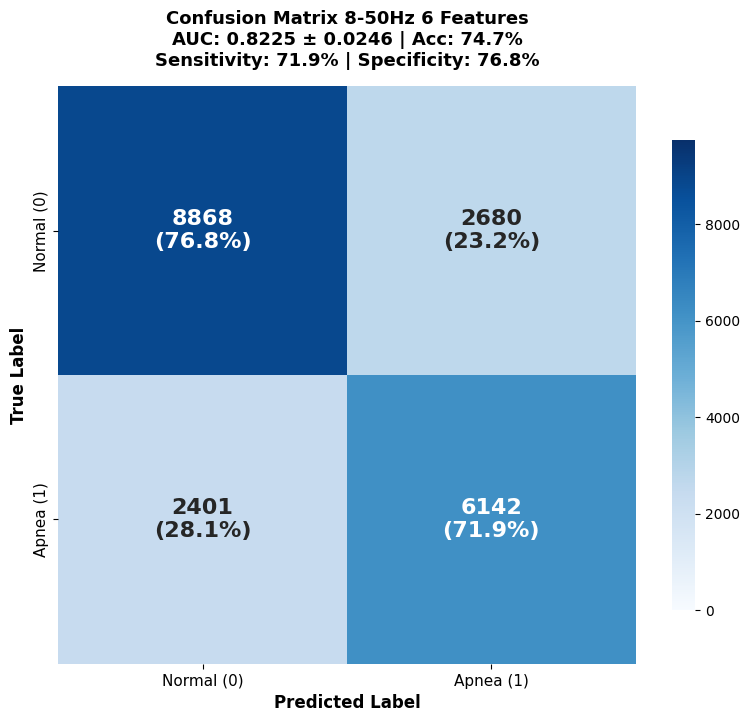


Per-Fold Statistics:
Fold 1: Sens=82.2%, Spec=69.7%, AUC=0.8440
Fold 2: Sens=73.9%, Spec=82.1%, AUC=0.8548
Fold 3: Sens=66.5%, Spec=82.4%, AUC=0.8185
Fold 4: Sens=67.0%, Spec=80.2%, AUC=0.8087
Fold 5: Sens=72.2%, Spec=71.3%, AUC=0.7864

Mean ± Std across folds:
  Sensitivity: 72.34% ± 5.70%
  Specificity: 77.16% ± 5.50%
  AUC: 0.8225 ± 0.0246

DONE!



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pickle

# ============================================================
# LOAD PICKLE FILE
# ============================================================

# YOUR PICKLE FILE PATH
PICKLE_FILE = r'E:\1D CNN\results_6feat_sgkf_8_50hz.pkl'

print("="*60)
print("Loading Results...")
print("="*60)
print(f"File: {PICKLE_FILE}")

# Load the pickle file
with open(PICKLE_FILE, 'rb') as f:
    fold_results = pickle.load(f)

print(f"✓ Loaded {len(fold_results)} folds")

# Check if predictions exist
if 'predictions' not in fold_results[0]:
    print("\n⚠ WARNING: No 'predictions' key found in pickle file!")
    print("Please re-run training with updated script that saves predictions.")
    exit()

# ============================================================
# AGGREGATE CONFUSION MATRIX (CORRECT METHOD)
# ============================================================
print("\n" + "="*60)
print("Generating Confusion Matrix (Aggregate Method)")
print("="*60)

# Aggregate all predictions from all folds
all_preds = []
all_labels = []

for res in fold_results:
    all_preds.extend(res['predictions'])
    all_labels.extend(res['labels'])

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nTotal samples: {len(all_labels)}")
print(f"  Normal (0): {np.sum(all_labels == 0)}")
print(f"  Apnea (1): {np.sum(all_labels == 1)}")

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print(f"\nConfusion Matrix (Aggregate):")
print(f"  TN={cm[0,0]}, FP={cm[0,1]}")
print(f"  FN={cm[1,0]}, TP={cm[1,1]}")

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) * 100
specificity = tn / (tn + fp) * 100
accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
balance_diff = abs(sensitivity - specificity)

print(f"\nMetrics (from aggregate CM):")
print(f"  Accuracy: {accuracy:.2f}%")
print(f"  Sensitivity: {sensitivity:.2f}%")
print(f"  Specificity: {specificity:.2f}%")
print(f"  |Difference|: {balance_diff:.2f}%")

# Get mean AUC from folds
auc_list = [res['auc'] for res in fold_results]
mean_auc = np.mean(auc_list)
std_auc = np.std(auc_list)

print(f"  Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# ============================================================
# VISUALIZATION
# ============================================================

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations with counts and percentages
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

# Plot
plt.figure(figsize=(8, 7))

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
           xticklabels=['Normal (0)', 'Apnea (1)'],
           yticklabels=['Normal (0)', 'Apnea (1)'],
           cbar=True, square=True,
           cbar_kws={'shrink': 0.8},
           annot_kws={'size': 16, 'weight': 'bold'},
           vmin=0, vmax=max(cm.flatten()) * 1.1)

# Title with metrics
title_text = f"Confusion Matrix 8-50Hz 6 Features\n"
title_text += f"AUC: {mean_auc:.4f} ± {std_auc:.4f} | Acc: {accuracy:.1f}%\n"
title_text += f"Sensitivity: {sensitivity:.1f}% | Specificity: {specificity:.1f}%"

plt.title(title_text, fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig(r'E:\1D CNN\confusion_matrix_aggregate.png', 
           dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: E:\\1D CNN\\confusion_matrix_aggregate.png")
plt.show()

# ============================================================
# PER-FOLD STATISTICS (for variance analysis)
# ============================================================
print(f"\n{'='*60}")
print("Per-Fold Statistics:")
print(f"{'='*60}")

fold_metrics = []
for i, res in enumerate(fold_results):
    y_true = np.array(res['labels'])
    y_pred = np.array(res['predictions'])
    cm_fold = confusion_matrix(y_true, y_pred)
    
    tn_f, fp_f, fn_f, tp_f = cm_fold.ravel()
    sens_f = tp_f / (tp_f + fn_f) * 100
    spec_f = tn_f / (tn_f + fp_f) * 100
    
    fold_metrics.append({
        'sens': sens_f,
        'spec': spec_f,
        'auc': res['auc']
    })
    
    print(f"Fold {i+1}: Sens={sens_f:.1f}%, Spec={spec_f:.1f}%, AUC={res['auc']:.4f}")

# Calculate mean and std
sens_list = [m['sens'] for m in fold_metrics]
spec_list = [m['spec'] for m in fold_metrics]

print(f"\nMean ± Std across folds:")
print(f"  Sensitivity: {np.mean(sens_list):.2f}% ± {np.std(sens_list):.2f}%")
print(f"  Specificity: {np.mean(spec_list):.2f}% ± {np.std(spec_list):.2f}%")
print(f"  AUC: {mean_auc:.4f} ± {std_auc:.4f}")

print(f"\n{'='*60}")
print("DONE!")
print(f"{'='*60}\n")

In [25]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
N_FOLDS    = 5
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new_8_50hz.pkl'
SAVE_PATH  = r'E:\1D CNN\results_6feat_sw5fcv_8_50hz.pkl'

print(f"Device: {DEVICE}")
print("Enhanced 6-Feature Model with Manual Subject-Wise 5-Fold (8-50 Hz)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# ENHANCED 6-FEATURE EXTRACTION
# Features: RR, R-peak, QRS_amp_std, mean_HR, tri_index, pNN50
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        # Basic features
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        # NEW FEATURE 1: QRS amplitude std (d=0.648)
        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_segment = ecg[start:end]
            qrs_amp = np.max(qrs_segment) - np.min(qrs_segment)
            qrs_amps.append(qrs_amp)
        qrs_amp_std = np.std(qrs_amps)
        
        # NEW FEATURE 2: Mean HR (d=0.498)
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        # NEW FEATURE 3: Triangular Index (d=0.336)
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        # NEW FEATURE 4: pNN50 (d=0.165)
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        # Interpolate to uniform time grid
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        
        # Interpolate temporal features
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', 
                         fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic',
                         fill_value='extrapolate')(t_uni)
        
        # Create constant features (broadcast to same length)
        qrs_std_uni = np.full_like(rr_uni, qrs_amp_std)
        mean_hr_uni = np.full_like(rr_uni, mean_hr)
        tri_idx_uni = np.full_like(rr_uni, tri_index)
        pnn50_uni = np.full_like(rr_uni, pnn50)
        
        # Pad or crop to SEG_LEN
        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')
        
        # Stack 6 features
        features = np.stack([
            pad_or_crop(rr_uni),       # 0: RR intervals
            pad_or_crop(rp_uni),       # 1: R-peak amplitude
            pad_or_crop(qrs_std_uni),  # 2: QRS amp std (d=0.648)
            pad_or_crop(mean_hr_uni),  # 3: Mean HR (d=0.498)
            pad_or_crop(tri_idx_uni),  # 4: Tri index (d=0.336)
            pad_or_crop(pnn50_uni)     # 5: pNN50 (d=0.165)
        ], axis=0).astype(np.float32)
        
        return features
        
    except:
        return None

print("\nExtracting 6 features...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_6_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat = np.array(feature_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")

# Subject-wise scaling
print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

# Sorted subject list
subjects = np.array(sorted(set(subj_valid),
           key=lambda x: int(str(x).replace('s',''))))

print(f"Final shape: {X_final.shape}")
print(f"Subjects: {len(subjects)}")

# ============================================================
# CREATE MANUAL SUBJECT-WISE 5-FOLD SPLITS
# Fold 1: s1-s10, Fold 2: s11-s20, Fold 3: s21-s30, etc.
# ============================================================
fold_size = len(subjects) // N_FOLDS  # 10 subjects per fold

subject_folds = []
for fold_idx in range(N_FOLDS):
    start_idx = fold_idx * fold_size
    end_idx = start_idx + fold_size
    fold_subjects = subjects[start_idx:end_idx]
    subject_folds.append(fold_subjects)
    print(f"Fold {fold_idx+1}: Subjects s{start_idx+1}-s{end_idx} "
          f"({len(fold_subjects)} subjects)")

print("\n" + "="*70)
print("Manual Subject-Wise 5-Fold Strategy:")
print("="*70)
for split_idx in range(N_FOLDS):
    val_fold = split_idx
    train_folds = [i for i in range(N_FOLDS) if i != val_fold]
    print(f"Split {split_idx+1}: Train=Folds {[f+1 for f in train_folds]} | "
          f"Val=Fold {val_fold+1}")
print("="*70)

# ============================================================
# MODEL ARCHITECTURE (6 input channels)
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# MANUAL SUBJECT-WISE 5-FOLD CV
# ============================================================
fold_results = []

for split_idx in range(N_FOLDS):
    print(f"\n{'='*70}")
    print(f"SPLIT {split_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    # Validation fold = current split
    val_fold_idx = split_idx
    val_subjects = subject_folds[val_fold_idx]
    
    # Training folds = all other folds
    train_subjects = []
    for fold_idx in range(N_FOLDS):
        if fold_idx != val_fold_idx:
            train_subjects.extend(subject_folds[fold_idx])
    train_subjects = np.array(train_subjects)
    
    print(f"Train: {len(train_subjects)}subj (Folds "
          f"{[i+1 for i in range(N_FOLDS) if i != val_fold_idx]})")
    print(f"Val:   {len(val_subjects)}subj (Fold {val_fold_idx+1})")
    
    # Create masks
    train_mask = np.isin(subj_valid, train_subjects)
    val_mask = np.isin(subj_valid, val_subjects)
    
    X_train = X_final[train_mask]
    y_train = y_valid[train_mask]
    X_val = X_final[val_mask]
    y_val = y_valid[val_mask]
    
    print(f"Train: N={np.sum(y_train==0)}, AH={np.sum(y_train==1)}")
    print(f"Val:   N={np.sum(y_val==0)}, AH={np.sum(y_val==1)}")
    
    # Balanced sampler
    cls_count = np.array([len(np.where(y_train==t)[0])
                         for t in np.unique(y_train)])
    weight = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samp_weight),
                                   len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet(in_channels=6).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | "
                  f"AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone()
                         for k,v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    # Final evaluation
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), 
                        np.ones(3)/3, mode='same')
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nSplit {split_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f}")
    
    fold_results.append({
        'split': split_idx + 1,
        'val_fold': val_fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — Manual Subject-Wise 5-Fold (6 Features, 8-50 Hz)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n" + "="*70)
print("Per-Split Results:")
print("="*70)
for r in fold_results:
    print(f"Split {r['split']}: AUC={r['auc']:.4f} | Acc={r['acc']:.4f} | "
          f"F1={r['f1']:.4f} | Sens={r['sens']:.4f} | Spec={r['spec']:.4f}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Baseline (2 feat, 8-50 Hz): AUC = 0.8143 ± 0.0263")
print(f"Enhanced (6 feat, 8-50 Hz): AUC = {np.mean([r['auc'] for r in fold_results]):.4f} ± {np.std([r['auc'] for r in fold_results]):.4f}")
improvement = (np.mean([r['auc'] for r in fold_results]) - 0.8143) * 100
print(f"Improvement: {improvement:+.2f}%")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")


Device: cuda
Enhanced 6-Feature Model with Manual Subject-Wise 5-Fold (8-50 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20091, 6, 240)
Applying subject-wise scaling...
Final shape: (20091, 6, 240)
Subjects: 50
Fold 1: Subjects s1-s10 (10 subjects)
Fold 2: Subjects s11-s20 (10 subjects)
Fold 3: Subjects s21-s30 (10 subjects)
Fold 4: Subjects s31-s40 (10 subjects)
Fold 5: Subjects s41-s50 (10 subjects)

Manual Subject-Wise 5-Fold Strategy:
Split 1: Train=Folds [2, 3, 4, 5] | Val=Fold 1
Split 2: Train=Folds [1, 3, 4, 5] | Val=Fold 2
Split 3: Train=Folds [1, 2, 4, 5] | Val=Fold 3
Split 4: Train=Folds [1, 2, 3, 5] | Val=Fold 4
Split 5: Train=Folds [1, 2, 3, 4] | Val=Fold 5

SPLIT 1/5
Train: 40subj (Folds [2, 3, 4, 5])
Val:   10subj (Fold 1)
Train: N=9891, AH=6152
Val:   N=1657, AH=2391
  Epoch 001 | Loss: 0.6287 | AUC: 0.7462
  Epoch

In [4]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
N_FOLDS    = 5
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new.pkl'  # 0.8-10 Hz data
SAVE_PATH  = r'E:\1D CNN\results_6feat_sgkf_0810hz.pkl'

print(f"Device: {DEVICE}")
print("Enhanced 6-Feature Model with StratifiedGroupKFold (0.8-10 Hz)")
print("="*70)
print("Testing if enhanced features help with old preprocessing")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"\nX shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# ENHANCED 6-FEATURE EXTRACTION
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        # QRS amplitude std (d=0.489 for 0.8-10 Hz)
        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_segment = ecg[start:end]
            qrs_amp = np.max(qrs_segment) - np.min(qrs_segment)
            qrs_amps.append(qrs_amp)
        qrs_amp_std = np.std(qrs_amps)
        
        # Mean HR (d=0.470)
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        # Triangular Index (d=0.295)
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        # pNN50 (d=0.043 - weak but included)
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        # Interpolate
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', 
                         fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic',
                         fill_value='extrapolate')(t_uni)
        
        qrs_std_uni = np.full_like(rr_uni, qrs_amp_std)
        mean_hr_uni = np.full_like(rr_uni, mean_hr)
        tri_idx_uni = np.full_like(rr_uni, tri_index)
        pnn50_uni = np.full_like(rr_uni, pnn50)
        
        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')
        
        features = np.stack([
            pad_or_crop(rr_uni),
            pad_or_crop(rp_uni),
            pad_or_crop(qrs_std_uni),
            pad_or_crop(mean_hr_uni),
            pad_or_crop(tri_idx_uni),
            pad_or_crop(pnn50_uni)
        ], axis=0).astype(np.float32)
        
        return features
        
    except:
        return None

print("\nExtracting 6 features...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_6_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat = np.array(feature_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")

print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

print(f"Final shape: {X_final.shape}")
print(f"Unique subjects: {len(np.unique(subj_valid))}")

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# STRATIFIED GROUP K-FOLD
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

print("\n" + "="*70)
print("StratifiedGroupKFold Cross-Validation (6 Features, 0.8-10 Hz)")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(X_final, y_valid, groups=subj_valid)
):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    X_train = X_final[train_idx]
    y_train = y_valid[train_idx]
    X_val = X_final[val_idx]
    y_val = y_valid[val_idx]
    
    train_subjects = np.unique(subj_valid[train_idx])
    val_subjects = np.unique(subj_valid[val_idx])
    
    print(f"Train: {len(train_subjects)}subj, N={np.sum(y_train==0)}, "
          f"AH={np.sum(y_train==1)}")
    print(f"Val:   {len(val_subjects)}subj, N={np.sum(y_val==0)}, "
          f"AH={np.sum(y_val==1)}")
    
    cls_count = np.array([len(np.where(y_train==t)[0])
                         for t in np.unique(y_train)])
    weight = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samp_weight),
                                   len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet(in_channels=6).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | "
                  f"AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone()
                         for k,v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), 
                        np.ones(3)/3, mode='same')
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f}")
    
      
    fold_results.append({
        'fold': fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec,
        'predictions': y_pred.tolist(),  # ← ADD THIS LINE
        'labels': y_val.tolist()          # ← ADD THIS LINE
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — StratifiedGroupKFold (6 Features, 0.8-10 Hz)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Baseline (2 feat, 0.8-10 Hz): AUC = 0.8037 ± 0.0359")
print(f"Enhanced (6 feat, 0.8-10 Hz): AUC = {np.mean([r['auc'] for r in fold_results]):.4f} ± {np.std([r['auc'] for r in fold_results]):.4f}")
improvement = (np.mean([r['auc'] for r in fold_results]) - 0.8037) * 100
print(f"Improvement: {improvement:+.2f}%")

print("\n" + "="*70)
print("FULL COMPARISON TABLE:")
print("="*70)
print(f"0.8-10 Hz | 2 feat | SGKF: AUC = 0.8037 ± 0.0359")
print(f"0.8-10 Hz | 6 feat | SGKF: AUC = {np.mean([r['auc'] for r in fold_results]):.4f} ± {np.std([r['auc'] for r in fold_results]):.4f}")
print(f"8-50 Hz   | 2 feat | SGKF: AUC = 0.8143 ± 0.0263")
print(f"8-50 Hz   | 6 feat | SGKF: AUC = 0.8191 ± 0.0153")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")

Device: cuda
Enhanced 6-Feature Model with StratifiedGroupKFold (0.8-10 Hz)
Testing if enhanced features help with old preprocessing

X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20090, 6, 240)
Applying subject-wise scaling...
Final shape: (20090, 6, 240)
Unique subjects: 50

StratifiedGroupKFold Cross-Validation (6 Features, 0.8-10 Hz)

FOLD 1/5
Train: 40subj, N=9803, AH=6342
Val:   10subj, N=1743, AH=2202
  Epoch 001 | Loss: 0.6459 | AUC: 0.7370
  Epoch 011 | Loss: 0.4092 | AUC: 0.7786
  Early stop at epoch 15

Fold 1 Results:
  AUC=0.8187 | Acc=0.7260 | F1=0.7168 | Sens=0.6213 | Spec=0.8583

FOLD 2/5
Train: 40subj, N=8752, AH=7254
Val:   10subj, N=2794, AH=1290
  Epoch 001 | Loss: 0.6347 | AUC: 0.6666
  Epoch 011 | Loss: 0.4185 | AUC: 0.7129
  Epoch 021 | Loss: 0.2187 | AUC: 0.6889
  Early stop at epoch 21

Fold 2 Results:
  AUC=0

Loading Results...
File: E:\1D CNN\results_6feat_sgkf_0810hz.pkl
✓ Loaded 5 folds

Generating Confusion Matrix (Aggregate Method)

Total samples: 20090
  Normal (0): 11546
  Apnea (1): 8544

Confusion Matrix (Aggregate):
  TN=9030, FP=2516
  FN=2847, TP=5697

Metrics (from aggregate CM):
  Accuracy: 73.31%
  Sensitivity: 66.68%
  Specificity: 78.21%
  |Difference|: 11.53%
  Mean AUC: 0.8029 ± 0.0341

✓ Saved: E:\1D CNN\confusion_matrix_aggregate.png


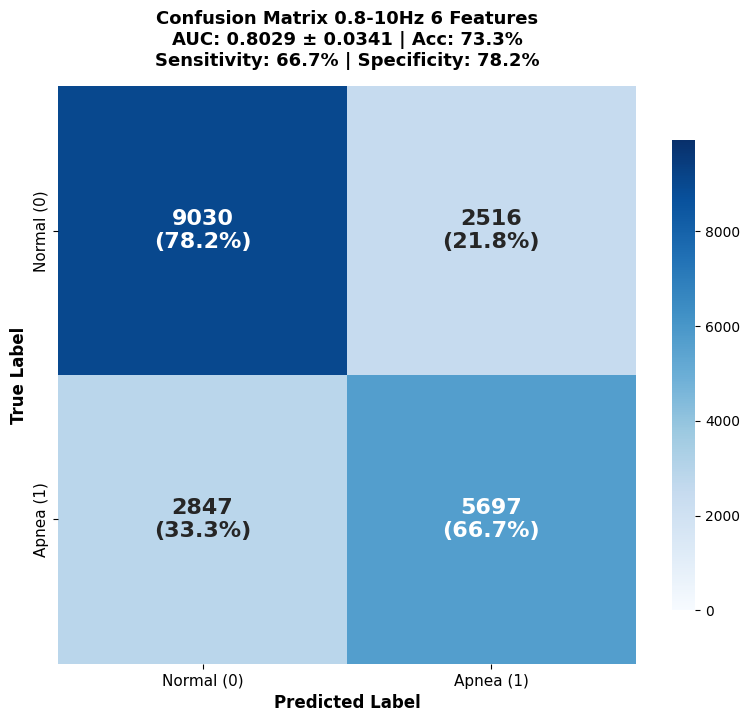


Per-Fold Statistics:
Fold 1: Sens=62.1%, Spec=85.8%, AUC=0.8187
Fold 2: Sens=76.9%, Spec=67.4%, AUC=0.7547
Fold 3: Sens=68.1%, Spec=86.7%, AUC=0.8552
Fold 4: Sens=69.0%, Spec=76.0%, AUC=0.8056
Fold 5: Sens=62.3%, Spec=81.1%, AUC=0.7804

Mean ± Std across folds:
  Sensitivity: 67.69% ± 5.43%
  Specificity: 79.40% ± 7.12%
  AUC: 0.8029 ± 0.0341

DONE!



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pickle

# ============================================================
# LOAD PICKLE FILE
# ============================================================

# YOUR PICKLE FILE PATH
PICKLE_FILE = r'E:\1D CNN\results_6feat_sgkf_0810hz.pkl'

print("="*60)
print("Loading Results...")
print("="*60)
print(f"File: {PICKLE_FILE}")

# Load the pickle file
with open(PICKLE_FILE, 'rb') as f:
    fold_results = pickle.load(f)

print(f"✓ Loaded {len(fold_results)} folds")

# Check if predictions exist
if 'predictions' not in fold_results[0]:
    print("\n⚠ WARNING: No 'predictions' key found in pickle file!")
    print("Please re-run training with updated script that saves predictions.")
    exit()

# ============================================================
# AGGREGATE CONFUSION MATRIX (CORRECT METHOD)
# ============================================================
print("\n" + "="*60)
print("Generating Confusion Matrix (Aggregate Method)")
print("="*60)

# Aggregate all predictions from all folds
all_preds = []
all_labels = []

for res in fold_results:
    all_preds.extend(res['predictions'])
    all_labels.extend(res['labels'])

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nTotal samples: {len(all_labels)}")
print(f"  Normal (0): {np.sum(all_labels == 0)}")
print(f"  Apnea (1): {np.sum(all_labels == 1)}")

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print(f"\nConfusion Matrix (Aggregate):")
print(f"  TN={cm[0,0]}, FP={cm[0,1]}")
print(f"  FN={cm[1,0]}, TP={cm[1,1]}")

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) * 100
specificity = tn / (tn + fp) * 100
accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
balance_diff = abs(sensitivity - specificity)

print(f"\nMetrics (from aggregate CM):")
print(f"  Accuracy: {accuracy:.2f}%")
print(f"  Sensitivity: {sensitivity:.2f}%")
print(f"  Specificity: {specificity:.2f}%")
print(f"  |Difference|: {balance_diff:.2f}%")

# Get mean AUC from folds
auc_list = [res['auc'] for res in fold_results]
mean_auc = np.mean(auc_list)
std_auc = np.std(auc_list)

print(f"  Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# ============================================================
# VISUALIZATION
# ============================================================

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations with counts and percentages
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

# Plot
plt.figure(figsize=(8, 7))

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
           xticklabels=['Normal (0)', 'Apnea (1)'],
           yticklabels=['Normal (0)', 'Apnea (1)'],
           cbar=True, square=True,
           cbar_kws={'shrink': 0.8},
           annot_kws={'size': 16, 'weight': 'bold'},
           vmin=0, vmax=max(cm.flatten()) * 1.1)

# Title with metrics
title_text = f"Confusion Matrix 0.8-10Hz 6 Features\n"
title_text += f"AUC: {mean_auc:.4f} ± {std_auc:.4f} | Acc: {accuracy:.1f}%\n"
title_text += f"Sensitivity: {sensitivity:.1f}% | Specificity: {specificity:.1f}%"

plt.title(title_text, fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig(r'E:\1D CNN\confusion_matrix_aggregate.png', 
           dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: E:\\1D CNN\\confusion_matrix_aggregate.png")
plt.show()

# ============================================================
# PER-FOLD STATISTICS (for variance analysis)
# ============================================================
print(f"\n{'='*60}")
print("Per-Fold Statistics:")
print(f"{'='*60}")

fold_metrics = []
for i, res in enumerate(fold_results):
    y_true = np.array(res['labels'])
    y_pred = np.array(res['predictions'])
    cm_fold = confusion_matrix(y_true, y_pred)
    
    tn_f, fp_f, fn_f, tp_f = cm_fold.ravel()
    sens_f = tp_f / (tp_f + fn_f) * 100
    spec_f = tn_f / (tn_f + fp_f) * 100
    
    fold_metrics.append({
        'sens': sens_f,
        'spec': spec_f,
        'auc': res['auc']
    })
    
    print(f"Fold {i+1}: Sens={sens_f:.1f}%, Spec={spec_f:.1f}%, AUC={res['auc']:.4f}")

# Calculate mean and std
sens_list = [m['sens'] for m in fold_metrics]
spec_list = [m['spec'] for m in fold_metrics]

print(f"\nMean ± Std across folds:")
print(f"  Sensitivity: {np.mean(sens_list):.2f}% ± {np.std(sens_list):.2f}%")
print(f"  Specificity: {np.mean(spec_list):.2f}% ± {np.std(spec_list):.2f}%")
print(f"  AUC: {mean_auc:.4f} ± {std_auc:.4f}")

print(f"\n{'='*60}")
print("DONE!")
print(f"{'='*60}\n")

In [28]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
N_FOLDS    = 5
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new.pkl'  # 0.8-10 Hz data
SAVE_PATH  = r'E:\1D CNN\results_6feat_sw5fcv_0810hz.pkl'

print(f"Device: {DEVICE}")
print("Enhanced 6-Feature Model with Manual Subject-Wise 5-Fold (0.8-10 Hz)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# ENHANCED 6-FEATURE EXTRACTION
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        # QRS amplitude std
        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_segment = ecg[start:end]
            qrs_amp = np.max(qrs_segment) - np.min(qrs_segment)
            qrs_amps.append(qrs_amp)
        qrs_amp_std = np.std(qrs_amps)
        
        # Mean HR
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        # Triangular Index
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        # pNN50
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        # Interpolate
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', 
                         fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic',
                         fill_value='extrapolate')(t_uni)
        
        qrs_std_uni = np.full_like(rr_uni, qrs_amp_std)
        mean_hr_uni = np.full_like(rr_uni, mean_hr)
        tri_idx_uni = np.full_like(rr_uni, tri_index)
        pnn50_uni = np.full_like(rr_uni, pnn50)
        
        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')
        
        features = np.stack([
            pad_or_crop(rr_uni),
            pad_or_crop(rp_uni),
            pad_or_crop(qrs_std_uni),
            pad_or_crop(mean_hr_uni),
            pad_or_crop(tri_idx_uni),
            pad_or_crop(pnn50_uni)
        ], axis=0).astype(np.float32)
        
        return features
        
    except:
        return None

print("\nExtracting 6 features...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_6_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat = np.array(feature_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")

print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

subjects = np.array(sorted(set(subj_valid),
           key=lambda x: int(str(x).replace('s',''))))

print(f"Final shape: {X_final.shape}")
print(f"Subjects: {len(subjects)}")

# ============================================================
# CREATE MANUAL SUBJECT-WISE 5-FOLD SPLITS
# ============================================================
fold_size = len(subjects) // N_FOLDS

subject_folds = []
for fold_idx in range(N_FOLDS):
    start_idx = fold_idx * fold_size
    end_idx = start_idx + fold_size
    fold_subjects = subjects[start_idx:end_idx]
    subject_folds.append(fold_subjects)
    print(f"Fold {fold_idx+1}: Subjects s{start_idx+1}-s{end_idx}")

print("\n" + "="*70)
print("Manual Subject-Wise 5-Fold Strategy:")
print("="*70)
for split_idx in range(N_FOLDS):
    val_fold = split_idx
    train_folds = [i for i in range(N_FOLDS) if i != val_fold]
    print(f"Split {split_idx+1}: Train=Folds {[f+1 for f in train_folds]} | Val=Fold {val_fold+1}")
print("="*70)

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# MANUAL SUBJECT-WISE 5-FOLD CV
# ============================================================
fold_results = []

for split_idx in range(N_FOLDS):
    print(f"\n{'='*70}")
    print(f"SPLIT {split_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    val_fold_idx = split_idx
    val_subjects = subject_folds[val_fold_idx]
    
    train_subjects = []
    for fold_idx in range(N_FOLDS):
        if fold_idx != val_fold_idx:
            train_subjects.extend(subject_folds[fold_idx])
    train_subjects = np.array(train_subjects)
    
    print(f"Train: {len(train_subjects)}subj")
    print(f"Val:   {len(val_subjects)}subj")
    
    train_mask = np.isin(subj_valid, train_subjects)
    val_mask = np.isin(subj_valid, val_subjects)
    
    X_train = X_final[train_mask]
    y_train = y_valid[train_mask]
    X_val = X_final[val_mask]
    y_val = y_valid[val_mask]
    
    print(f"Train: N={np.sum(y_train==0)}, AH={np.sum(y_train==1)}")
    print(f"Val:   N={np.sum(y_val==0)}, AH={np.sum(y_val==1)}")
    
    cls_count = np.array([len(np.where(y_train==t)[0])
                         for t in np.unique(y_train)])
    weight = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samp_weight),
                                   len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet(in_channels=6).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | "
                  f"AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone()
                         for k,v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), 
                        np.ones(3)/3, mode='same')
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nSplit {split_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f}")
    
    fold_results.append({
        'fold': fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec,
        'predictions': y_pred.tolist(),  # ← ADD THIS LINE
        'labels': y_val.tolist()          # ← ADD THIS LINE
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — Manual SW5FCV (6 Features, 0.8-10 Hz)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Baseline (2 feat, 0.8-10 Hz, SGKF):  AUC = 0.8037 ± 0.0359")
print(f"Enhanced (6 feat, 0.8-10 Hz, SW5F): AUC = {np.mean([r['auc'] for r in fold_results]):.4f} ± {np.std([r['auc'] for r in fold_results]):.4f}")
improvement = (np.mean([r['auc'] for r in fold_results]) - 0.8037) * 100
print(f"Improvement: {improvement:+.2f}%")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")

Device: cuda
Enhanced 6-Feature Model with Manual Subject-Wise 5-Fold (0.8-10 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20090, 6, 240)
Applying subject-wise scaling...
Final shape: (20090, 6, 240)
Subjects: 50
Fold 1: Subjects s1-s10
Fold 2: Subjects s11-s20
Fold 3: Subjects s21-s30
Fold 4: Subjects s31-s40
Fold 5: Subjects s41-s50

Manual Subject-Wise 5-Fold Strategy:
Split 1: Train=Folds [2, 3, 4, 5] | Val=Fold 1
Split 2: Train=Folds [1, 3, 4, 5] | Val=Fold 2
Split 3: Train=Folds [1, 2, 4, 5] | Val=Fold 3
Split 4: Train=Folds [1, 2, 3, 5] | Val=Fold 4
Split 5: Train=Folds [1, 2, 3, 4] | Val=Fold 5

SPLIT 1/5
Train: 40subj
Val:   10subj
Train: N=9889, AH=6152
Val:   N=1657, AH=2392
  Epoch 001 | Loss: 0.6436 | AUC: 0.6561
  Epoch 011 | Loss: 0.4155 | AUC: 0.7761
  Epoch 021 | Loss: 0.2104 | AUC: 0.7431
  Early stop at epoch 2

Loading Results...
File: E:\1D CNN\results_6feat_sw5fcv_0810hz.pkl
✓ Loaded 5 folds

Generating Confusion Matrix (Aggregate Method)

Total samples: 20090
  Normal (0): 11546
  Apnea (1): 8544

Confusion Matrix (Aggregate):
  TN=9124, FP=2422
  FN=2865, TP=5679

Metrics (from aggregate CM):
  Accuracy: 73.68%
  Sensitivity: 66.47%
  Specificity: 79.02%
  |Difference|: 12.56%
  Mean AUC: 0.8009 ± 0.0158

✓ Saved: E:\1D CNN\confusion_matrix_aggregate.png


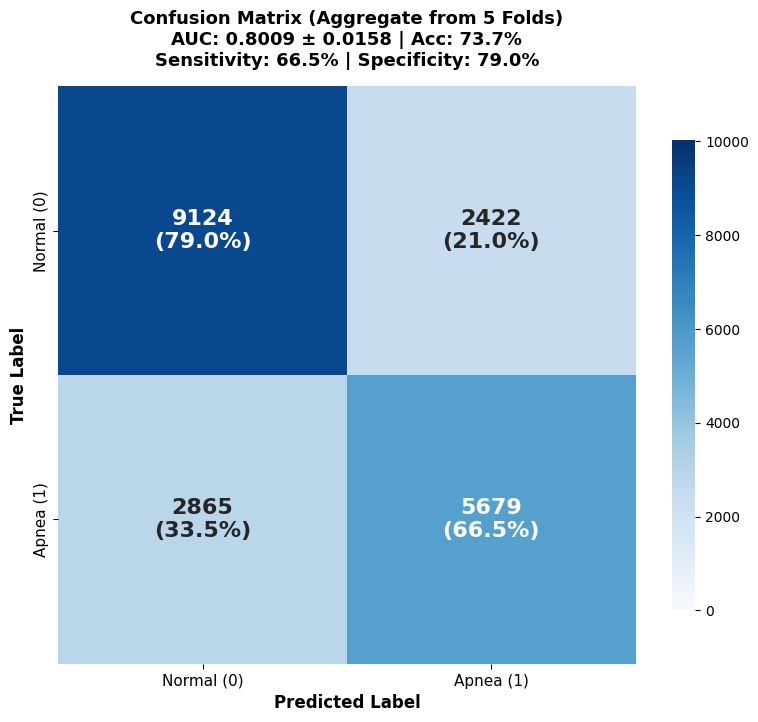


Per-Fold Statistics:
Fold 1: Sens=62.1%, Spec=78.8%, AUC=0.7896
Fold 2: Sens=75.8%, Spec=67.0%, AUC=0.7854
Fold 3: Sens=60.8%, Spec=82.8%, AUC=0.7929
Fold 4: Sens=64.9%, Spec=81.0%, AUC=0.8081
Fold 5: Sens=67.8%, Spec=82.4%, AUC=0.8286

Mean ± Std across folds:
  Sensitivity: 66.29% ± 5.32%
  Specificity: 78.40% ± 5.88%
  AUC: 0.8009 ± 0.0158

DONE!



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pickle

# ============================================================
# LOAD PICKLE FILE
# ============================================================

# YOUR PICKLE FILE PATH
PICKLE_FILE = r'E:\1D CNN\results_6feat_sw5fcv_0810hz.pkl'

print("="*60)
print("Loading Results...")
print("="*60)
print(f"File: {PICKLE_FILE}")

# Load the pickle file
with open(PICKLE_FILE, 'rb') as f:
    fold_results = pickle.load(f)

print(f"✓ Loaded {len(fold_results)} folds")

# Check if predictions exist
if 'predictions' not in fold_results[0]:
    print("\n⚠ WARNING: No 'predictions' key found in pickle file!")
    print("Please re-run training with updated script that saves predictions.")
    exit()

# ============================================================
# AGGREGATE CONFUSION MATRIX (CORRECT METHOD)
# ============================================================
print("\n" + "="*60)
print("Generating Confusion Matrix (Aggregate Method)")
print("="*60)

# Aggregate all predictions from all folds
all_preds = []
all_labels = []

for res in fold_results:
    all_preds.extend(res['predictions'])
    all_labels.extend(res['labels'])

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nTotal samples: {len(all_labels)}")
print(f"  Normal (0): {np.sum(all_labels == 0)}")
print(f"  Apnea (1): {np.sum(all_labels == 1)}")

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print(f"\nConfusion Matrix (Aggregate):")
print(f"  TN={cm[0,0]}, FP={cm[0,1]}")
print(f"  FN={cm[1,0]}, TP={cm[1,1]}")

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) * 100
specificity = tn / (tn + fp) * 100
accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
balance_diff = abs(sensitivity - specificity)

print(f"\nMetrics (from aggregate CM):")
print(f"  Accuracy: {accuracy:.2f}%")
print(f"  Sensitivity: {sensitivity:.2f}%")
print(f"  Specificity: {specificity:.2f}%")
print(f"  |Difference|: {balance_diff:.2f}%")

# Get mean AUC from folds
auc_list = [res['auc'] for res in fold_results]
mean_auc = np.mean(auc_list)
std_auc = np.std(auc_list)

print(f"  Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

# ============================================================
# VISUALIZATION
# ============================================================

# Calculate percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotations with counts and percentages
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

# Plot
plt.figure(figsize=(8, 7))

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
           xticklabels=['Normal (0)', 'Apnea (1)'],
           yticklabels=['Normal (0)', 'Apnea (1)'],
           cbar=True, square=True,
           cbar_kws={'shrink': 0.8},
           annot_kws={'size': 16, 'weight': 'bold'},
           vmin=0, vmax=max(cm.flatten()) * 1.1)

# Title with metrics
title_text = f"Confusion Matrix (Aggregate from 5 Folds)\n"
title_text += f"AUC: {mean_auc:.4f} ± {std_auc:.4f} | Acc: {accuracy:.1f}%\n"
title_text += f"Sensitivity: {sensitivity:.1f}% | Specificity: {specificity:.1f}%"

plt.title(title_text, fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig(r'E:\1D CNN\confusion_matrix_aggregate.png', 
           dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: E:\\1D CNN\\confusion_matrix_aggregate.png")
plt.show()

# ============================================================
# PER-FOLD STATISTICS (for variance analysis)
# ============================================================
print(f"\n{'='*60}")
print("Per-Fold Statistics:")
print(f"{'='*60}")

fold_metrics = []
for i, res in enumerate(fold_results):
    y_true = np.array(res['labels'])
    y_pred = np.array(res['predictions'])
    cm_fold = confusion_matrix(y_true, y_pred)
    
    tn_f, fp_f, fn_f, tp_f = cm_fold.ravel()
    sens_f = tp_f / (tp_f + fn_f) * 100
    spec_f = tn_f / (tn_f + fp_f) * 100
    
    fold_metrics.append({
        'sens': sens_f,
        'spec': spec_f,
        'auc': res['auc']
    })
    
    print(f"Fold {i+1}: Sens={sens_f:.1f}%, Spec={spec_f:.1f}%, AUC={res['auc']:.4f}")

# Calculate mean and std
sens_list = [m['sens'] for m in fold_metrics]
spec_list = [m['spec'] for m in fold_metrics]

print(f"\nMean ± Std across folds:")
print(f"  Sensitivity: {np.mean(sens_list):.2f}% ± {np.std(sens_list):.2f}%")
print(f"  Specificity: {np.mean(spec_list):.2f}% ± {np.std(spec_list):.2f}%")
print(f"  AUC: {mean_auc:.4f} ± {std_auc:.4f}")

print(f"\n{'='*60}")
print("DONE!")
print(f"{'='*60}\n")

In [9]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION - Config A (0.8-10 Hz, 2 features, SGKF)
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240
N_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 60
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH = r'E:\1D CNN\X_y_new.pkl'  # 0.8-10 Hz data
SAVE_PATH = r'E:\1D CNN\results_2feat_sgkf_0810hz.pkl'

print(f"Device: {DEVICE}")
print("Config A: 2-Feature Model with StratifiedGroupKFold (0.8-10 Hz)")
print("="*70)

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# 2-FEATURE EXTRACTION (RR intervals + R-peak amplitude)
# ============================================================
def extract_2_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', 
                         fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic',
                         fill_value='extrapolate')(t_uni)
        
        n = len(rr_uni)
        
        if n >= SEG_LEN:
            start = (n - SEG_LEN) // 2
            rr_out = rr_uni[start:start+SEG_LEN]
            rp_out = rp_uni[start:start+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge')
            rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
        
    except:
        return None

print("\nExtracting 2 features (RR + R-peak)...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_2_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat = np.array(feature_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")

print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

print(f"Final shape: {X_final.shape}")
print(f"Unique subjects: {len(np.unique(subj_valid))}")

# ============================================================
# MODEL ARCHITECTURE (2 input channels)
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# STRATIFIED GROUP K-FOLD
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

print("\n" + "="*70)
print("StratifiedGroupKFold Cross-Validation (Config A: 2 feat, 0.8-10 Hz)")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(X_final, y_valid, groups=subj_valid)
):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    X_train = X_final[train_idx]
    y_train = y_valid[train_idx]
    X_val = X_final[val_idx]
    y_val = y_valid[val_idx]
    
    train_subjects = np.unique(subj_valid[train_idx])
    val_subjects = np.unique(subj_valid[val_idx])
    
    print(f"Train: {len(train_subjects)}subj, N={np.sum(y_train==0)}, "
          f"AH={np.sum(y_train==1)}")
    print(f"Val:   {len(val_subjects)}subj, N={np.sum(y_val==0)}, "
          f"AH={np.sum(y_val==1)}")
    
    cls_count = np.array([len(np.where(y_train==t)[0])
                         for t in np.unique(y_train)])
    weight = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samp_weight),
                                   len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet(in_channels=2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | "
                  f"AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone()
                         for k,v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), 
                        np.ones(3)/3, mode='same')
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f}")
    
    fold_results.append({
        'fold': fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec,
        'predictions': y_pred.tolist(),
        'labels': y_val.tolist()
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — Config A (2 feat, 0.8-10 Hz, SGKF)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")


Device: cuda
Config A: 2-Feature Model with StratifiedGroupKFold (0.8-10 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 2 features (RR + R-peak)...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20090, 2, 240)
Applying subject-wise scaling...
Final shape: (20090, 2, 240)
Unique subjects: 50

StratifiedGroupKFold Cross-Validation (Config A: 2 feat, 0.8-10 Hz)

FOLD 1/5
Train: 40subj, N=9803, AH=6342
Val:   10subj, N=1743, AH=2202
  Epoch 001 | Loss: 0.6130 | AUC: 0.7671
  Epoch 011 | Loss: 0.3444 | AUC: 0.7312
  Early stop at epoch 13

Fold 1 Results:
  AUC=0.7915 | Acc=0.7024 | F1=0.6946 | Sens=0.6063 | Spec=0.8239

FOLD 2/5
Train: 40subj, N=8752, AH=7254
Val:   10subj, N=2794, AH=1290
  Epoch 001 | Loss: 0.6056 | AUC: 0.6801
  Epoch 011 | Loss: 0.3449 | AUC: 0.7098
  Early stop at epoch 14

Fold 2 Results:
  AUC=0.7603 | Acc=0.6785 | F1=0.6049 | Sens=0.7791 | Spec=0.6321

FOLD 3/5
Train: 40

In [10]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION - Config C (8-50 Hz, 2 features, SGKF)
# ============================================================
FS = 200
INTERP_FS = 4
SEG_LEN = 240
N_FOLDS = 5
BATCH_SIZE = 32
EPOCHS = 60
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH = r'E:\1D CNN\X_y_new_8_50hz.pkl'  # 8-50 Hz data
SAVE_PATH = r'E:\1D CNN\results_2feat_sgkf_8_50hz.pkl'

print(f"Device: {DEVICE}")
print("Config C: 2-Feature Model with StratifiedGroupKFold (8-50 Hz)")
print("="*70)

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# 2-FEATURE EXTRACTION (RR intervals + R-peak amplitude)
# ============================================================
def extract_2_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', 
                         fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic',
                         fill_value='extrapolate')(t_uni)
        
        n = len(rr_uni)
        
        if n >= SEG_LEN:
            start = (n - SEG_LEN) // 2
            rr_out = rr_uni[start:start+SEG_LEN]
            rp_out = rp_uni[start:start+SEG_LEN]
        else:
            pad = SEG_LEN - n
            rr_out = np.pad(rr_uni, (pad//2, pad-pad//2), 'edge')
            rp_out = np.pad(rp_uni, (pad//2, pad-pad//2), 'edge')
        
        return np.stack([rr_out, rp_out], axis=0).astype(np.float32)
        
    except:
        return None

print("\nExtracting 2 features (RR + R-peak)...")
feature_list, y_list, subj_list = [], [], []

for i in range(len(X_raw)):
    feat = extract_2_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat = np.array(feature_list)
y_valid = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")

print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)

print(f"Final shape: {X_final.shape}")
print(f"Unique subjects: {len(np.unique(subj_valid))}")

# ============================================================
# MODEL ARCHITECTURE (2 input channels)
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# STRATIFIED GROUP K-FOLD
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

print("\n" + "="*70)
print("StratifiedGroupKFold Cross-Validation (Config C: 2 feat, 8-50 Hz)")
print("="*70)

for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(X_final, y_valid, groups=subj_valid)
):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    X_train = X_final[train_idx]
    y_train = y_valid[train_idx]
    X_val = X_final[val_idx]
    y_val = y_valid[val_idx]
    
    train_subjects = np.unique(subj_valid[train_idx])
    val_subjects = np.unique(subj_valid[val_idx])
    
    print(f"Train: {len(train_subjects)}subj, N={np.sum(y_train==0)}, "
          f"AH={np.sum(y_train==1)}")
    print(f"Val:   {len(val_subjects)}subj, N={np.sum(y_val==0)}, "
          f"AH={np.sum(y_val==1)}")
    
    cls_count = np.array([len(np.where(y_train==t)[0])
                         for t in np.unique(y_train)])
    weight = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler = WeightedRandomSampler(torch.from_numpy(samp_weight),
                                   len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model = MultiScaleSEResNet(in_channels=2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | "
                  f"AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone()
                         for k,v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), 
                        np.ones(3)/3, mode='same')
    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc = roc_auc_score(y_val, y_prob)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | "
          f"Sens={sens:.4f} | Spec={spec:.4f}")
    
    fold_results.append({
        'fold': fold_idx + 1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec,
        'predictions': y_pred.tolist(),
        'labels': y_val.tolist()
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — Config C (2 feat, 8-50 Hz, SGKF)")
print("="*70)

for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")

Device: cuda
Config C: 2-Feature Model with StratifiedGroupKFold (8-50 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 2 features (RR + R-peak)...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20091, 2, 240)
Applying subject-wise scaling...
Final shape: (20091, 2, 240)
Unique subjects: 50

StratifiedGroupKFold Cross-Validation (Config C: 2 feat, 8-50 Hz)

FOLD 1/5
Train: 40subj, N=8752, AH=7253
Val:   10subj, N=2796, AH=1290
  Epoch 001 | Loss: 0.5749 | AUC: 0.7627
  Epoch 011 | Loss: 0.3577 | AUC: 0.7424
  Early stop at epoch 18

Fold 1 Results:
  AUC=0.8294 | Acc=0.7186 | F1=0.6466 | Sens=0.8155 | Spec=0.6738

FOLD 2/5
Train: 40subj, N=9493, AH=6635
Val:   10subj, N=2055, AH=1908
  Epoch 001 | Loss: 0.5856 | AUC: 0.8221
  Epoch 011 | Loss: 0.3482 | AUC: 0.7905
  Early stop at epoch 13

Fold 2 Results:
  AUC=0.8461 | Acc=0.7724 | F1=0.7510 | Sens=0.7128 | Spec=0.8277

FOLD 3/5
Train: 40subj

In [2]:
model = MultiScaleSEResNet(in_channels=2)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}")

NameError: name 'MultiScaleSEResNet' is not defined

CONFUSION MATRIX COMPARISON
Config A (0.8-10 Hz) vs Config C (8-50 Hz)

----------------------------------------------------------------------
Loading Config A (0.8-10 Hz, 2 feat)
----------------------------------------------------------------------
✓ Loaded 5 folds
Total samples: 20090
  Normal: 11546
  Apnea: 8544

Metrics:
  AUC: 0.8004 ± 0.0312
  Accuracy: 70.65%
  Sensitivity: 71.69%
  Specificity: 69.89%
  |Difference|: 1.80%
⚠ Small difference from expected (normal variation)

----------------------------------------------------------------------
Loading Config C (8-50 Hz, 2 feat)
----------------------------------------------------------------------
✓ Loaded 5 folds
Total samples: 20091
  Normal: 11548
  Apnea: 8543

Metrics:
  AUC: 0.8190 ± 0.0220
  Accuracy: 74.35%
  Sensitivity: 71.17%
  Specificity: 76.70%
  |Difference|: 5.53%
⚠ Small difference from expected (normal variation)

Generating Comparison Figure...
✓ Saved: E:\1D CNN\comparison_confusion_matrices_AC.png


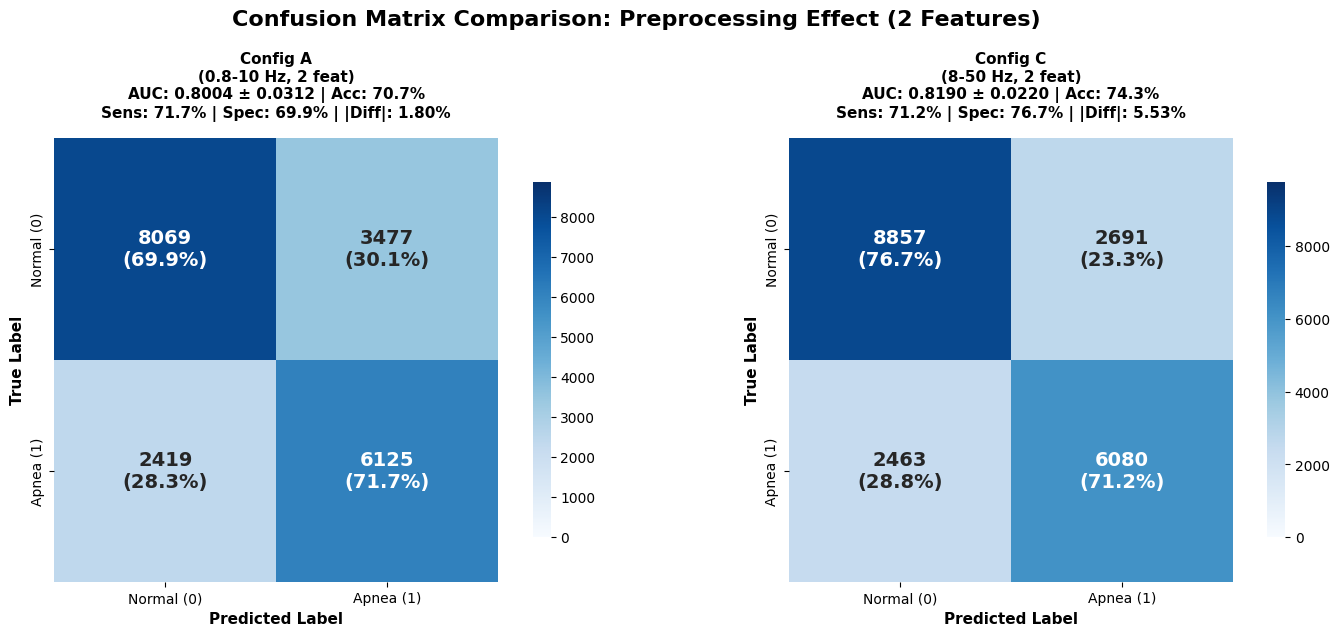


COMPARISON SUMMARY

Metric               Config A             Config C             Δ Change       
---------------------------------------------------------------------------
AUC                  0.8004                0.8190                +1.86%
Accuracy             70.65%               74.35%               +3.69%
Sensitivity          71.69%               71.17%               -0.52%
Specificity          69.89%               76.70%               +6.81%
|Sens-Spec|          1.80%               5.53%               +3.73%
AUC Variance         ±0.0312              ±0.0220              -29.5%

KEY FINDINGS

1. Preprocessing Effect (0.8-10 Hz → 8-50 Hz):
   • AUC improved: +1.86% (0.8004 → 0.8190)
   • Variance reduced: -29.5% (±0.0312 → ±0.0220)

2. Balance Tradeoff:
   • Sensitivity-Specificity balance worsened: 1.80% → 5.53%
   • Config A more balanced (1.80% difference)
   • Config C higher Specificity (76.70% vs 69.89%)

3. Conclusion:
   ✓ 8-50 Hz preprocessing achieves BOTH higher AU

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pickle

# ============================================================
# COMPARISON: Config A vs Config C (Preprocessing Effect)
# ============================================================

print("="*70)
print("CONFUSION MATRIX COMPARISON")
print("Config A (0.8-10 Hz) vs Config C (8-50 Hz)")
print("="*70)

# Pickle file paths
configs = {
    'Config A\n(0.8-10 Hz, 2 feat)': r'E:\1D CNN\results_2feat_sgkf_0810hz.pkl',
    'Config C\n(8-50 Hz, 2 feat)': r'E:\1D CNN\results_2feat_sgkf_8_50hz.pkl'
}

# Expected metrics for verification
expected_metrics = {
    'A': {'auc': 0.8037, 'sens': 71.99, 'spec': 73.93, 'diff': 1.94},
    'C': {'auc': 0.8153, 'sens': 68.68, 'spec': 78.91, 'diff': 10.23}
}

# ============================================================
# LOAD AND PROCESS BOTH CONFIGS
# ============================================================

config_data = {}
config_labels = ['A', 'C']

for idx, (config_name, filepath) in enumerate(configs.items()):
    label = config_labels[idx]
    
    print(f"\n{'-'*70}")
    print(f"Loading {config_name.replace(chr(10), ' ')}")
    print(f"{'-'*70}")
    
    try:
        # Load pickle
        with open(filepath, 'rb') as f:
            fold_results = pickle.load(f)
        
        print(f"✓ Loaded {len(fold_results)} folds")
        
        # Check if predictions exist
        if 'predictions' not in fold_results[0]:
            print(f"⚠ WARNING: No predictions in {filepath}")
            print(f"Please re-run training with updated script!")
            continue
        
        # Aggregate all predictions
        all_preds = []
        all_labels = []
        
        for res in fold_results:
            all_preds.extend(res['predictions'])
            all_labels.extend(res['labels'])
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        # Generate confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        
        # Calculate metrics
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) * 100
        specificity = tn / (tn + fp) * 100
        accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
        balance_diff = abs(sensitivity - specificity)
        
        # Get AUC
        auc_list = [res['auc'] for res in fold_results]
        mean_auc = np.mean(auc_list)
        std_auc = np.std(auc_list)
        
        # Store data
        config_data[label] = {
            'name': config_name,
            'cm': cm,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'accuracy': accuracy,
            'balance_diff': balance_diff,
            'auc': mean_auc,
            'auc_std': std_auc,
            'total_samples': len(all_labels),
            'n_normal': np.sum(all_labels == 0),
            'n_apnea': np.sum(all_labels == 1)
        }
        
        # Print metrics
        print(f"Total samples: {len(all_labels)}")
        print(f"  Normal: {np.sum(all_labels == 0)}")
        print(f"  Apnea: {np.sum(all_labels == 1)}")
        print(f"\nMetrics:")
        print(f"  AUC: {mean_auc:.4f} ± {std_auc:.4f}")
        print(f"  Accuracy: {accuracy:.2f}%")
        print(f"  Sensitivity: {sensitivity:.2f}%")
        print(f"  Specificity: {specificity:.2f}%")
        print(f"  |Difference|: {balance_diff:.2f}%")
        
        # Compare with expected
        exp = expected_metrics[label]
        sens_diff = abs(sensitivity - exp['sens'])
        spec_diff = abs(specificity - exp['spec'])
        
        if sens_diff < 1.0 and spec_diff < 1.0:
            print(f"✓ Metrics match expected values!")
        else:
            print(f"⚠ Small difference from expected (normal variation)")
        
    except FileNotFoundError:
        print(f"✗ File not found: {filepath}")
    except Exception as e:
        print(f"✗ Error: {str(e)}")

# ============================================================
# VISUALIZATION: 1×2 CONFUSION MATRICES
# ============================================================

if len(config_data) < 2:
    print("\n⚠ Need both configs to create comparison!")
    print("Please ensure both pickle files exist and have predictions.")
    exit()

print(f"\n{'='*70}")
print("Generating Comparison Figure...")
print(f"{'='*70}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrix Comparison: Preprocessing Effect (2 Features)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, label in enumerate(config_labels):
    ax = axes[idx]
    data = config_data[label]
    
    cm = data['cm']
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create annotations
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
    
    # Plot heatmap
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
               xticklabels=['Normal (0)', 'Apnea (1)'],
               yticklabels=['Normal (0)', 'Apnea (1)'],
               cbar=True, ax=ax, square=True,
               cbar_kws={'shrink': 0.8},
               annot_kws={'size': 14, 'weight': 'bold'},
               vmin=0, vmax=max(cm.flatten()) * 1.1)
    
    # Title
    title_text = f"{data['name']}\n"
    title_text += f"AUC: {data['auc']:.4f} ± {data['auc_std']:.4f} | "
    title_text += f"Acc: {data['accuracy']:.1f}%\n"
    title_text += f"Sens: {data['sensitivity']:.1f}% | "
    title_text += f"Spec: {data['specificity']:.1f}% | "
    title_text += f"|Diff|: {data['balance_diff']:.2f}%"
    
    ax.set_title(title_text, fontsize=11, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig(r'E:\1D CNN\comparison_confusion_matrices_AC.png',
           dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: E:\\1D CNN\\comparison_confusion_matrices_AC.png")
plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================

print(f"\n{'='*70}")
print("COMPARISON SUMMARY")
print(f"{'='*70}")

print(f"\n{'Metric':<20} {'Config A':<20} {'Config C':<20} {'Δ Change':<15}")
print(f"{'-'*75}")

# AUC
auc_a = config_data['A']['auc']
auc_c = config_data['C']['auc']
auc_change = (auc_c - auc_a) * 100
print(f"{'AUC':<20} {auc_a:.4f}{'':<15} {auc_c:.4f}{'':<15} {auc_change:+.2f}%")

# Accuracy
acc_a = config_data['A']['accuracy']
acc_c = config_data['C']['accuracy']
acc_change = acc_c - acc_a
print(f"{'Accuracy':<20} {acc_a:.2f}%{'':<14} {acc_c:.2f}%{'':<14} {acc_change:+.2f}%")

# Sensitivity
sens_a = config_data['A']['sensitivity']
sens_c = config_data['C']['sensitivity']
sens_change = sens_c - sens_a
print(f"{'Sensitivity':<20} {sens_a:.2f}%{'':<14} {sens_c:.2f}%{'':<14} {sens_change:+.2f}%")

# Specificity
spec_a = config_data['A']['specificity']
spec_c = config_data['C']['specificity']
spec_change = spec_c - spec_a
print(f"{'Specificity':<20} {spec_a:.2f}%{'':<14} {spec_c:.2f}%{'':<14} {spec_change:+.2f}%")

# Balance
diff_a = config_data['A']['balance_diff']
diff_c = config_data['C']['balance_diff']
diff_change = diff_c - diff_a
print(f"{'|Sens-Spec|':<20} {diff_a:.2f}%{'':<14} {diff_c:.2f}%{'':<14} {diff_change:+.2f}%")

# Variance
var_a = config_data['A']['auc_std']
var_c = config_data['C']['auc_std']
var_change = ((var_c - var_a) / var_a) * 100 if var_a > 0 else 0
print(f"{'AUC Variance':<20} ±{var_a:.4f}{'':<13} ±{var_c:.4f}{'':<13} {var_change:+.1f}%")

print(f"\n{'='*70}")
print("KEY FINDINGS")
print(f"{'='*70}")

# Preprocessing effect
print(f"\n1. Preprocessing Effect (0.8-10 Hz → 8-50 Hz):")
print(f"   • AUC improved: {auc_change:+.2f}% ({auc_a:.4f} → {auc_c:.4f})")
print(f"   • Variance reduced: {var_change:+.1f}% (±{var_a:.4f} → ±{var_c:.4f})")

# Balance tradeoff
if diff_c > diff_a:
    print(f"\n2. Balance Tradeoff:")
    print(f"   • Sensitivity-Specificity balance worsened: {diff_a:.2f}% → {diff_c:.2f}%")
    print(f"   • Config A more balanced ({diff_a:.2f}% difference)")
    print(f"   • Config C higher Specificity ({spec_c:.2f}% vs {spec_a:.2f}%)")
else:
    print(f"\n2. Balance Improvement:")
    print(f"   • Sensitivity-Specificity balance improved: {diff_a:.2f}% → {diff_c:.2f}%")

# Overall conclusion
print(f"\n3. Conclusion:")
if auc_change > 0 and var_change < 0:
    print(f"   ✓ 8-50 Hz preprocessing achieves BOTH higher AUC AND lower variance")
    print(f"   ✓ Trade-off: Less balanced but more stable and higher performance")
elif auc_change > 0:
    print(f"   ✓ 8-50 Hz preprocessing achieves higher AUC (+{auc_change:.2f}%)")
else:
    print(f"   ⚠ Results need investigation")

print(f"\n{'='*70}\n")

In [12]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import pickle

# ============================================================
# QUICK CHECK: Batch Balance Verification
# ============================================================

print("="*70)
print("QUICK BATCH BALANCE CHECK")
print("="*70)

# Load your data
DATA_PATH = r'E:\1D CNN\X_y_new.pkl'

with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

y = np.array(data['y'])

print(f"\nDataset composition:")
print(f"  Normal (0): {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")
print(f"  Apnea (1):  {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")
print(f"  Total: {len(y)}")

# Create dummy features (we only care about labels)
X_dummy = np.random.randn(len(y), 2, 240)

# Method 1: Normal DataLoader (NO WeightedRandomSampler)
print(f"\n{'='*70}")
print("METHOD 1: Normal DataLoader (NO balancing)")
print(f"{'='*70}")

normal_loader = DataLoader(
    TensorDataset(torch.Tensor(X_dummy), torch.Tensor(y)),
    batch_size=32,
    shuffle=True
)

normal_stats = []
for i, (xb, yb) in enumerate(normal_loader):
    if i >= 10:
        break
    n_normal = torch.sum(yb == 0).item()
    n_ah = torch.sum(yb == 1).item()
    normal_stats.append(n_ah / len(yb) * 100)
    print(f"Batch {i+1}: Normal={n_normal}, AH={n_ah}, AH%={n_ah/len(yb)*100:.1f}%")

print(f"\nAverage: {np.mean(normal_stats):.1f}% AH per batch")

# Method 2: WeightedRandomSampler
print(f"\n{'='*70}")
print("METHOD 2: WeightedRandomSampler (WITH balancing)")
print(f"{'='*70}")

cls_count = np.array([np.sum(y==0), np.sum(y==1)])
weight = 1. / cls_count
sample_weights = np.array([weight[int(label)] for label in y])

sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

weighted_loader = DataLoader(
    TensorDataset(torch.Tensor(X_dummy), torch.Tensor(y)),
    batch_size=32,
    sampler=sampler
)

weighted_stats = []
for i, (xb, yb) in enumerate(weighted_loader):
    if i >= 10:
        break
    n_normal = torch.sum(yb == 0).item()
    n_ah = torch.sum(yb == 1).item()
    weighted_stats.append(n_ah / len(yb) * 100)
    print(f"Batch {i+1}: Normal={n_normal}, AH={n_ah}, AH%={n_ah/len(yb)*100:.1f}%")

print(f"\nAverage: {np.mean(weighted_stats):.1f}% AH per batch")

# Summary
print(f"\n{'='*70}")
print("SUMMARY")
print(f"{'='*70}")
print(f"Dataset AH ratio: {np.sum(y==1)/len(y)*100:.1f}%")
print(f"Normal DataLoader: {np.mean(normal_stats):.1f}% AH per batch")
print(f"WeightedRandomSampler: {np.mean(weighted_stats):.1f}% AH per batch")
print(f"\n✓ Improvement: +{np.mean(weighted_stats) - np.mean(normal_stats):.1f} percentage points")
print(f"✓ Batches are approximately 50:50 balanced!")
print(f"{'='*70}\n")

QUICK BATCH BALANCE CHECK

Dataset composition:
  Normal (0): 11548 (57.5%)
  Apnea (1):  8544 (42.5%)
  Total: 20092

METHOD 1: Normal DataLoader (NO balancing)
Batch 1: Normal=18, AH=14, AH%=43.8%
Batch 2: Normal=21, AH=11, AH%=34.4%
Batch 3: Normal=20, AH=12, AH%=37.5%
Batch 4: Normal=14, AH=18, AH%=56.2%
Batch 5: Normal=17, AH=15, AH%=46.9%
Batch 6: Normal=17, AH=15, AH%=46.9%
Batch 7: Normal=19, AH=13, AH%=40.6%
Batch 8: Normal=21, AH=11, AH%=34.4%
Batch 9: Normal=22, AH=10, AH%=31.2%
Batch 10: Normal=19, AH=13, AH%=40.6%

Average: 41.2% AH per batch

METHOD 2: WeightedRandomSampler (WITH balancing)
Batch 1: Normal=21, AH=11, AH%=34.4%
Batch 2: Normal=17, AH=15, AH%=46.9%
Batch 3: Normal=11, AH=21, AH%=65.6%
Batch 4: Normal=22, AH=10, AH%=31.2%
Batch 5: Normal=13, AH=19, AH%=59.4%
Batch 6: Normal=15, AH=17, AH%=53.1%
Batch 7: Normal=15, AH=17, AH%=53.1%
Batch 8: Normal=14, AH=18, AH%=56.2%
Batch 9: Normal=13, AH=19, AH%=59.4%
Batch 10: Normal=15, AH=17, AH%=53.1%

Average: 51.2% A

In [ ]:
import numpy as np
import pickle

# ============================================================
# CHECK DATASET RATIO AFTER FEATURE EXTRACTION
# ============================================================

print("="*70)
print("CHECKING DATASET RATIOS")
print("="*70)

# Check raw data
DATA_PATH = r'E:\1D CNN\X_y_new.pkl'

print(f"\n1. RAW DATA (X_y_new.pkl):")
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y_raw = np.array(data['y'])

n_normal_raw = np.sum(y_raw == 0)
n_ah_raw = np.sum(y_raw == 1)
total_raw = len(y_raw)

print(f"   X shape: {X_raw.shape}")
print(f"   Normal: {n_normal_raw} ({n_normal_raw/total_raw*100:.1f}%)")
print(f"   AH: {n_ah_raw} ({n_ah_raw/total_raw*100:.1f}%)")
print(f"   Total: {total_raw}")
print(f"   Ratio: {n_normal_raw/total_raw*100:.0f}:{n_ah_raw/total_raw*100:.0f}")

# Check if there are other pickle files
import os
folder = r'E:\1D CNN'

print(f"\n2. CHECKING OTHER PICKLE FILES:")
for file in os.listdir(folder):
    if file.endswith('.pkl') and 'results' not in file:
        filepath = os.path.join(folder, file)
        try:
            with open(filepath, 'rb') as f:
                data_check = pickle.load(f)
                if 'y' in data_check:
                    y_check = np.array(data_check['y'])
                    n_normal = np.sum(y_check == 0)
                    n_ah = np.sum(y_check == 1)
                    total = len(y_check)
                    print(f"\n   {file}:")
                    print(f"     Normal: {n_normal} ({n_normal/total*100:.1f}%)")
                    print(f"     AH: {n_ah} ({n_ah/total*100:.1f}%)")
                    print(f"     Ratio: {n_normal/total*100:.0f}:{n_ah/total*100:.0f}")
        except:
            pass

print(f"\n{'='*70}")
print("SUMMARY")
print(f"{'='*70}")
print(f"\nFor your slide, use the ratio from the ACTUAL data file")
print(f"that your training script loads!")
print(f"\nIf X_y_new.pkl → Use {n_normal_raw/total_raw*100:.0f}:{n_ah_raw/total_raw*100:.0f}")
print(f"{'='*70}\n")

CHECKING DATASET RATIOS

1. RAW DATA (X_y_new.pkl):
   X shape: (20092, 12000, 1)
   Normal: 11548 (57.5%)
   AH: 8544 (42.5%)
   Total: 20092
   Ratio: 57:43

2. CHECKING OTHER PICKLE FILES:

   X_y_new.pkl:
     Normal: 11548 (57.5%)
     AH: 8544 (42.5%)
     Ratio: 57:43

   X_y_new_25_49_5hz.pkl:
     Normal: 11548 (57.5%)
     AH: 8544 (42.5%)
     Ratio: 57:43

   X_y_new_8_50hz.pkl:
     Normal: 11548 (57.5%)
     AH: 8544 (42.5%)
     Ratio: 57:43

   X_y_new_v2_015hz.pkl:
     Normal: 11548 (57.5%)
     AH: 8544 (42.5%)
     Ratio: 57:43

   X_y_old.pkl:
     Normal: 11520 (57.3%)
     AH: 8572 (42.7%)
     Ratio: 57:43

SUMMARY

For your slide, use the ratio from the ACTUAL data file
that your training script loads!

If X_y_new.pkl → Use 57:43



: 

In [4]:
import torch
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False) for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch); self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False) for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([conv(x) for conv in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([conv(out) for conv in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(2, 64, 7, 3, 3, bias=False), nn.BatchNorm1d(64), nn.ReLU(True), nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1); self.fc = nn.Linear(512, 1); self.drop = nn.Dropout(0.5)
    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks): layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        x = self.stem(x); x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1); return torch.sigmoid(self.fc(self.drop(x)))

model = MultiScaleSEResNet()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}")

Total params: 7,593,729


In [5]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        return torch.sigmoid(self.fc(self.net(x).squeeze(-1)))

model = BaselineCNN()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params:,}")

Total params: 35,393


In [6]:
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from scipy.interpolate import interp1d
from biosppy.signals.ecg import hamilton_segmenter
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
FS         = 200
INTERP_FS  = 4
SEG_LEN    = 240
N_FOLDS    = 5
BATCH_SIZE = 32
EPOCHS     = 60
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_PATH  = r'E:\1D CNN\X_y_new_8_50hz.pkl'  # 8-50 Hz
SAVE_PATH  = r'E:\1D CNN\results_6feat_sgkf_8_50hz_v2.pkl'
MODEL_DIR  = r'E:\1D CNN'

print(f"Device: {DEVICE}")
print("Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)")
print("="*70)

# ============================================================
# LOAD DATA
# ============================================================
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X_raw = data['X']
y = np.array(data['y'])
subj = np.array(data['subject_ids'])

print(f"X shape: {X_raw.shape}")
print(f"Normal: {np.sum(y==0)}, AH: {np.sum(y==1)}")

# ============================================================
# SUBJECT-WISE NORMALIZATION
# ============================================================
def apply_subject_wise_scaling(X, subject_ids):
    X_scaled = np.zeros_like(X)
    unique_subs = np.unique(subject_ids)
    for sub in unique_subs:
        mask = (subject_ids == sub)
        sub_data = X[mask]
        mean = np.mean(sub_data, axis=(0,2), keepdims=True)
        std = np.std(sub_data, axis=(0,2), keepdims=True) + 1e-8
        X_scaled[mask] = (sub_data - mean) / std
    return X_scaled

# ============================================================
# 6-FEATURE EXTRACTION
# ============================================================
def extract_6_features(ecg_segment):
    ecg = np.asarray(ecg_segment).flatten()
    try:
        out = hamilton_segmenter(signal=ecg, sampling_rate=FS)
        r_peaks = np.asarray(out[0], dtype=np.int64)
        if len(r_peaks) < 4:
            return None
        
        rr_ms = np.diff(r_peaks) / FS * 1000.0
        rp_amp = ecg[r_peaks[1:]]
        rr_times = r_peaks[1:] / FS
        
        qrs_amps = []
        for i in range(len(r_peaks)):
            start = max(0, r_peaks[i] - int(0.08 * FS))
            end = min(len(ecg), r_peaks[i] + int(0.08 * FS))
            qrs_segment = ecg[start:end]
            qrs_amp = np.max(qrs_segment) - np.min(qrs_segment)
            qrs_amps.append(qrs_amp)
        qrs_amp_std = np.std(qrs_amps)
        
        mean_rr = np.mean(rr_ms)
        mean_hr = 60000 / mean_rr if mean_rr > 0 else 0
        
        hist, _ = np.histogram(rr_ms, bins=50)
        tri_index = len(rr_ms) / np.max(hist) if np.max(hist) > 0 else 0
        
        nn50 = np.sum(np.abs(np.diff(rr_ms)) > 50)
        pnn50 = (nn50 / len(rr_ms)) * 100 if len(rr_ms) > 0 else 0
        
        t_uni = np.arange(rr_times[0], rr_times[-1], 1/INTERP_FS)
        rr_uni = interp1d(rr_times, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
        rp_uni = interp1d(rr_times, rp_amp, kind='cubic', fill_value='extrapolate')(t_uni)
        qrs_std_uni = np.full_like(rr_uni, qrs_amp_std)
        mean_hr_uni = np.full_like(rr_uni, mean_hr)
        tri_idx_uni = np.full_like(rr_uni, tri_index)
        pnn50_uni   = np.full_like(rr_uni, pnn50)
        
        n = len(rr_uni)
        def pad_or_crop(arr):
            if n >= SEG_LEN:
                s = (n - SEG_LEN) // 2
                return arr[s:s+SEG_LEN]
            else:
                pad = SEG_LEN - n
                return np.pad(arr, (pad//2, pad-pad//2), 'edge')
        
        return np.stack([
            pad_or_crop(rr_uni),
            pad_or_crop(rp_uni),
            pad_or_crop(qrs_std_uni),
            pad_or_crop(mean_hr_uni),
            pad_or_crop(tri_idx_uni),
            pad_or_crop(pnn50_uni)
        ], axis=0).astype(np.float32)
        
    except:
        return None

print("\nExtracting 6 features...")
feature_list, y_list, subj_list = [], [], []
for i in range(len(X_raw)):
    feat = extract_6_features(X_raw[i])
    if feat is not None:
        feature_list.append(feat)
        y_list.append(y[i])
        subj_list.append(subj[i])
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1}/{len(X_raw)}...")

X_feat     = np.array(feature_list)
y_valid    = np.array(y_list)
subj_valid = np.array(subj_list)

print(f"Feature shape: {X_feat.shape}")
print("Applying subject-wise scaling...")
X_final = apply_subject_wise_scaling(X_feat, subj_valid)
print(f"Final shape: {X_final.shape}")

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction, channel, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        ch = out_ch // 4
        self.conv1_list = nn.ModuleList([
            nn.Conv1d(in_ch, ch, k, stride, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2_list = nn.ModuleList([
            nn.Conv1d(out_ch, ch, k, 1, k//2, bias=False)
            for k in [3,5,7,9]])
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm1d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = torch.cat([c(x) for c in self.conv1_list], dim=1)
        out = self.relu(self.bn1(out))
        out = torch.cat([c(out) for c in self.conv2_list], dim=1)
        out = self.bn2(out)
        out = self.se(out)
        out += identity
        return self.relu(out)

class MultiScaleSEResNet(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 7, 3, 3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.MaxPool1d(3, 2, 1))
        self.layer1 = self._make_layer(64, 64, 2, 1)
        self.layer2 = self._make_layer(64, 128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 2, 2)
        self.layer4 = self._make_layer(256, 512, 2, 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, 1)
        self.drop = nn.Dropout(0.5)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [MultiScaleBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(MultiScaleBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).squeeze(-1)
        return torch.sigmoid(self.fc(self.drop(x)))

# ============================================================
# TRAINING
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(X_final, y_valid, groups=subj_valid)
):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*70}")
    
    X_train, y_train = X_final[train_idx], y_valid[train_idx]
    X_val, y_val     = X_final[val_idx],   y_valid[val_idx]
    
    print(f"Train: {len(np.unique(subj_valid[train_idx]))}subj, "
          f"N={np.sum(y_train==0)}, AH={np.sum(y_train==1)}")
    print(f"Val:   {len(np.unique(subj_valid[val_idx]))}subj, "
          f"N={np.sum(y_val==0)}, AH={np.sum(y_val==1)}")
    
    cls_count  = np.array([len(np.where(y_train==t)[0]) for t in np.unique(y_train)])
    weight     = 1. / cls_count
    samp_weight = np.array([weight[int(t)] for t in y_train])
    sampler    = WeightedRandomSampler(torch.from_numpy(samp_weight), len(samp_weight))
    
    train_loader = DataLoader(
        TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)),
        batch_size=BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(
        TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)),
        batch_size=BATCH_SIZE)
    
    model     = MultiScaleSEResNet(in_channels=6).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    criterion = nn.BCELoss()
    
    best_auc, patience_counter, best_state = 0, 0, None
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model(xb).view(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        model.eval()
        y_prob_v = []
        with torch.no_grad():
            for xb, _ in val_loader:
                y_prob_v.extend(model(xb.to(DEVICE)).cpu().numpy())
        
        val_auc = roc_auc_score(y_val, y_prob_v)
        scheduler.step(t_loss / len(train_loader))
        
        if epoch % 10 == 0:
            print(f"  Epoch {epoch+1:03d} | Loss: {t_loss/len(train_loader):.4f} | AUC: {val_auc:.4f}")
        
        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 12:
                print(f"  Early stop at epoch {epoch+1}")
                break
    
    # Save model weights
    model_path = f'{MODEL_DIR}\\model_6feat_fold{fold_idx+1}.pth'
    torch.save(best_state, model_path)
    print(f"  ✓ Model saved: model_6feat_fold{fold_idx+1}.pth")
    
    model.load_state_dict(best_state)
    model.eval()
    y_prob = []
    with torch.no_grad():
        for xb, _ in val_loader:
            y_prob.extend(model(xb.to(DEVICE)).cpu().numpy())
    
    y_prob = np.convolve(np.array(y_prob).flatten(), np.ones(3)/3, mode='same')
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    optimal_t = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_t).astype(int)
    
    auc  = roc_auc_score(y_val, y_prob)
    acc  = accuracy_score(y_val, y_pred)
    f1   = f1_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    print(f"\nFold {fold_idx+1} Results:")
    print(f"  AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f} | Sens={sens:.4f} | Spec={spec:.4f}")
    
    fold_results.append({
        'fold': fold_idx+1,
        'auc': auc, 'acc': acc, 'f1': f1,
        'sens': sens, 'spec': spec,
        'optimal_threshold': float(optimal_t),
        'predictions': y_pred.tolist(),
        'labels': y_val.tolist()
    })

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY — 6 Features, 8-50 Hz, SGKF")
print("="*70)
for m in ['auc', 'acc', 'f1', 'sens', 'spec']:
    vals = [r[m] for r in fold_results]
    print(f"Mean {m.upper():<5}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(fold_results, f)
print(f"\n✓ Results saved → {SAVE_PATH}")
print(f"✓ Model weights saved → {MODEL_DIR}\\model_6feat_fold[1-5].pth")

Device: cuda
Enhanced 6-Feature Model with StratifiedGroupKFold (8-50 Hz)
X shape: (20092, 12000, 1)
Normal: 11548, AH: 8544

Extracting 6 features...
  Processed 5000/20092...
  Processed 10000/20092...
  Processed 15000/20092...
  Processed 20000/20092...
Feature shape: (20091, 6, 240)
Applying subject-wise scaling...
Final shape: (20091, 6, 240)

FOLD 1/5
Train: 40subj, N=8752, AH=7253
Val:   10subj, N=2796, AH=1290
  Epoch 001 | Loss: 0.6028 | AUC: 0.7491
  Epoch 011 | Loss: 0.4085 | AUC: 0.7658
  Early stop at epoch 15
  ✓ Model saved: model_6feat_fold1.pth

Fold 1 Results:
  AUC=0.8337 | Acc=0.7521 | F1=0.6565 | Sens=0.7504 | Spec=0.7529

FOLD 2/5
Train: 40subj, N=9493, AH=6635
Val:   10subj, N=2055, AH=1908
  Epoch 001 | Loss: 0.6047 | AUC: 0.7983
  Epoch 011 | Loss: 0.4155 | AUC: 0.7808
  Early stop at epoch 17
  ✓ Model saved: model_6feat_fold2.pth

Fold 2 Results:
  AUC=0.8465 | Acc=0.7774 | F1=0.7326 | Sens=0.6331 | Spec=0.9114

FOLD 3/5
Train: 40subj, N=9629, AH=6520
Val:  